In [ ]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report

# Extract the dataset
with zipfile.ZipFile("/content/banglaSER_dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/banglaSER_extracted")

# Define dataset path
AUDIO_DIR = "/content/banglaSER_extracted"

# Define emotion mapping
EMOTION_MAPPING = {
    '01': 'happy',
    '02': 'sad',
    '03': 'angry',
    '04': 'surprise',
    '05': 'neutral'
}

# Create dataset info function
def create_dataset_info(root_path, extract_duration=True):

    data = []

    for root, _, files in os.walk(root_path):
        for file in files:
            if file.lower().endswith('.wav'):
                parts = file.split('-')
                if len(parts) >= 3:
                    emotion_code = parts[2]
                    emotion = EMOTION_MAPPING.get(emotion_code, 'unknown')
                    file_path = os.path.join(root, file)

                    entry = {
                        'file_path': file_path,
                        'emotion_code': emotion_code,
                        'emotion': emotion
                    }

                    if extract_duration:
                        try:
                            y, sr = librosa.load(file_path, sr=None)
                            duration = librosa.get_duration(y=y, sr=sr)
                            entry['duration_sec'] = duration
                            entry['sample_rate'] = sr
                        except Exception as e:
                            print(f"Could not read {file_path}: {e}")
                            continue

                    data.append(entry)

    return pd.DataFrame(data)

# Create dataset info
df = create_dataset_info(AUDIO_DIR)
print(f"\nTotal samples: {len(df)}")
print("\nEmotion distribution:")
print(df['emotion'].value_counts())
df.head()



Total samples: 1467

Emotion distribution:
emotion
angry       306
happy       306
sad         306
surprise    306
neutral     243
Name: count, dtype: int64


,file_path,emotion_code,emotion,duration_sec,sample_rate
0,/content/banglaSER_extracted/t9h6p943xy-5/Bang...,03,angry,3.241333,48000
1,/content/banglaSER_extracted/t9h6p943xy-5/Bang...,01,happy,3.060125,48000
2,/content/banglaSER_extracted/t9h6p943xy-5/Bang...,02,sad,3.145083,48000
3,/content/banglaSER_extracted/t9h6p943xy-5/Bang...,05,neutral,3.858889,44100
4,/content/banglaSER_extracted/t9h6p943xy-5/Bang...,02,sad,3.038958,48000


In [ ]:
pip install keras-tuner

## with hyperparameter optimization BiLSTM with focal loss

### error_1

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras_tuner import RandomSearch, BayesianOptimization, HyperParameters  # Fixed import
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight

# Load your data and preprocess it as shown in your code
# Assume X_train, X_val, X_test, y_train, y_val, y_test are already prepared

# Define the BiLSTM model with hyperparameters
def build_bilstm_model(hp, input_shape):  # Pass input_shape as an argument
    model = keras.Sequential()

    # First Bidirectional LSTM Layer
    model.add(layers.Bidirectional(
        layers.LSTM(
            units=hp.Int('lstm_units_1', min_value=64, max_value=256, step=64),
            return_sequences=True
        ),
        input_shape=input_shape
    ))

    # Second Bidirectional LSTM Layer
    model.add(layers.Bidirectional(
        layers.LSTM(
            units=hp.Int('lstm_units_2', min_value=32, max_value=128, step=32),
            return_sequences=True
        )
    ))

    # Global Max Pooling
    model.add(layers.GlobalMaxPooling1D())

    # Dense Layer
    model.add(layers.Dense(
        units=hp.Int('dense_units', min_value=32, max_value=128, step=32),
        activation='relu'
    ))

    # Dropout Layer
    model.add(layers.Dropout(rate=hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1)))

    # Output Layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    # Compile the model
    optimizer = keras.optimizers.Adam(learning_rate=hp.Choice('learning_rate', values=[1e-3, 1e-4, 1e-5]))
    model.compile(
        optimizer=optimizer,
        loss=focal_loss(gamma=2.0, alpha=0.25),
        metrics=['accuracy']
    )

    return model

# Initialize Random Search
tuner = RandomSearch(
    hypermodel=lambda hp: build_bilstm_model(hp, input_shape=(X_train.shape[1], X_train.shape[2])),  # Pass input_shape here
    objective='val_accuracy',
    max_trials=10,  # Number of random configurations to try
    executions_per_trial=3,  # Number of times to retrain each configuration
    directory='random_search_results',
    project_name='bangla_ser_random_search'
)

# Perform Random Search
tuner.search(
    x=X_train,
    y=y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=hp.Int('batch_size', min_value=16, max_value=64, step=16),  # Dynamic batch size
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    ]
)

# Get the best hyperparameters from Random Search
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best hyperparameters from Random Search: {best_hps.values}")

# Refine the hyperparameter space for Grid Search based on Random Search results
grid_search_space = {
    'lstm_units_1': [best_hps['lstm_units_1'] - 64, best_hps['lstm_units_1'], best_hps['lstm_units_1'] + 64],
    'lstm_units_2': [best_hps['lstm_units_2'] - 32, best_hps['lstm_units_2'], best_hps['lstm_units_2'] + 32],
    'dense_units': [best_hps['dense_units'] - 32, best_hps['dense_units'], best_hps['dense_units'] + 32],
    'dropout_rate': [best_hps['dropout_rate'] - 0.1, best_hps['dropout_rate'], best_hps['dropout_rate'] + 0.1],
    'learning_rate': [best_hps['learning_rate'] / 10, best_hps['learning_rate'], best_hps['learning_rate'] * 10],
    'batch_size': [best_hps['batch_size'] - 16, best_hps['batch_size'], best_hps['batch_size'] + 16]
}

# Initialize Grid Search
tuner = BayesianOptimization(
    hypermodel=lambda hp: build_bilstm_model(hp, input_shape=(X_train.shape[1], X_train.shape[2])),  # Pass input_shape here
    objective='val_accuracy',
    max_trials=10,  # Number of configurations to try
    directory='grid_search_results',
    project_name='bangla_ser_grid_search'
)

# Perform Grid Search
tuner.search(
    x=X_train,
    y=y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=hp.Int('batch_size', min_value=16, max_value=64, step=16),  # Dynamic batch size
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    ]
)

# Get the best hyperparameters from Grid Search
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best hyperparameters from Grid Search: {best_hps.values}")

# Build and train the final model with the best hyperparameters
final_model = build_bilstm_model(best_hps, input_shape=(X_train.shape[1], X_train.shape[2]))  # Pass input_shape here
history = final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=best_hps['batch_size'],
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint(
            filepath='best_model.h5',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=5,
            min_lr=0.0001,
            verbose=1
        )
    ],
    verbose=1
)

# Evaluate the final model on the test set
test_loss, test_accuracy = final_model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Generate classification report and confusion matrix
y_pred_probs = final_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="YlGnBu",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Normalized Confusion Matrix (Error Proportion per Emotion)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Save the final model
final_model.save('bangla_ser_optimized_model.h5')
print("Model saved as 'bangla_ser_optimized_model.h5'")

NameError: name 'X_train' is not defined

### error_2

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras_tuner import RandomSearch, BayesianOptimization, HyperParameters
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.utils import to_categorical

# -------------------------------
# 1. Load and Preprocess Data
# -------------------------------

# Assume df is already loaded with columns ['file_path', 'emotion']
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['emotion'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['emotion'], random_state=42)

# Feature extraction function
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc = np.mean(mfcc, axis=1)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma = np.mean(chroma, axis=1)
    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    spectral_contrast = np.mean(spectral_contrast, axis=1)
    features = np.hstack([mfcc, chroma, spectral_contrast])
    return features

# Extract features
train_features = [extract_features(file) for file in train_df['file_path']]
val_features = [extract_features(file) for file in val_df['file_path']]
test_features = [extract_features(file) for file in test_df['file_path']]

# Convert to NumPy arrays
X_train = np.array(train_features)
X_val = np.array(val_features)
X_test = np.array(test_features)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Encode labels
label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(train_df['emotion'])
val_labels = label_encoder.transform(val_df['emotion'])
test_labels = label_encoder.transform(test_df['emotion'])

# One-hot encode labels
y_train = to_categorical(train_labels)
y_val = to_categorical(val_labels)
y_test = to_categorical(test_labels)

# Reshape for BiLSTM input
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

num_classes = y_train.shape[1]

# Define focal loss if used
def focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        cross_entropy = -y_true * tf.math.log(y_pred)
        modulating_factor = tf.pow(1. - y_pred, gamma)
        focal_weight = alpha * modulating_factor
        loss = focal_weight * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))
    return loss

# -------------------------------
# 2. Build Model with Tunable Hyperparameters
# -------------------------------

def build_bilstm_model(hp, input_shape):
    model = keras.Sequential()

    # First Bidirectional LSTM Layer
    model.add(layers.Bidirectional(
        layers.LSTM(
            units=hp.Int('lstm_units_1', min_value=64, max_value=256, step=64),
            return_sequences=True
        ),
        input_shape=input_shape
    ))

    # Second Bidirectional LSTM Layer
    model.add(layers.Bidirectional(
        layers.LSTM(
            units=hp.Int('lstm_units_2', min_value=32, max_value=128, step=32),
            return_sequences=True
        )
    ))

    # Global Max Pooling
    model.add(layers.GlobalMaxPooling1D())

    # Dense Layers
    model.add(layers.Dense(
        units=hp.Int('dense_units', min_value=32, max_value=128, step=32),
        activation='relu'
    ))
    model.add(layers.Dropout(rate=hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1)))

    # Output Layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    # Compile
    optimizer = keras.optimizers.Adam(learning_rate=hp.Choice('learning_rate', values=[1e-3, 1e-4, 1e-5]))
    model.compile(
        optimizer=optimizer,
        loss=focal_loss(gamma=2.0, alpha=0.25),
        metrics=['accuracy']
    )

    return model

# -------------------------------
# 3. Random Search
# -------------------------------

input_shape = (X_train.shape[1], X_train.shape[2])

tuner = RandomSearch(
    hypermodel=lambda hp: build_bilstm_model(hp, input_shape),
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=2,
    directory='random_search_results',
    project_name='bangla_ser_random_search'
)

# Perform search
tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    ]
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters from Random Search:", best_hps.values)

# -------------------------------
# 4. Grid Search (Refined Search)
# -------------------------------

grid_search_space = {
    'lstm_units_1': [best_hps['lstm_units_1'] - 64, best_hps['lstm_units_1'], best_hps['lstm_units_1'] + 64],
    'lstm_units_2': [best_hps['lstm_units_2'] - 32, best_hps['lstm_units_2'], best_hps['lstm_units_2'] + 32],
    'dense_units': [best_hps['dense_units'] - 32, best_hps['dense_units'], best_hps['dense_units'] + 32],
    'dropout_rate': [best_hps['dropout_rate'] - 0.1, best_hps['dropout_rate'], best_hps['dropout_rate'] + 0.1],
    'learning_rate': [best_hps['learning_rate'] / 10, best_hps['learning_rate'], best_hps['learning_rate'] * 10],
}

tuner_grid = BayesianOptimization(
    hypermodel=lambda hp: build_bilstm_model(hp, input_shape),
    hyperparameters=HyperParameters.from_config({'values': grid_search_space}),
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=2,
    directory='grid_search_results',
    project_name='bangla_ser_grid_search'
)

tuner_grid.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=best_hps['batch_size'],
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    ]
)

best_hps_grid = tuner_grid.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters from Grid Search:", best_hps_grid.values)

# -------------------------------
# 5. Train Final Model with Best Hyperparameters
# -------------------------------

final_model = build_bilstm_model(best_hps_grid, input_shape)
history = final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=best_hps_grid['batch_size'],
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint('best_model.h5', save_best_only=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=5)
    ],
    verbose=1
)

# Evaluate
test_loss, test_acc = final_model.evaluate(X_test, y_test, verbose=0)
print(f"Final Test Accuracy: {test_acc:.4f}")

Trial 10 Complete [00h 02m 22s]
val_accuracy: 0.5544217824935913

Best val_accuracy So Far: 0.823129266500473
Total elapsed time: 00h 25m 30s
Best hyperparameters from Random Search: {'lstm_units_1': 192, 'lstm_units_2': 64, 'dense_units': 128, 'dropout_rate': 0.4, 'learning_rate': 0.001}


KeyError: 'space'

### error_3 (runtime crashed)

Train: 1173, Validation: 147, Test: 147


/tmp/ipython-input-3439749736.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
/tmp/ipython-input-3439749736.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
/tmp/ipython-input-3439749736.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')


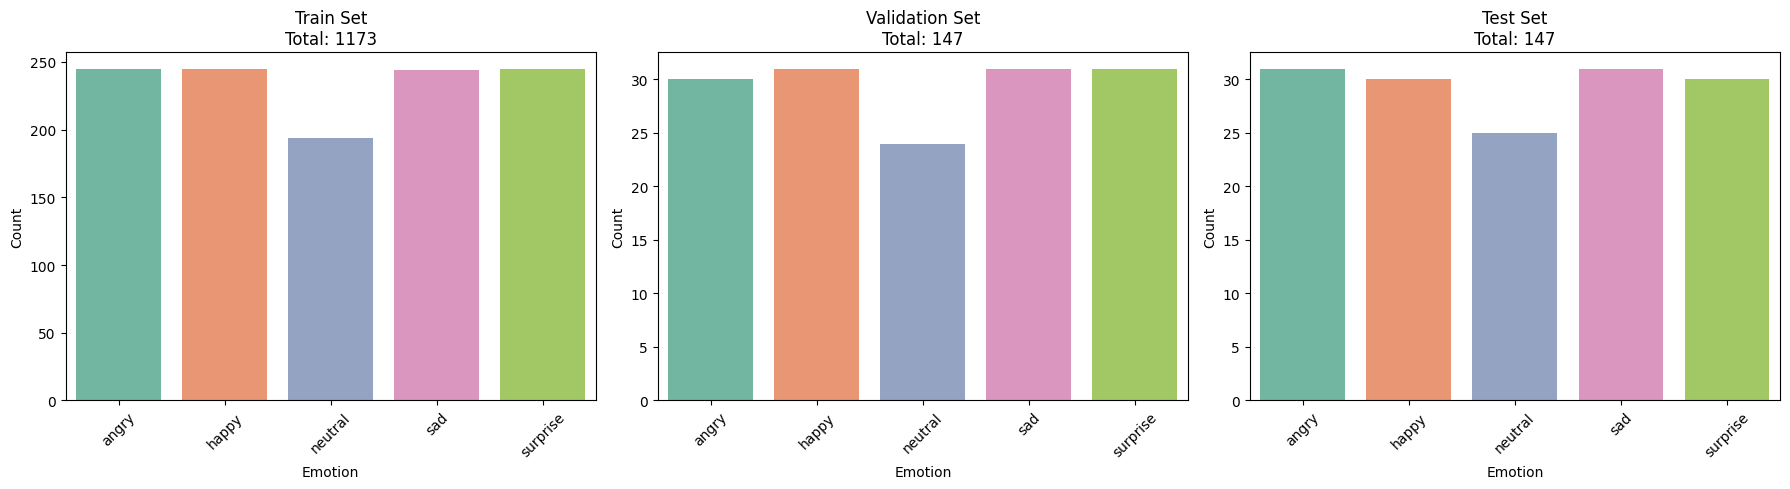

Extracting features for training set...
Extracting features for validation set...
Extracting features for test set...
X_train shape after scaling: (1173, 32)


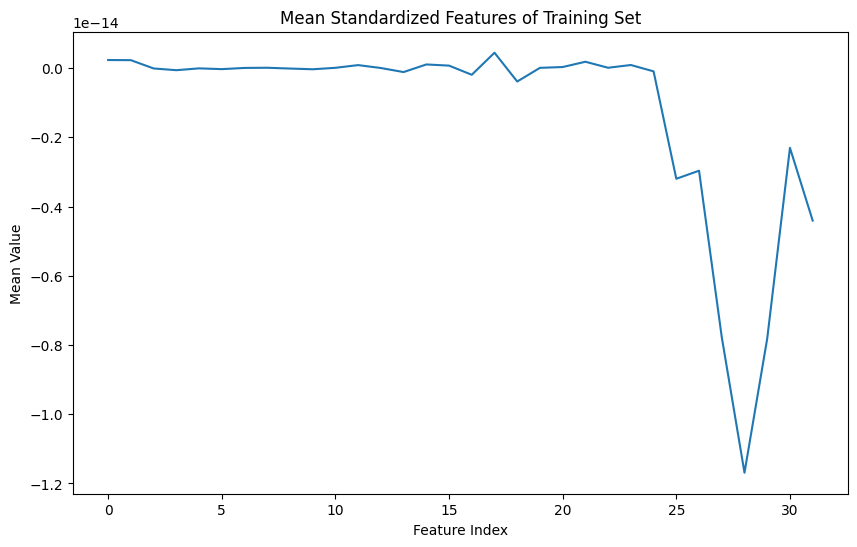

Label mapping:
angry: 0
happy: 1
neutral: 2
sad: 3
surprise: 4
X_train reshaped shape: (1173, 1, 32)
X_val reshaped shape: (147, 1, 32)
X_test reshaped shape: (147, 1, 32)
Starting Random Search Hyperparameter Optimization for BiLSTM...
Running 25 random search iterations...

Random Search Iteration 1/25
Testing parameters: {'activation': 'elu', 'batch_size': 16, 'dense1_units': 46, 'dense2_units': 122, 'dense_dropout': np.float64(0.5678146001636616), 'early_stopping_patience': 9, 'focal_alpha': np.float64(0.24041677639819287), 'focal_gamma': np.float64(1.4679835610086078), 'learning_rate': np.float64(0.0006227525095137952), 'loss_function': 'categorical_crossentropy', 'lr_reduce_factor': np.float64(0.23348344445560876), 'lstm1_units': 135, 'lstm2_units': 39, 'lstm3_units': 10, 'lstm_dropout': np.float64(0.010292247147901223), 'optimizer': 'rmsprop', 'pooling_type': 'avg', 'recurrent_dropout': np.float64(0.10616955533913808), 'reduce_lr_patience': 5, 'use_batch_norm': True, 'use_second

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Val Accuracy: 0.8027, Val Loss: 0.5812
Training time: 40.4 seconds

Random Search Iteration 2/25
Testing parameters: {'activation': 'tanh', 'batch_size': 16, 'dense1_units': 120, 'dense2_units': 64, 'dense_dropout': np.float64(0.41486479615503347), 'early_stopping_patience': 14, 'focal_alpha': np.float64(0.1419990968922539), 'focal_gamma': np.float64(3.9212665565243774), 'learning_rate': np.float64(0.002194942063872738), 'loss_function': 'categorical_crossentropy', 'lr_reduce_factor': np.float64(0.41407038455720546), 'lstm1_units': 82, 'lstm2_units': 123, 'lstm3_units': 62, 'lstm_dropout': np.float64(0.4916154429033941), 'optimizer': 'adam', 'pooling_type': 'both', 'recurrent_dropout': np.float64(0.4299702033681603), 'reduce_lr_patience': 6, 'use_batch_norm': True, 'use_second_dense': True, 'use_second_lstm': False, 'use_third_lstm': False}
Error training model: The layer sequential has never been called and thus has no defined input.
Val Accuracy: 0.0000, Val Loss: inf
Training time: 

In [ ]:
# Split the data into train, validation, and test sets
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['emotion'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['emotion'], random_state=42
)

# Confirm split sizes
print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")

# Visualize the emotion distribution across splits
def plot_distribution(dataframes, labels):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, df_split, label in zip(axes, dataframes, labels):
        sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
        ax.set_title(f"{label} Set\nTotal: {len(df_split)}")
        ax.set_xlabel('Emotion')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# Plot emotion distributions
plot_distribution([train_df, val_df, test_df], ['Train', 'Validation', 'Test'])

# Feature extraction function
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=None)

    # Extract MFCCs
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc = np.mean(mfcc, axis=1)  # Take the mean of each coefficient

    # Extract Chroma feature
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma = np.mean(chroma, axis=1)  # Mean of chroma coefficients

    # Extract Spectral Contrast
    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    spectral_contrast = np.mean(spectral_contrast, axis=1)

    # Combine all features into one vector
    features = np.hstack([mfcc, chroma, spectral_contrast])
    return features

# Extract features for each split
print("Extracting features for training set...")
train_features = [extract_features(file) for file in train_df['file_path']]
print("Extracting features for validation set...")
val_features = [extract_features(file) for file in val_df['file_path']]
print("Extracting features for test set...")
test_features = [extract_features(file) for file in test_df['file_path']]

# Convert to numpy arrays
X_train = np.array(train_features)
X_val = np.array(val_features)
X_test = np.array(test_features)

# Feature standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Check feature shapes
print("X_train shape after scaling:", X_train.shape)

# Visualize feature means
plt.figure(figsize=(10, 6))
plt.plot(np.mean(X_train, axis=0))
plt.title('Mean Standardized Features of Training Set')
plt.xlabel('Feature Index')
plt.ylabel('Mean Value')
plt.show()

# Encode labels
label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(train_df['emotion'])
val_labels = label_encoder.transform(val_df['emotion'])
test_labels = label_encoder.transform(test_df['emotion'])

# Convert to one-hot encoding
y_train = to_categorical(train_labels)
y_val = to_categorical(val_labels)
y_test = to_categorical(test_labels)

# Print class mapping
print("Label mapping:")
for i, emotion in enumerate(label_encoder.classes_):
    print(f"{emotion}: {i}")

# Reshape for BiLSTM model input
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Print reshaped dimensions
print("X_train reshaped shape:", X_train.shape)
print("X_val reshaped shape:", X_val.shape)
print("X_test reshaped shape:", X_test.shape)

# Fixed focal loss function using tf.keras.backend instead of keras.backend
def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        # Clip predictions to avoid log(0) errors
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)

        # Calculate cross-entropy
        cross_entropy = -y_true * tf.math.log(y_pred)

        # Modulating factor: (1 - p_t)^γ
        modulating_factor = tf.pow(1. - y_pred, gamma)

        # Apply α (class weights) if provided as a list/tensor
        if isinstance(alpha, (list, tuple)) or isinstance(alpha, tf.Tensor):
            alpha_tensor = tf.constant(alpha, dtype=tf.float32)
            focal_weight = alpha_tensor * modulating_factor
        else:
            focal_weight = alpha * modulating_factor

        # Final loss: α * (1 - p_t)^γ * Cross-Entropy
        loss = focal_weight * cross_entropy

        # Return average loss across batches
        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))

    return focal_loss_fixed

# ==================== HYPERPARAMETER OPTIMIZATION ====================

import itertools
import json
from datetime import datetime
import pandas as pd
from sklearn.model_selection import ParameterSampler
from scipy.stats import uniform, randint

# Enhanced BiLSTM model builder with hyperparameters
def build_bilstm_model_with_hyperparams(input_shape, num_classes, hyperparams):
    model = models.Sequential()

    # First BiLSTM Layer
    model.add(layers.Bidirectional(
        layers.LSTM(
            hyperparams['lstm1_units'],
            return_sequences=True,
            dropout=hyperparams['lstm_dropout'],
            recurrent_dropout=hyperparams['recurrent_dropout']
        ),
        input_shape=input_shape
    ))

    # Add BatchNormalization if specified
    if hyperparams['use_batch_norm']:
        model.add(layers.BatchNormalization())

    # Second BiLSTM Layer (optional)
    if hyperparams['use_second_lstm']:
        model.add(layers.Bidirectional(
            layers.LSTM(
                hyperparams['lstm2_units'],
                return_sequences=True,
                dropout=hyperparams['lstm_dropout'],
                recurrent_dropout=hyperparams['recurrent_dropout']
            )
        ))
        if hyperparams['use_batch_norm']:
            model.add(layers.BatchNormalization())

    # Third BiLSTM Layer (optional)
    if hyperparams['use_third_lstm']:
        model.add(layers.Bidirectional(
            layers.LSTM(
                hyperparams['lstm3_units'],
                return_sequences=True,
                dropout=hyperparams['lstm_dropout'],
                recurrent_dropout=hyperparams['recurrent_dropout']
            )
        ))
        if hyperparams['use_batch_norm']:
            model.add(layers.BatchNormalization())

    # Pooling layer
    if hyperparams['pooling_type'] == 'max':
        model.add(layers.GlobalMaxPooling1D())
    elif hyperparams['pooling_type'] == 'avg':
        model.add(layers.GlobalAveragePooling1D())
    else:  # both
        max_pool = layers.GlobalMaxPooling1D()(model.layers[-1].output)
        avg_pool = layers.GlobalAveragePooling1D()(model.layers[-1].output)
        concat_pool = layers.Concatenate()([max_pool, avg_pool])
        # Rebuild model with functional API for concatenation
        model = models.Model(inputs=model.input, outputs=concat_pool)
        x = concat_pool

    if hyperparams['pooling_type'] != 'both':
        # First Dense Layer
        model.add(layers.Dense(hyperparams['dense1_units'], activation=hyperparams['activation']))
        model.add(layers.Dropout(hyperparams['dense_dropout']))

        # Second Dense Layer (optional)
        if hyperparams['use_second_dense']:
            model.add(layers.Dense(hyperparams['dense2_units'], activation=hyperparams['activation']))
            model.add(layers.Dropout(hyperparams['dense_dropout']))

        # Output Layer
        model.add(layers.Dense(num_classes, activation='softmax'))
    else:
        # Handle the functional API case
        x = layers.Dense(hyperparams['dense1_units'], activation=hyperparams['activation'])(x)
        x = layers.Dropout(hyperparams['dense_dropout'])(x)

        if hyperparams['use_second_dense']:
            x = layers.Dense(hyperparams['dense2_units'], activation=hyperparams['activation'])(x)
            x = layers.Dropout(hyperparams['dense_dropout'])(x)

        outputs = layers.Dense(num_classes, activation='softmax')(x)
        model = models.Model(inputs=model.input, outputs=outputs)

    return model

# Function to train and evaluate model with given hyperparameters
def train_evaluate_model(hyperparams, X_train, y_train, X_val, y_val, input_shape, num_classes,
                        max_epochs=100, verbose=0):
    """
    Train and evaluate a BiLSTM model with given hyperparameters
    """
    try:
        # Build model
        model = build_bilstm_model_with_hyperparams(input_shape, num_classes, hyperparams)

        # Select loss function
        if hyperparams['loss_function'] == 'focal':
            loss_fn = focal_loss(gamma=hyperparams['focal_gamma'], alpha=hyperparams['focal_alpha'])
        else:
            loss_fn = 'categorical_crossentropy'

        # Compile model
        if hyperparams['optimizer'] == 'adam':
            optimizer = tf.keras.optimizers.Adam(learning_rate=hyperparams['learning_rate'])
        elif hyperparams['optimizer'] == 'rmsprop':
            optimizer = tf.keras.optimizers.RMSprop(learning_rate=hyperparams['learning_rate'])
        else:  # sgd
            optimizer = tf.keras.optimizers.SGD(learning_rate=hyperparams['learning_rate'])

        model.compile(
            optimizer=optimizer,
            loss=loss_fn,
            metrics=['accuracy']
        )

        # Define callbacks
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=hyperparams['early_stopping_patience'],
                restore_best_weights=True,
                verbose=0
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=hyperparams['lr_reduce_factor'],
                patience=hyperparams['reduce_lr_patience'],
                min_lr=0.00001,
                verbose=0
            )
        ]

        # Train model
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=max_epochs,
            batch_size=hyperparams['batch_size'],
            callbacks=callbacks,
            verbose=verbose
        )

        # Get best validation accuracy and loss
        best_val_accuracy = max(history.history['val_accuracy'])
        best_val_loss = min(history.history['val_loss'])

        # Clean up model to free memory
        del model
        tf.keras.backend.clear_session()

        return {
            'val_accuracy': best_val_accuracy,
            'val_loss': best_val_loss,
            'epochs_trained': len(history.history['val_accuracy'])
        }

    except Exception as e:
        print(f"Error training model: {e}")
        return {
            'val_accuracy': 0.0,
            'val_loss': float('inf'),
            'epochs_trained': 0
        }

# ==================== RANDOM SEARCH ====================

print("Starting Random Search Hyperparameter Optimization for BiLSTM...")

# Define hyperparameter search space for random search
random_search_space = {
    'lstm1_units': randint(32, 257),  # 32 to 256
    'lstm2_units': randint(16, 129),  # 16 to 128
    'lstm3_units': randint(8, 65),    # 8 to 64
    'use_second_lstm': [True, False],
    'use_third_lstm': [True, False],
    'lstm_dropout': uniform(0.0, 0.5),  # 0.0 to 0.5
    'recurrent_dropout': uniform(0.0, 0.5),  # 0.0 to 0.5
    'use_batch_norm': [True, False],
    'pooling_type': ['max', 'avg', 'both'],
    'dense1_units': randint(32, 257),  # 32 to 256
    'dense2_units': randint(16, 129),  # 16 to 128
    'use_second_dense': [True, False],
    'dense_dropout': uniform(0.1, 0.6),  # 0.1 to 0.7
    'activation': ['relu', 'tanh', 'elu'],
    'optimizer': ['adam', 'rmsprop', 'sgd'],
    'learning_rate': uniform(0.0001, 0.009),  # 0.0001 to 0.01
    'batch_size': [16, 32, 64],
    'loss_function': ['focal', 'categorical_crossentropy'],
    'focal_gamma': uniform(1.0, 3.0),  # 1.0 to 4.0
    'focal_alpha': uniform(0.1, 0.9),  # 0.1 to 1.0
    'early_stopping_patience': randint(5, 16),  # 5 to 15
    'reduce_lr_patience': randint(2, 8),  # 2 to 7
    'lr_reduce_factor': uniform(0.1, 0.4)  # 0.1 to 0.5
}

# Number of random search iterations
n_random_iter = 25  # Adjust based on computational resources

# Generate random hyperparameter combinations
random_params = list(ParameterSampler(random_search_space, n_iter=n_random_iter, random_state=42))

# Store results
random_search_results = []
input_shape = (X_train.shape[1], X_train.shape[2])
num_classes = y_train.shape[1]

print(f"Running {n_random_iter} random search iterations...")

for i, params in enumerate(random_params):
    print(f"\nRandom Search Iteration {i+1}/{n_random_iter}")
    print(f"Testing parameters: {params}")

    start_time = datetime.now()

    # Train and evaluate model
    results = train_evaluate_model(
        params, X_train, y_train, X_val, y_val,
        input_shape, num_classes,
        max_epochs=25, verbose=0
    )

    end_time = datetime.now()
    training_time = (end_time - start_time).total_seconds()

    # Store results
    result_entry = {
        'iteration': i+1,
        'hyperparams': params.copy(),
        'val_accuracy': results['val_accuracy'],
        'val_loss': results['val_loss'],
        'epochs_trained': results['epochs_trained'],
        'training_time_seconds': training_time
    }

    random_search_results.append(result_entry)

    print(f"Val Accuracy: {results['val_accuracy']:.4f}, Val Loss: {results['val_loss']:.4f}")
    print(f"Training time: {training_time:.1f} seconds")

# Sort results by validation accuracy
random_search_results.sort(key=lambda x: x['val_accuracy'], reverse=True)

# Display top 5 results from random search
print("\n" + "="*50)
print("TOP 5 RANDOM SEARCH RESULTS:")
print("="*50)

for i, result in enumerate(random_search_results[:5]):
    print(f"\nRank {i+1}:")
    print(f"Validation Accuracy: {result['val_accuracy']:.4f}")
    print(f"Validation Loss: {result['val_loss']:.4f}")
    print(f"Epochs Trained: {result['epochs_trained']}")
    print(f"Training Time: {result['training_time_seconds']:.1f}s")
    print("Hyperparameters:")
    for key, value in result['hyperparams'].items():
        print(f"  {key}: {value}")

# ==================== GRID SEARCH BASED ON RANDOM SEARCH RESULTS ====================

print("\n" + "="*50)
print("STARTING GRID SEARCH BASED ON RANDOM SEARCH RESULTS")
print("="*50)

# Analyze top performing hyperparameters from random search
top_n = 3  # Use top 3 for BiLSTM to reduce complexity
top_results = random_search_results[:top_n]

# Extract common patterns from top performers
def analyze_top_hyperparams_bilstm(top_results):
    analysis = {}

    for key in top_results[0]['hyperparams'].keys():
        values = [result['hyperparams'][key] for result in top_results]

        if isinstance(values[0], bool):
            # For boolean values, find the most common
            analysis[key] = max(set(values), key=values.count)
        elif isinstance(values[0], str):
            # For string values, find the most common and add one alternative
            most_common = max(set(values), key=values.count)
            unique_values = list(set(values))
            if len(unique_values) > 1:
                analysis[key] = unique_values[:2]  # Top 2 unique values
            else:
                analysis[key] = [most_common]
        elif isinstance(values[0], int):
            # For integer values, create a focused range
            median_val = int(np.median(values))
            analysis[key] = [median_val, max(int(np.min(values)), median_val - 16),
                           min(int(np.max(values)), median_val + 16)]
            analysis[key] = sorted(list(set(analysis[key])))  # Remove duplicates and sort
        else:  # float values
            # For float values, create a focused range
            median_val = np.median(values)
            analysis[key] = [median_val, np.min(values), np.max(values)]
            analysis[key] = sorted(list(set(analysis[key])))  # Remove duplicates and sort

    return analysis

# Analyze top results
hyperparams_analysis = analyze_top_hyperparams_bilstm(top_results)

print("Analysis of top performing hyperparameters:")
for key, value in hyperparams_analysis.items():
    print(f"{key}: {value}")

# Define focused grid search space based on random search results
grid_search_space = {}
for key, value in hyperparams_analysis.items():
    if isinstance(value, list):
        grid_search_space[key] = value
    else:
        grid_search_space[key] = [value]

# Generate all combinations for grid search
grid_combinations = list(itertools.product(*grid_search_space.values()))
grid_keys = list(grid_search_space.keys())

print(f"\nGrid search will test {len(grid_combinations)} combinations")

# Limit grid search iterations to manageable number
max_grid_iterations = min(15, len(grid_combinations))
if len(grid_combinations) > max_grid_iterations:
    # Sample random combinations if there are too many
    import random
    random.seed(42)
    grid_combinations = random.sample(grid_combinations, max_grid_iterations)

grid_search_results = []

print(f"Running {len(grid_combinations)} grid search iterations...")

for i, combination in enumerate(grid_combinations):
    # Create hyperparameter dictionary
    params = dict(zip(grid_keys, combination))

    print(f"\nGrid Search Iteration {i+1}/{len(grid_combinations)}")
    print(f"Testing parameters: {params}")

    start_time = datetime.now()

    # Train and evaluate model
    results = train_evaluate_model(
        params, X_train, y_train, X_val, y_val,
        input_shape, num_classes,
        max_epochs=40, verbose=0
    )

    end_time = datetime.now()
    training_time = (end_time - start_time).total_seconds()

    # Store results
    result_entry = {
        'iteration': i+1,
        'hyperparams': params.copy(),
        'val_accuracy': results['val_accuracy'],
        'val_loss': results['val_loss'],
        'epochs_trained': results['epochs_trained'],
        'training_time_seconds': training_time
    }

    grid_search_results.append(result_entry)

    print(f"Val Accuracy: {results['val_accuracy']:.4f}, Val Loss: {results['val_loss']:.4f}")
    print(f"Training time: {training_time:.1f} seconds")

# Sort grid search results by validation accuracy
grid_search_results.sort(key=lambda x: x['val_accuracy'], reverse=True)

# Display top 5 results from grid search
print("\n" + "="*50)
print("TOP 5 GRID SEARCH RESULTS:")
print("="*50)

for i, result in enumerate(grid_search_results[:5]):
    print(f"\nRank {i+1}:")
    print(f"Validation Accuracy: {result['val_accuracy']:.4f}")
    print(f"Validation Loss: {result['val_loss']:.4f}")
    print(f"Epochs Trained: {result['epochs_trained']}")
    print(f"Training Time: {result['training_time_seconds']:.1f}s")
    print("Hyperparameters:")
    for key, value in result['hyperparams'].items():
        print(f"  {key}: {value}")

# ==================== FINAL MODEL TRAINING ====================

print("\n" + "="*50)
print("TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS")
print("="*50)

# Get the best hyperparameters
best_hyperparams = grid_search_results[0]['hyperparams']

print("Best hyperparameters:")
for key, value in best_hyperparams.items():
    print(f"  {key}: {value}")

# Build and train final model
final_model = build_bilstm_model_with_hyperparams(input_shape, num_classes, best_hyperparams)

# Select loss function for final model
if best_hyperparams['loss_function'] == 'focal':
    loss_fn = focal_loss(gamma=best_hyperparams['focal_gamma'], alpha=best_hyperparams['focal_alpha'])
else:
    loss_fn = 'categorical_crossentropy'

# Select optimizer for final model
if best_hyperparams['optimizer'] == 'adam':
    optimizer = tf.keras.optimizers.Adam(learning_rate=best_hyperparams['learning_rate'])
elif best_hyperparams['optimizer'] == 'rmsprop':
    optimizer = tf.keras.optimizers.RMSprop(learning_rate=best_hyperparams['learning_rate'])
else:  # sgd
    optimizer = tf.keras.optimizers.SGD(learning_rate=best_hyperparams['learning_rate'])

# Compile final model
final_model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=['accuracy']
)

# Model summary
print("\nFinal model architecture:")
final_model.summary()

# Define callbacks for final training
final_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=best_hyperparams['early_stopping_patience'],
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_optimized_bilstm_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=best_hyperparams['lr_reduce_factor'],
        patience=best_hyperparams['reduce_lr_patience'],
        min_lr=0.00001,
        verbose=1
    )
]

# Train final model
print("\nTraining final optimized BiLSTM model...")
history = final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=best_hyperparams['batch_size'],
    callbacks=final_callbacks,
    verbose=1
)

# Plot training history
plt.figure(figsize=(15, 5))

# Plot accuracy
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Final BiLSTM Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Final BiLSTM Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot learning rate
if 'lr' in history.history:
    plt.subplot(1, 3, 3)
    plt.plot(history.history['lr'])
    plt.title('Learning Rate')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.yscale('log')

plt.tight_layout()
plt.show()

# Evaluate on test set
test_loss, test_accuracy = final_model.evaluate(X_test, y_test, verbose=1)
print(f"\nFinal BiLSTM Model Test Results:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Get predictions on test set
y_pred_probs = final_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate classification report
print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))

# Create and plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Optimized BiLSTM Model - Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Save results to files
print("\nSaving optimization results...")

# Save random search results
random_search_df = pd.DataFrame([
    {**result['hyperparams'],
     'val_accuracy': result['val_accuracy'],
     'val_loss': result['val_loss'],
     'epochs_trained': result['epochs_trained'],
     'training_time_seconds': result['training_time_seconds']}
    for result in random_search_results
])
random_search_df.to_csv('bilstm_random_search_results.csv', index=False)

# Save grid search results
grid_search_df = pd.DataFrame([
    {**result['hyperparams'],
     'val_accuracy': result['val_accuracy'],
     'val_loss': result['val_loss'],
     'epochs_trained': result['epochs_trained'],
     'training_time_seconds': result['training_time_seconds']}
    for result in grid_search_results
])
grid_search_df.to_csv('bilstm_grid_search_results.csv', index=False)

# Save best hyperparameters
with open('best_bilstm_hyperparameters.json', 'w') as f:
    # Convert numpy types to native Python types for JSON serialization
    serializable_params = {}
    for key, value in best_hyperparams.items():
        if isinstance(value, np.floating):
            serializable_params[key] = float(value)
        elif isinstance(value, np.integer):
            serializable_params[key] = int(value)
        else:
            serializable_params[key] = value
    json.dump(serializable_params, f, indent=2)

# Save the final optimized model
final_model.save('bangla_ser_optimized_bilstm_model.h5')
print("Optimized BiLSTM model saved as 'bangla_ser_optimized_bilstm_model.h5'")

# Comparison with baseline results
print("\n" + "="*50)
print("BILSTM OPTIMIZATION SUMMARY")
print("="*50)
print(f"Random Search - Best Validation Accuracy: {random_search_results[0]['val_accuracy']:.4f}")
print(f"Grid Search - Best Validation Accuracy: {grid_search_results[0]['val_accuracy']:.4f}")
print(f"Final Optimized BiLSTM Model - Test Accuracy: {test_accuracy:.4f}")

# Enhanced prediction function for optimized model
def predict_emotion_optimized_bilstm(audio_path, model, scaler, label_encoder):
    # Extract features from audio
    features = extract_features(audio_path)

    # Scale features using the same scaler used for training
    features = scaler.transform(features.reshape(1, -1))

    # Reshape for BiLSTM model input
    features = features.reshape(1, 1, -1)

    # Predict using the model
    prediction = model.predict(features)[0]

    # Get predicted class index

### shorter version memory efficient

Train: 1173, Validation: 147, Test: 147


/tmp/ipython-input-6373079.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
/tmp/ipython-input-6373079.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
/tmp/ipython-input-6373079.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')


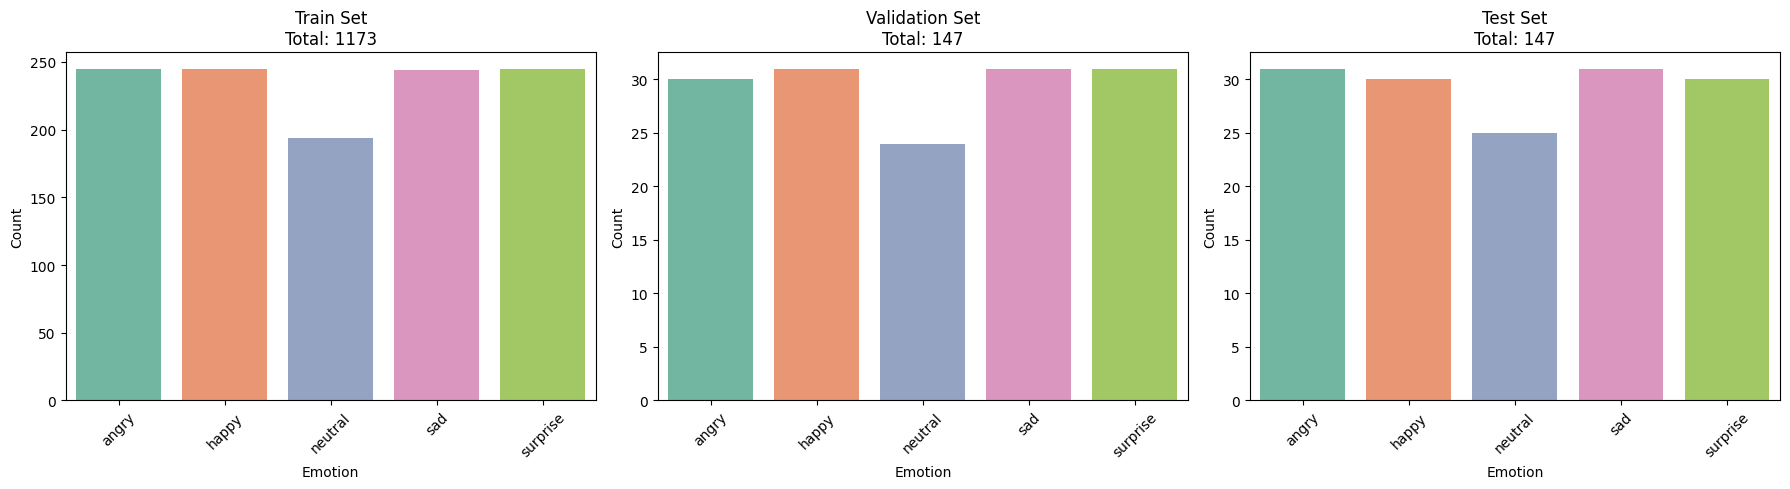

Extracting features for training set...
Extracting features for validation set...
Extracting features for test set...
X_train shape after scaling: (1173, 32)


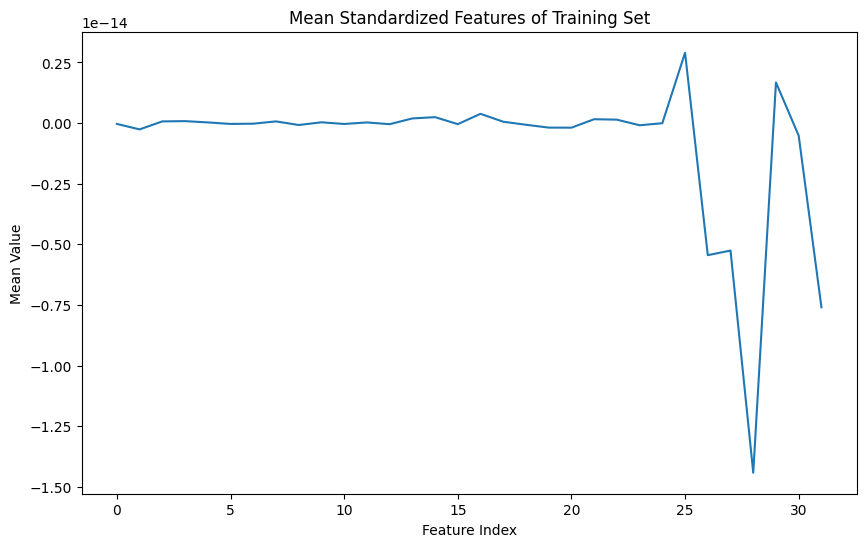

Label mapping:
angry: 0
happy: 1
neutral: 2
sad: 3
surprise: 4
X_train reshaped shape: (1173, 1, 32)
X_val reshaped shape: (147, 1, 32)
X_test reshaped shape: (147, 1, 32)
Starting Memory-Optimized Random Search for Colab...
Testing 8 optimized configurations for Colab...

Configuration 1/8
LSTM Units: 64, Dense Units: 64
Two LSTM: False, Dropout: 0.3


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Val Accuracy: 0.7619, Val Loss: 0.6374
Training time: 21.8 seconds

Configuration 2/8
LSTM Units: 128, Dense Units: 128
Two LSTM: True, Dropout: 0.4
Val Accuracy: 0.6871, Val Loss: 0.7918
Training time: 30.4 seconds

Configuration 3/8
LSTM Units: 96, Dense Units: 96
Two LSTM: False, Dropout: 0.5
Val Accuracy: 0.5986, Val Loss: 0.9067
Training time: 22.5 seconds

Configuration 4/8
LSTM Units: 128, Dense Units: 64
Two LSTM: True, Dropout: 0.3
Val Accuracy: 0.5170, Val Loss: 1.3506
Training time: 34.4 seconds

Configuration 5/8
LSTM Units: 64, Dense Units: 128
Two LSTM: False, Dropout: 0.4
Val Accuracy: 0.6327, Val Loss: 0.8472
Training time: 17.3 seconds

Configuration 6/8
LSTM Units: 96, Dense Units: 96
Two LSTM: True, Dropout: 0.35
Val Accuracy: 0.7483, Val Loss: 0.6580
Training time: 40.6 seconds

Configuration 7/8
LSTM Units: 32, Dense Units: 32
Two LSTM: False, Dropout: 0.2
Val Accuracy: 0.8231, Val Loss: 0.5545
Training time: 26.4 seconds

Configuration 8/8
LSTM Units: 160, Dense U

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 64)             │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,885 (73.77 KB)

 Trainable params: 18,885 (73.77 KB)

 Non-trainable params: 0 (0.00 B)


Training final optimized BiLSTM model...
Epoch 1/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.2658 - loss: 1.5823 - val_accuracy: 0.4354 - val_loss: 1.4208 - learning_rate: 0.0010
Epoch 2/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4424 - loss: 1.3739 - val_accuracy: 0.5374 - val_loss: 1.2318 - learning_rate: 0.0010
Epoch 3/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4917 - loss: 1.2545 - val_accuracy: 0.5782 - val_loss: 1.0734 - learning_rate: 0.0010
Epoch 4/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5483 - loss: 1.0892 - val_accuracy: 0.6122 - val_loss: 0.9403 - learning_rate: 0.0010
Epoch 5/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6081 - loss: 1.0072 - val_accuracy: 0.6667 - val_loss: 0.8704 - learning_rate: 0.0010
Epoch 6/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6347 - loss: 0.9121 - val_accuracy: 0.6735 - val_loss: 0.8066 - learning_rate: 0.0010
Epoch 7/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - acc

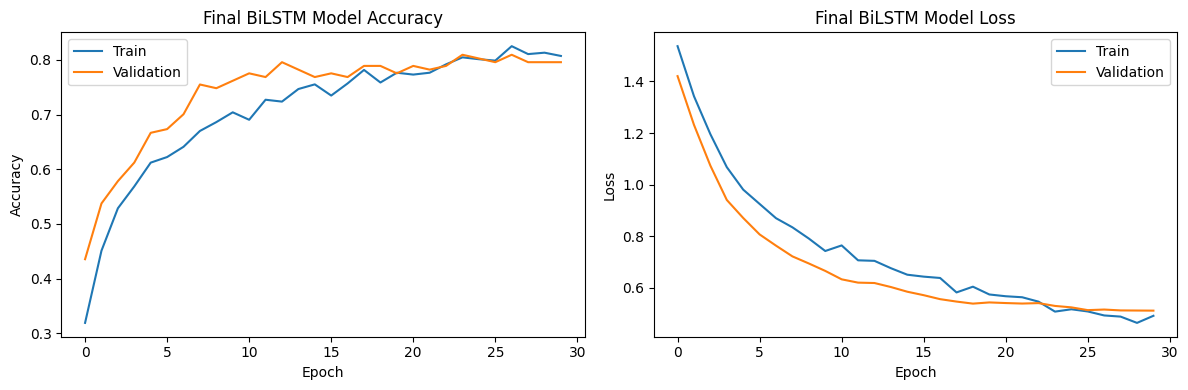

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8121 - loss: 0.4608

Final BiLSTM Model Test Results:
Test Loss: 0.4530
Test Accuracy: 0.8231
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 235ms/step

Classification Report:
              precision    recall  f1-score   support

       angry       1.00      0.90      0.95        31
       happy       0.72      0.70      0.71        30
     neutral       1.00      1.00      1.00        25
         sad       0.72      0.84      0.78        31
    surprise       0.72      0.70      0.71        30

    accuracy                           0.82       147
   macro avg       0.83      0.83      0.83       147
weighted avg       0.83      0.82      0.82       147



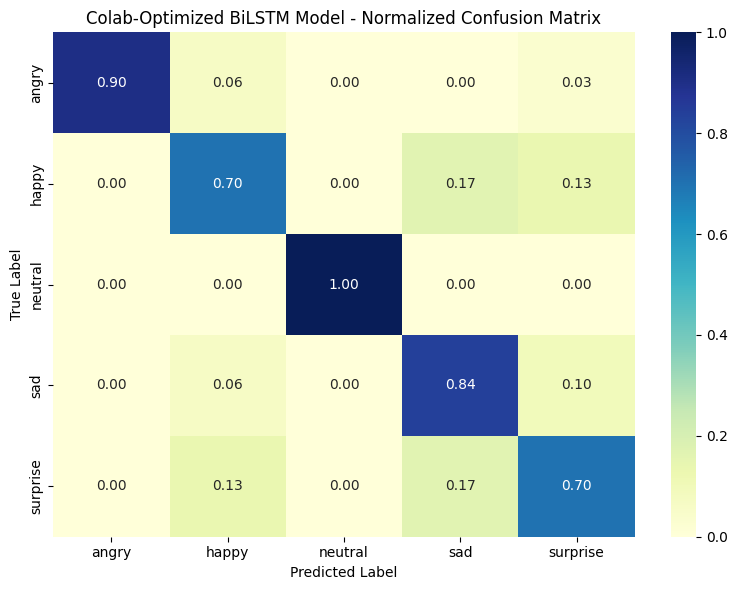

Colab-optimized BiLSTM model saved!

COLAB BILSTM OPTIMIZATION SUMMARY
Best Validation Accuracy: 0.8231
Final Test Accuracy: 0.8231
Total configurations tested: 8
Average training time per config: 27.8s
Memory cleanup completed!
Prediction function ready!
Use predict_emotion_colab_bilstm() to make predictions with the optimized model.


In [ ]:
# Split the data into train, validation, and test sets
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['emotion'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['emotion'], random_state=42
)

# Confirm split sizes
print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")

# Visualize the emotion distribution across splits
def plot_distribution(dataframes, labels):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, df_split, label in zip(axes, dataframes, labels):
        sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
        ax.set_title(f"{label} Set\nTotal: {len(df_split)}")
        ax.set_xlabel('Emotion')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# Plot emotion distributions
plot_distribution([train_df, val_df, test_df], ['Train', 'Validation', 'Test'])

# Feature extraction function
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=None)

    # Extract MFCCs
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc = np.mean(mfcc, axis=1)  # Take the mean of each coefficient

    # Extract Chroma feature
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma = np.mean(chroma, axis=1)  # Mean of chroma coefficients

    # Extract Spectral Contrast
    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    spectral_contrast = np.mean(spectral_contrast, axis=1)

    # Combine all features into one vector
    features = np.hstack([mfcc, chroma, spectral_contrast])
    return features

# Extract features for each split
print("Extracting features for training set...")
train_features = [extract_features(file) for file in train_df['file_path']]
print("Extracting features for validation set...")
val_features = [extract_features(file) for file in val_df['file_path']]
print("Extracting features for test set...")
test_features = [extract_features(file) for file in test_df['file_path']]

# Convert to numpy arrays
X_train = np.array(train_features)
X_val = np.array(val_features)
X_test = np.array(test_features)

# Feature standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Check feature shapes
print("X_train shape after scaling:", X_train.shape)

# Visualize feature means
plt.figure(figsize=(10, 6))
plt.plot(np.mean(X_train, axis=0))
plt.title('Mean Standardized Features of Training Set')
plt.xlabel('Feature Index')
plt.ylabel('Mean Value')
plt.show()

# Encode labels
label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(train_df['emotion'])
val_labels = label_encoder.transform(val_df['emotion'])
test_labels = label_encoder.transform(test_df['emotion'])

# Convert to one-hot encoding
y_train = to_categorical(train_labels)
y_val = to_categorical(val_labels)
y_test = to_categorical(test_labels)

# Print class mapping
print("Label mapping:")
for i, emotion in enumerate(label_encoder.classes_):
    print(f"{emotion}: {i}")

# Reshape for BiLSTM model input
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Print reshaped dimensions
print("X_train reshaped shape:", X_train.shape)
print("X_val reshaped shape:", X_val.shape)
print("X_test reshaped shape:", X_test.shape)

# Fixed focal loss function using tf.keras.backend instead of keras.backend
def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        # Clip predictions to avoid log(0) errors
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)

        # Calculate cross-entropy
        cross_entropy = -y_true * tf.math.log(y_pred)

        # Modulating factor: (1 - p_t)^γ
        modulating_factor = tf.pow(1. - y_pred, gamma)

        # Apply α (class weights) if provided as a list/tensor
        if isinstance(alpha, (list, tuple)) or isinstance(alpha, tf.Tensor):
            alpha_tensor = tf.constant(alpha, dtype=tf.float32)
            focal_weight = alpha_tensor * modulating_factor
        else:
            focal_weight = alpha * modulating_factor

        # Final loss: α * (1 - p_t)^γ * Cross-Entropy
        loss = focal_weight * cross_entropy

        # Return average loss across batches
        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))

    return focal_loss_fixed

# ==================== MEMORY-OPTIMIZED HYPERPARAMETER OPTIMIZATION ====================

import itertools
import json
from datetime import datetime
import pandas as pd
import gc  # For garbage collection

# Simplified BiLSTM model builder for Colab
def build_bilstm_model_colab(input_shape, num_classes, hyperparams):
    """Simplified model builder optimized for Colab memory constraints"""

    model = models.Sequential()

    # First BiLSTM Layer (reduced complexity)
    model.add(layers.Bidirectional(
        layers.LSTM(
            hyperparams['lstm_units'],
            return_sequences=hyperparams['return_sequences'],
            dropout=hyperparams['dropout'],
            recurrent_dropout=hyperparams['recurrent_dropout']
        ),
        input_shape=input_shape
    ))

    # Optional second LSTM layer
    if hyperparams['use_second_lstm']:
        model.add(layers.Bidirectional(
            layers.LSTM(
                hyperparams['lstm_units'] // 2,  # Half the size for second layer
                return_sequences=False,
                dropout=hyperparams['dropout'],
                recurrent_dropout=hyperparams['recurrent_dropout']
            )
        ))

    # If we didn't use a second LSTM and return_sequences is True, add pooling
    if not hyperparams['use_second_lstm'] and hyperparams['return_sequences']:
        model.add(layers.GlobalMaxPooling1D())

    # Dense layers
    model.add(layers.Dense(hyperparams['dense_units'], activation='relu'))
    model.add(layers.Dropout(hyperparams['dropout']))

    # Output layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# Memory-efficient training function
def train_evaluate_model_colab(hyperparams, X_train, y_train, X_val, y_val,
                               input_shape, num_classes, max_epochs=100):
    """Memory-efficient training function for Colab"""

    try:
        # Clear any existing models from memory
        tf.keras.backend.clear_session()
        gc.collect()

        # Build model
        model = build_bilstm_model_colab(input_shape, num_classes, hyperparams)

        # Compile model with simpler optimizer
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=hyperparams['learning_rate']),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        # Simplified callbacks
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_accuracy',
                patience=3,
                restore_best_weights=True,
                verbose=0
            )
        ]

        # Train model with smaller batch size and fewer epochs
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=max_epochs,
            batch_size=hyperparams['batch_size'],
            callbacks=callbacks,
            verbose=0
        )

        # Get best validation accuracy
        best_val_accuracy = max(history.history['val_accuracy'])
        best_val_loss = min(history.history['val_loss'])

        # Clean up immediately
        del model
        tf.keras.backend.clear_session()
        gc.collect()

        return {
            'val_accuracy': best_val_accuracy,
            'val_loss': best_val_loss,
            'epochs_trained': len(history.history['val_accuracy'])
        }

    except Exception as e:
        print(f"Error training model: {e}")
        # Force cleanup on error
        tf.keras.backend.clear_session()
        gc.collect()
        return {
            'val_accuracy': 0.0,
            'val_loss': float('inf'),
            'epochs_trained': 0
        }

# ==================== REDUCED RANDOM SEARCH FOR COLAB ====================

print("Starting Memory-Optimized Random Search for Colab...")

# Simplified hyperparameter search space
colab_search_space = [
    # Configuration 1: Small model
    {
        'lstm_units': 64,
        'use_second_lstm': False,
        'return_sequences': False,
        'dense_units': 64,
        'dropout': 0.3,
        'recurrent_dropout': 0.2,
        'learning_rate': 0.001,
        'batch_size': 32
    },
    # Configuration 2: Medium model with two LSTM layers
    {
        'lstm_units': 128,
        'use_second_lstm': True,
        'return_sequences': True,
        'dense_units': 128,
        'dropout': 0.4,
        'recurrent_dropout': 0.3,
        'learning_rate': 0.001,
        'batch_size': 32
    },
    # Configuration 3: Higher dropout
    {
        'lstm_units': 96,
        'use_second_lstm': False,
        'return_sequences': False,
        'dense_units': 96,
        'dropout': 0.5,
        'recurrent_dropout': 0.3,
        'learning_rate': 0.0005,
        'batch_size': 16
    },
    # Configuration 4: Lower learning rate
    {
        'lstm_units': 128,
        'use_second_lstm': True,
        'return_sequences': True,
        'dense_units': 64,
        'dropout': 0.3,
        'recurrent_dropout': 0.2,
        'learning_rate': 0.0001,
        'batch_size': 32
    },
    # Configuration 5: Larger batch size
    {
        'lstm_units': 64,
        'use_second_lstm': False,
        'return_sequences': False,
        'dense_units': 128,
        'dropout': 0.4,
        'recurrent_dropout': 0.3,
        'learning_rate': 0.001,
        'batch_size': 64
    },
    # Configuration 6: Balanced approach
    {
        'lstm_units': 96,
        'use_second_lstm': True,
        'return_sequences': True,
        'dense_units': 96,
        'dropout': 0.35,
        'recurrent_dropout': 0.25,
        'learning_rate': 0.0008,
        'batch_size': 32
    },
    # Configuration 7: Minimal model
    {
        'lstm_units': 32,
        'use_second_lstm': False,
        'return_sequences': False,
        'dense_units': 32,
        'dropout': 0.2,
        'recurrent_dropout': 0.1,
        'learning_rate': 0.001,
        'batch_size': 16
    },
    # Configuration 8: High capacity with regularization
    {
        'lstm_units': 160,
        'use_second_lstm': False,
        'return_sequences': False,
        'dense_units': 160,
        'dropout': 0.6,
        'recurrent_dropout': 0.4,
        'learning_rate': 0.0005,
        'batch_size': 16
    }
]

# Store results
colab_search_results = []
input_shape = (X_train.shape[1], X_train.shape[2])
num_classes = y_train.shape[1]

n_configs = len(colab_search_space)
print(f"Testing {n_configs} optimized configurations for Colab...")

for i, params in enumerate(colab_search_space):
    print(f"\nConfiguration {i+1}/{n_configs}")
    print(f"LSTM Units: {params['lstm_units']}, Dense Units: {params['dense_units']}")
    print(f"Two LSTM: {params['use_second_lstm']}, Dropout: {params['dropout']}")

    start_time = datetime.now()

    # Train and evaluate model
    results = train_evaluate_model_colab(
        params, X_train, y_train, X_val, y_val,
        input_shape, num_classes,
        max_epochs=15  # Reduced epochs for faster training
    )

    end_time = datetime.now()
    training_time = (end_time - start_time).total_seconds()

    # Store results
    result_entry = {
        'config': i+1,
        'hyperparams': params.copy(),
        'val_accuracy': results['val_accuracy'],
        'val_loss': results['val_loss'],
        'epochs_trained': results['epochs_trained'],
        'training_time_seconds': training_time
    }

    colab_search_results.append(result_entry)

    print(f"Val Accuracy: {results['val_accuracy']:.4f}, Val Loss: {results['val_loss']:.4f}")
    print(f"Training time: {training_time:.1f} seconds")

    # Force garbage collection after each iteration
    gc.collect()

# Sort results by validation accuracy
colab_search_results.sort(key=lambda x: x['val_accuracy'], reverse=True)

# Display top 3 results
print("\n" + "="*50)
print("TOP 3 COLAB-OPTIMIZED RESULTS:")
print("="*50)

for i, result in enumerate(colab_search_results[:3]):
    print(f"\nRank {i+1}:")
    print(f"Validation Accuracy: {result['val_accuracy']:.4f}")
    print(f"Validation Loss: {result['val_loss']:.4f}")
    print(f"Epochs Trained: {result['epochs_trained']}")
    print(f"Training Time: {result['training_time_seconds']:.1f}s")
    print("Hyperparameters:")
    for key, value in result['hyperparams'].items():
        print(f"  {key}: {value}")

# ==================== FINAL MODEL TRAINING ====================

print("\n" + "="*50)
print("TRAINING FINAL MODEL WITH BEST CONFIGURATION")
print("="*50)

# Get the best hyperparameters
best_hyperparams = colab_search_results[0]['hyperparams']

print("Best configuration:")
for key, value in best_hyperparams.items():
    print(f"  {key}: {value}")

# Clear memory before final training
tf.keras.backend.clear_session()
gc.collect()

# Build final model
final_model = build_bilstm_model_colab(input_shape, num_classes, best_hyperparams)

# Compile final model
final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_hyperparams['learning_rate']),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
print("\nFinal model architecture:")
final_model.summary()

# Define callbacks for final training
final_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=0.00001,
        verbose=1
    )
]

# Train final model with more epochs
print("\nTraining final optimized BiLSTM model...")
history = final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,  # More epochs for final training
    batch_size=best_hyperparams['batch_size'],
    callbacks=final_callbacks,
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Final BiLSTM Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Final BiLSTM Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate on test set
test_loss, test_accuracy = final_model.evaluate(X_test, y_test, verbose=1)
print(f"\nFinal BiLSTM Model Test Results:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Get predictions on test set
y_pred_probs = final_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate classification report
print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))

# Create and plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Colab-Optimized BiLSTM Model - Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Save the final optimized model
final_model.save('bangla_ser_colab_optimized_bilstm_model.h5')
print("Colab-optimized BiLSTM model saved!")

# Save results summary
results_summary = {
    'best_config': best_hyperparams,
    'test_accuracy': float(test_accuracy),
    'test_loss': float(test_loss),
    'all_results': [{
        'config': result['config'],
        'val_accuracy': result['val_accuracy'],
        'val_loss': result['val_loss'],
        'training_time': result['training_time_seconds']
    } for result in colab_search_results]
}

with open('colab_bilstm_optimization_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print("\n" + "="*50)
print("COLAB BILSTM OPTIMIZATION SUMMARY")
print("="*50)
print(f"Best Validation Accuracy: {colab_search_results[0]['val_accuracy']:.4f}")
print(f"Final Test Accuracy: {test_accuracy:.4f}")
print(f"Total configurations tested: {n_configs}")
print(f"Average training time per config: {np.mean([r['training_time_seconds'] for r in colab_search_results]):.1f}s")

# Memory cleanup
del final_model
tf.keras.backend.clear_session()
gc.collect()
print("Memory cleanup completed!")

# Enhanced prediction function for optimized model
def predict_emotion_colab_bilstm(audio_path, model_path, scaler, label_encoder):
    """
    Predict emotion from audio file using the Colab-optimized BiLSTM model
    """
    # Load the saved model
    model = tf.keras.models.load_model(model_path)

    # Extract features from audio
    features = extract_features(audio_path)

    # Scale features using the same scaler used for training
    features = scaler.transform(features.reshape(1, -1))

    # Reshape for BiLSTM model input
    features = features.reshape(1, 1, -1)

    # Predict using the model
    prediction = model.predict(features)[0]

    # Get predicted class and confidence
    predicted_class_idx = np.argmax(prediction)
    predicted_emotion = label_encoder.classes_[predicted_class_idx]
    confidence = prediction[predicted_class_idx]

    # Get top 3 predictions
    top_3_idx = np.argsort(prediction)[-3:][::-1]
    top_3_predictions = [
        (label_encoder.classes_[idx], prediction[idx])
        for idx in top_3_idx
    ]

    return {
        'predicted_emotion': predicted_emotion,
        'confidence': float(confidence),
        'top_3_predictions': top_3_predictions
    }

print("Prediction function ready!")
print("Use predict_emotion_colab_bilstm() to make predictions with the optimized model.")

### modified

Train: 1173, Validation: 147, Test: 147


/tmp/ipython-input-2127611263.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
/tmp/ipython-input-2127611263.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
/tmp/ipython-input-2127611263.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')


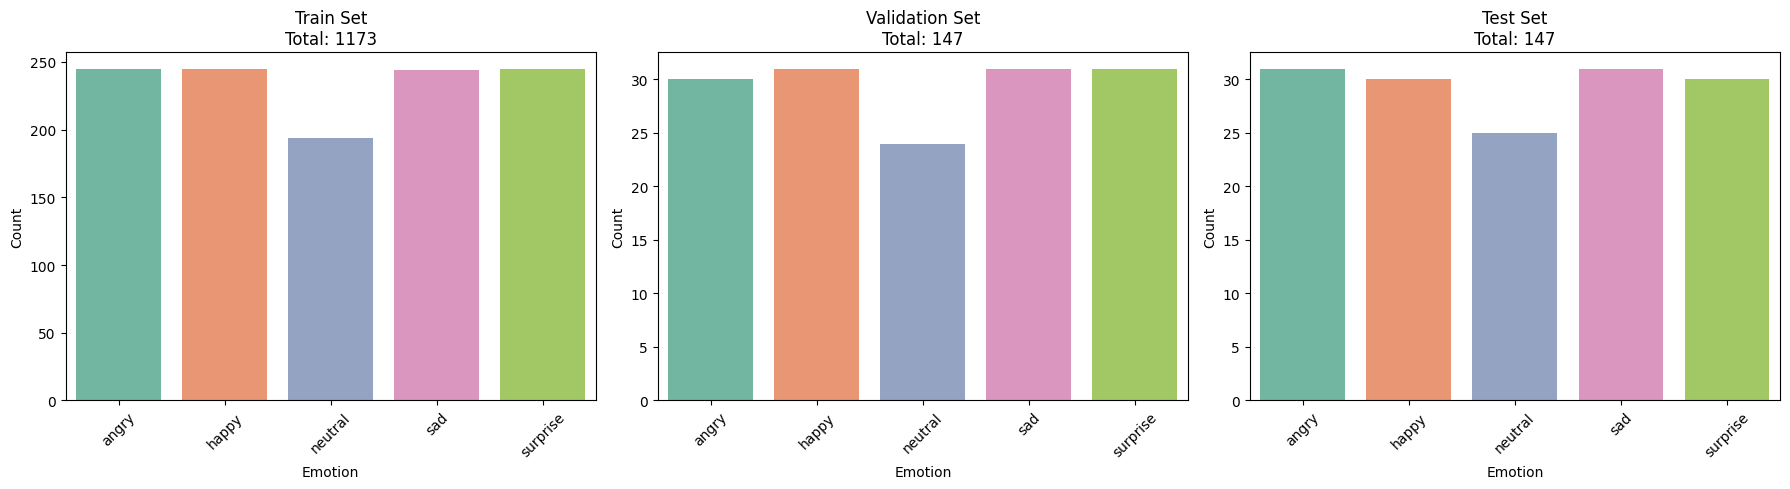

Extracting features for training set...
Extracting features for validation set...
Extracting features for test set...
X_train shape after scaling: (1173, 32)


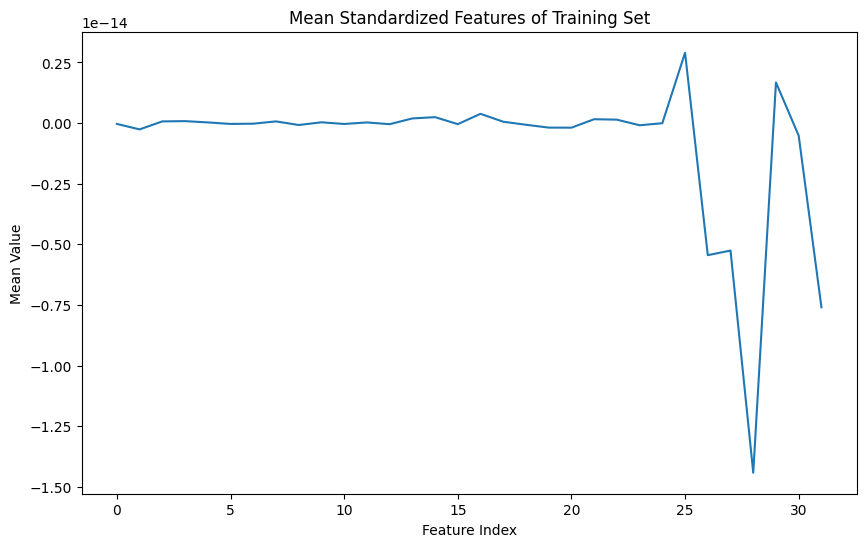

Label mapping:
angry: 0
happy: 1
neutral: 2
sad: 3
surprise: 4
X_train reshaped shape: (1173, 1, 32)
X_val reshaped shape: (147, 1, 32)
X_test reshaped shape: (147, 1, 32)
Starting Memory-Optimized Random Search for Colab...
Testing 8 optimized configurations for Colab...

Configuration 1/8
LSTM Units: 64, Dense Units: 64
Two LSTM: False, Dropout: 0.3


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Val Accuracy: 0.7891, Val Loss: 0.5807
Training time: 23.1 seconds

Configuration 2/8
LSTM Units: 128, Dense Units: 128
Two LSTM: True, Dropout: 0.4
Val Accuracy: 0.7619, Val Loss: 0.6178
Training time: 36.6 seconds

Configuration 3/8
LSTM Units: 96, Dense Units: 96
Two LSTM: False, Dropout: 0.5
Val Accuracy: 0.6259, Val Loss: 0.8837
Training time: 20.9 seconds

Configuration 4/8
LSTM Units: 128, Dense Units: 64
Two LSTM: True, Dropout: 0.3
Val Accuracy: 0.5034, Val Loss: 1.4344
Training time: 33.0 seconds

Configuration 5/8
LSTM Units: 64, Dense Units: 128
Two LSTM: False, Dropout: 0.4
Val Accuracy: 0.7687, Val Loss: 0.6630
Training time: 21.1 seconds

Configuration 6/8
LSTM Units: 96, Dense Units: 96
Two LSTM: True, Dropout: 0.35
Val Accuracy: 0.7483, Val Loss: 0.6749
Training time: 36.5 seconds

Configuration 7/8
LSTM Units: 32, Dense Units: 32
Two LSTM: False, Dropout: 0.2
Val Accuracy: 0.7823, Val Loss: 0.5837
Training time: 26.6 seconds

Configuration 8/8
LSTM Units: 160, Dense U

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │        49,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,245 (227.52 KB)

 Trainable params: 58,245 (227.52 KB)

 Non-trainable params: 0 (0.00 B)


Training final optimized BiLSTM model...
Epoch 1/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.2496 - loss: 1.5872 - val_accuracy: 0.4898 - val_loss: 1.4196 - learning_rate: 0.0010
Epoch 2/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4886 - loss: 1.3716 - val_accuracy: 0.5238 - val_loss: 1.1950 - learning_rate: 0.0010
Epoch 3/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5186 - loss: 1.2054 - val_accuracy: 0.5782 - val_loss: 1.0367 - learning_rate: 0.0010
Epoch 4/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5885 - loss: 1.0677 - val_accuracy: 0.6259 - val_loss: 0.9425 - learning_rate: 0.0010
Epoch 5/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5999 - loss: 0.9719 - val_accuracy: 0.6054 - val_loss: 0.8809 - learning_rate: 0.0010
Epoch 6/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5620 - loss: 0.9801 - val_accuracy: 0.6463 - val_loss: 0.8368 - learning_rate: 0.0010
Epoch 7/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - ac

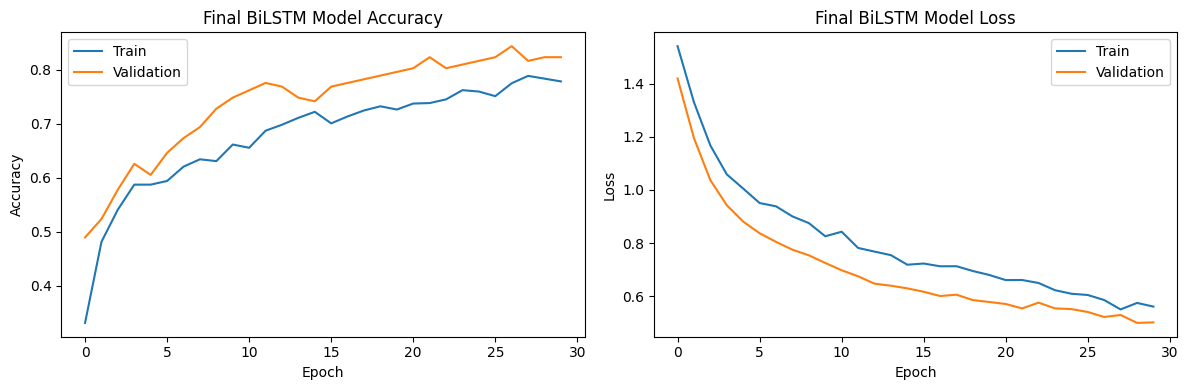

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7768 - loss: 0.5286 

Final BiLSTM Model Test Results:
Test Loss: 0.5329
Test Accuracy: 0.7823
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 221ms/step

Classification Report:
              precision    recall  f1-score   support

       angry       0.96      0.81      0.88        31
       happy       0.70      0.70      0.70        30
     neutral       1.00      1.00      1.00        25
         sad       0.77      0.74      0.75        31
    surprise       0.58      0.70      0.64        30

    accuracy                           0.78       147
   macro avg       0.80      0.79      0.79       147
weighted avg       0.80      0.78      0.79       147



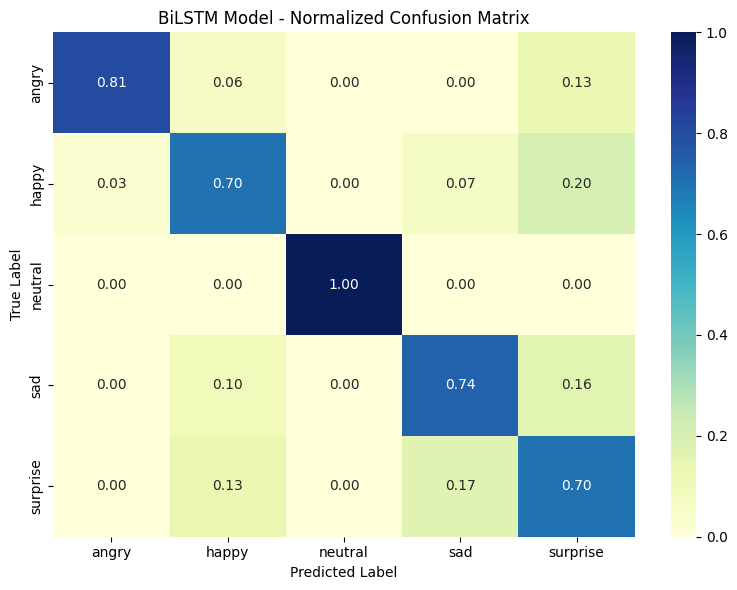

 BiLSTM model saved!

HYPERPARAMETER ANALYSIS & VISUALIZATION
Results Summary Table:
--------------------------------------------------------------------------------
Rank Config Val Acc  Val Loss LSTM   Dense  2nd LSTM Dropout
--------------------------------------------------------------------------------
1    1      0.7891   0.5807   64     64     False    0.30
2    7      0.7823   0.5837   32     32     False    0.20
3    5      0.7687   0.6630   64     128    False    0.40
4    2      0.7619   0.6178   128    128    True     0.40
5    6      0.7483   0.6749   96     96     True     0.35
6    3      0.6259   0.8837   96     96     False    0.50
7    8      0.6190   0.9333   160    160    False    0.60
8    4      0.5034   1.4344   128    64     True     0.30


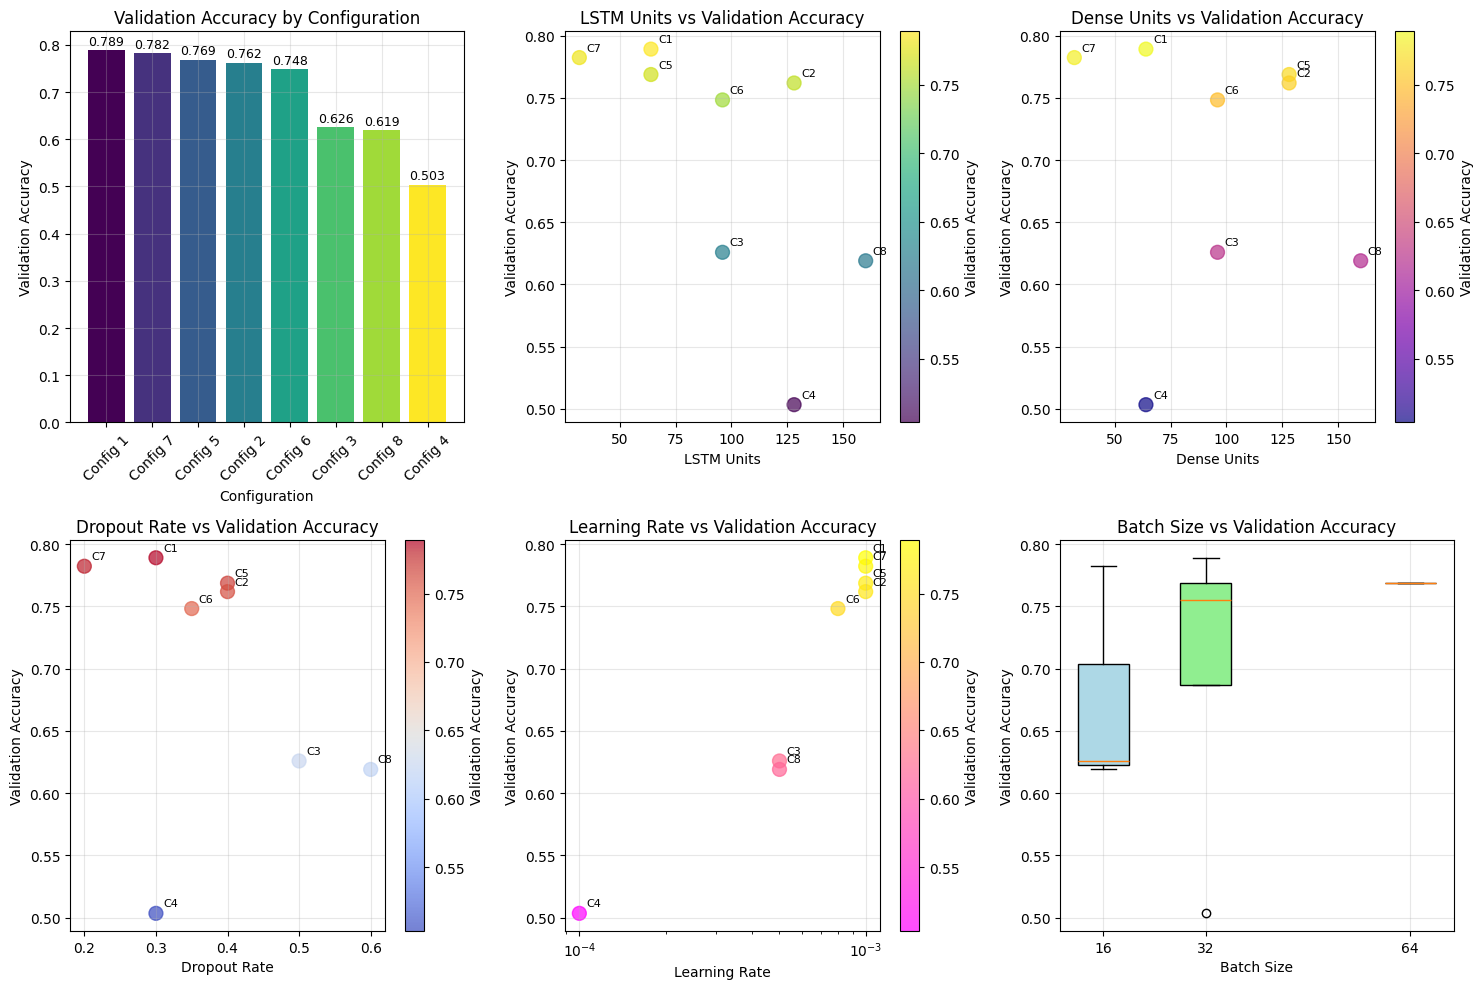

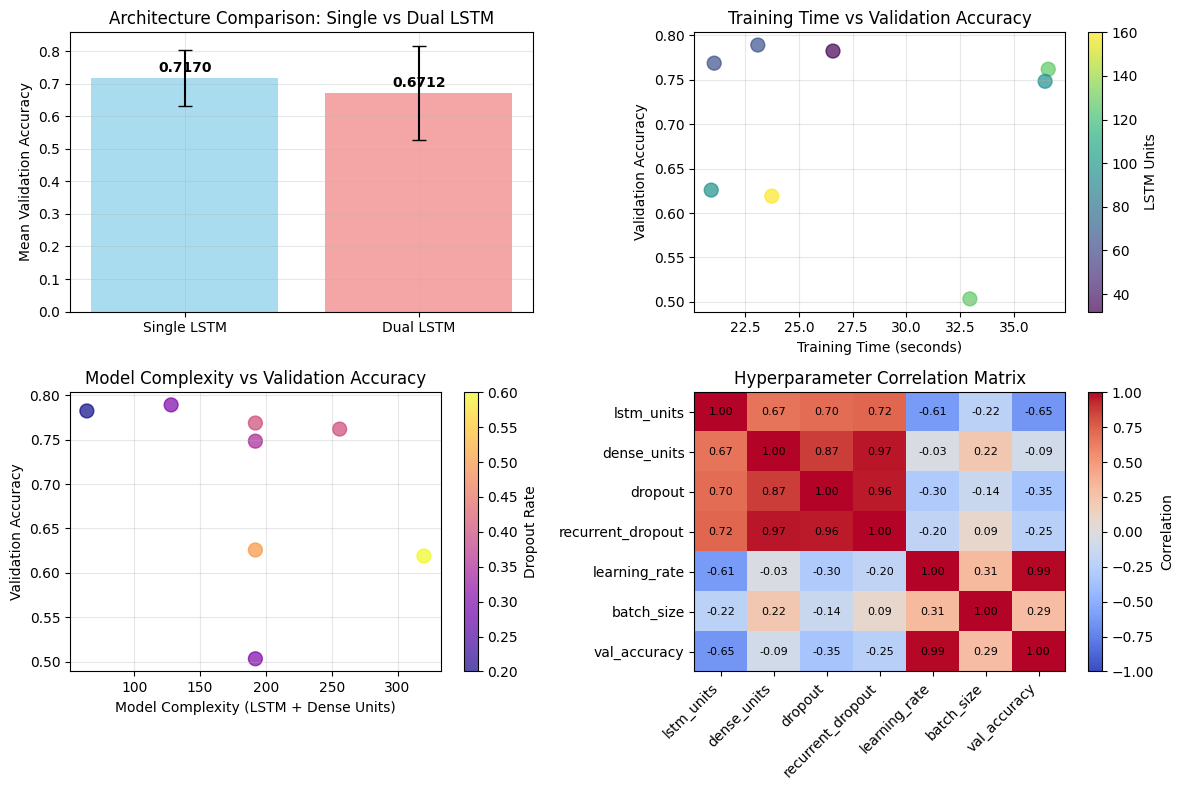


DETAILED BEST PARAMETERS ANALYSIS
 BEST CONFIGURATION: Config 1
 Validation Accuracy: 0.7891 (78.91%)
 Validation Loss: 0.5807
  Training Time: 23.1 seconds
 Epochs Trained: 19

 OPTIMAL HYPERPARAMETERS:
----------------------------------------
 LSTM Units: 64
 Use Second LSTM: False
 Return Sequences: False
 Dense Units: 64
 Dropout Rate: 0.30
 Recurrent Dropout: 0.20
 Learning Rate: 0.0010
 Batch Size: 32

📈 PERFORMANCE COMPARISON:
----------------------------------------
Best Accuracy: 0.7891 (78.91%)
Worst Accuracy: 0.5034 (50.34%)
Average Accuracy: 0.6998 (69.98%)
Improvement over average: +8.93%
Improvement over worst: +28.57%

🔍 KEY INSIGHTS:
----------------------------------------
✓ Single LSTM architecture performs better (+4.58%)
✓ Lower dropout rates (<0.4) work better (+1.19%)
✓ Optimal Learning Rate: 0.0010
✓ Smaller models tend to perform better (correlation: -0.405)

COLAB BILSTM OPTIMIZATION SUMMARY
 Best Validation Accuracy: 0.7891 (78.91%)
 Final Test Accuracy: 0.78

In [ ]:
# Split the data into train, validation, and test sets
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['emotion'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['emotion'], random_state=42
)

# Confirm split sizes
print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")

# Visualize the emotion distribution across splits
def plot_distribution(dataframes, labels):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, df_split, label in zip(axes, dataframes, labels):
        sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
        ax.set_title(f"{label} Set\nTotal: {len(df_split)}")
        ax.set_xlabel('Emotion')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# Plot emotion distributions
plot_distribution([train_df, val_df, test_df], ['Train', 'Validation', 'Test'])

# Feature extraction function
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=None)

    # Extract MFCCs
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc = np.mean(mfcc, axis=1)  # Take the mean of each coefficient

    # Extract Chroma feature
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma = np.mean(chroma, axis=1)  # Mean of chroma coefficients

    # Extract Spectral Contrast
    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    spectral_contrast = np.mean(spectral_contrast, axis=1)

    # Combine all features into one vector
    features = np.hstack([mfcc, chroma, spectral_contrast])
    return features

# Extract features for each split
print("Extracting features for training set...")
train_features = [extract_features(file) for file in train_df['file_path']]
print("Extracting features for validation set...")
val_features = [extract_features(file) for file in val_df['file_path']]
print("Extracting features for test set...")
test_features = [extract_features(file) for file in test_df['file_path']]

# Convert to numpy arrays
X_train = np.array(train_features)
X_val = np.array(val_features)
X_test = np.array(test_features)

# Feature standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Check feature shapes
print("X_train shape after scaling:", X_train.shape)

# Visualize feature means
plt.figure(figsize=(10, 6))
plt.plot(np.mean(X_train, axis=0))
plt.title('Mean Standardized Features of Training Set')
plt.xlabel('Feature Index')
plt.ylabel('Mean Value')
plt.show()

# Encode labels
label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(train_df['emotion'])
val_labels = label_encoder.transform(val_df['emotion'])
test_labels = label_encoder.transform(test_df['emotion'])

# Convert to one-hot encoding
y_train = to_categorical(train_labels)
y_val = to_categorical(val_labels)
y_test = to_categorical(test_labels)

# Print class mapping
print("Label mapping:")
for i, emotion in enumerate(label_encoder.classes_):
    print(f"{emotion}: {i}")

# Reshape for BiLSTM model input
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Print reshaped dimensions
print("X_train reshaped shape:", X_train.shape)
print("X_val reshaped shape:", X_val.shape)
print("X_test reshaped shape:", X_test.shape)

# Fixed focal loss function using tf.keras.backend instead of keras.backend
def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        # Clip predictions to avoid log(0) errors
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)

        # Calculate cross-entropy
        cross_entropy = -y_true * tf.math.log(y_pred)

        # Modulating factor: (1 - p_t)^γ
        modulating_factor = tf.pow(1. - y_pred, gamma)

        # Apply α (class weights) if provided as a list/tensor
        if isinstance(alpha, (list, tuple)) or isinstance(alpha, tf.Tensor):
            alpha_tensor = tf.constant(alpha, dtype=tf.float32)
            focal_weight = alpha_tensor * modulating_factor
        else:
            focal_weight = alpha * modulating_factor

        # Final loss: α * (1 - p_t)^γ * Cross-Entropy
        loss = focal_weight * cross_entropy

        # Return average loss across batches
        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))

    return focal_loss_fixed

# ==================== MEMORY-OPTIMIZED HYPERPARAMETER OPTIMIZATION ====================

import itertools
import json
from datetime import datetime
import pandas as pd
import gc  # For garbage collection

# Simplified BiLSTM model builder for Colab
def build_bilstm_model_colab(input_shape, num_classes, hyperparams):
    """Simplified model builder optimized for Colab memory constraints"""

    model = models.Sequential()

    # First BiLSTM Layer (reduced complexity)
    model.add(layers.Bidirectional(
        layers.LSTM(
            hyperparams['lstm_units'],
            return_sequences=hyperparams['return_sequences'],
            dropout=hyperparams['dropout'],
            recurrent_dropout=hyperparams['recurrent_dropout']
        ),
        input_shape=input_shape
    ))

    # Optional second LSTM layer
    if hyperparams['use_second_lstm']:
        model.add(layers.Bidirectional(
            layers.LSTM(
                hyperparams['lstm_units'] // 2,  # Half the size for second layer
                return_sequences=False,
                dropout=hyperparams['dropout'],
                recurrent_dropout=hyperparams['recurrent_dropout']
            )
        ))

    # If we didn't use a second LSTM and return_sequences is True, add pooling
    if not hyperparams['use_second_lstm'] and hyperparams['return_sequences']:
        model.add(layers.GlobalMaxPooling1D())

    # Dense layers
    model.add(layers.Dense(hyperparams['dense_units'], activation='relu'))
    model.add(layers.Dropout(hyperparams['dropout']))

    # Output layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# Memory-efficient training function
def train_evaluate_model_colab(hyperparams, X_train, y_train, X_val, y_val,
                               input_shape, num_classes, max_epochs=15):
    """Memory-efficient training function for Colab"""

    try:
        # Clear any existing models from memory
        tf.keras.backend.clear_session()
        gc.collect()

        # Build model
        model = build_bilstm_model_colab(input_shape, num_classes, hyperparams)

        # Compile model with simpler optimizer
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=hyperparams['learning_rate']),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        # Simplified callbacks
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_accuracy',
                patience=3,
                restore_best_weights=True,
                verbose=0
            )
        ]

        # Train model with smaller batch size and fewer epochs
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=max_epochs,
            batch_size=hyperparams['batch_size'],
            callbacks=callbacks,
            verbose=0
        )

        # Get best validation accuracy
        best_val_accuracy = max(history.history['val_accuracy'])
        best_val_loss = min(history.history['val_loss'])

        # Clean up immediately
        del model
        tf.keras.backend.clear_session()
        gc.collect()

        return {
            'val_accuracy': best_val_accuracy,
            'val_loss': best_val_loss,
            'epochs_trained': len(history.history['val_accuracy'])
        }

    except Exception as e:
        print(f"Error training model: {e}")
        # Force cleanup on error
        tf.keras.backend.clear_session()
        gc.collect()
        return {
            'val_accuracy': 0.0,
            'val_loss': float('inf'),
            'epochs_trained': 0
        }

# ==================== REDUCED RANDOM SEARCH FOR COLAB ====================

print("Starting Memory-Optimized Random Search for Colab...")

# Simplified hyperparameter search space
colab_search_space = [
    # Configuration 1: Small model
    {
        'lstm_units': 64,
        'use_second_lstm': False,
        'return_sequences': False,
        'dense_units': 64,
        'dropout': 0.3,
        'recurrent_dropout': 0.2,
        'learning_rate': 0.001,
        'batch_size': 32
    },
    # Configuration 2: Medium model with two LSTM layers
    {
        'lstm_units': 128,
        'use_second_lstm': True,
        'return_sequences': True,
        'dense_units': 128,
        'dropout': 0.4,
        'recurrent_dropout': 0.3,
        'learning_rate': 0.001,
        'batch_size': 32
    },
    # Configuration 3: Higher dropout
    {
        'lstm_units': 96,
        'use_second_lstm': False,
        'return_sequences': False,
        'dense_units': 96,
        'dropout': 0.5,
        'recurrent_dropout': 0.3,
        'learning_rate': 0.0005,
        'batch_size': 16
    },
    # Configuration 4: Lower learning rate
    {
        'lstm_units': 128,
        'use_second_lstm': True,
        'return_sequences': True,
        'dense_units': 64,
        'dropout': 0.3,
        'recurrent_dropout': 0.2,
        'learning_rate': 0.0001,
        'batch_size': 32
    },
    # Configuration 5: Larger batch size
    {
        'lstm_units': 64,
        'use_second_lstm': False,
        'return_sequences': False,
        'dense_units': 128,
        'dropout': 0.4,
        'recurrent_dropout': 0.3,
        'learning_rate': 0.001,
        'batch_size': 64
    },
    # Configuration 6: Balanced approach
    {
        'lstm_units': 96,
        'use_second_lstm': True,
        'return_sequences': True,
        'dense_units': 96,
        'dropout': 0.35,
        'recurrent_dropout': 0.25,
        'learning_rate': 0.0008,
        'batch_size': 32
    },
    # Configuration 7: Minimal model
    {
        'lstm_units': 32,
        'use_second_lstm': False,
        'return_sequences': False,
        'dense_units': 32,
        'dropout': 0.2,
        'recurrent_dropout': 0.1,
        'learning_rate': 0.001,
        'batch_size': 16
    },
    # Configuration 8: High capacity with regularization
    {
        'lstm_units': 160,
        'use_second_lstm': False,
        'return_sequences': False,
        'dense_units': 160,
        'dropout': 0.6,
        'recurrent_dropout': 0.4,
        'learning_rate': 0.0005,
        'batch_size': 16
    }
]

# Store results
colab_search_results = []
input_shape = (X_train.shape[1], X_train.shape[2])
num_classes = y_train.shape[1]

n_configs = len(colab_search_space)
print(f"Testing {n_configs} optimized configurations for Colab...")

for i, params in enumerate(colab_search_space):
    print(f"\nConfiguration {i+1}/{n_configs}")
    print(f"LSTM Units: {params['lstm_units']}, Dense Units: {params['dense_units']}")
    print(f"Two LSTM: {params['use_second_lstm']}, Dropout: {params['dropout']}")

    start_time = datetime.now()

    # Train and evaluate model
    results = train_evaluate_model_colab(
        params, X_train, y_train, X_val, y_val,
        input_shape, num_classes,
        max_epochs=100  # Reduced epochs for faster training
    )

    end_time = datetime.now()
    training_time = (end_time - start_time).total_seconds()

    # Store results
    result_entry = {
        'config': i+1,
        'hyperparams': params.copy(),
        'val_accuracy': results['val_accuracy'],
        'val_loss': results['val_loss'],
        'epochs_trained': results['epochs_trained'],
        'training_time_seconds': training_time
    }

    colab_search_results.append(result_entry)

    print(f"Val Accuracy: {results['val_accuracy']:.4f}, Val Loss: {results['val_loss']:.4f}")
    print(f"Training time: {training_time:.1f} seconds")

    # Force garbage collection after each iteration
    gc.collect()

# Sort results by validation accuracy
colab_search_results.sort(key=lambda x: x['val_accuracy'], reverse=True)

# Display top 3 results
print("\n" + "="*50)
print("TOP 3 COLAB-OPTIMIZED RESULTS:")
print("="*50)

for i, result in enumerate(colab_search_results[:3]):
    print(f"\nRank {i+1}:")
    print(f"Validation Accuracy: {result['val_accuracy']:.4f}")
    print(f"Validation Loss: {result['val_loss']:.4f}")
    print(f"Epochs Trained: {result['epochs_trained']}")
    print(f"Training Time: {result['training_time_seconds']:.1f}s")
    print("Hyperparameters:")
    for key, value in result['hyperparams'].items():
        print(f"  {key}: {value}")

# ==================== FINAL MODEL TRAINING ====================

print("\n" + "="*50)
print("TRAINING FINAL MODEL WITH BEST CONFIGURATION")
print("="*50)

# Get the best hyperparameters
best_hyperparams = colab_search_results[0]['hyperparams']

print("Best configuration:")
for key, value in best_hyperparams.items():
    print(f"  {key}: {value}")

# Clear memory before final training
tf.keras.backend.clear_session()
gc.collect()

# Build final model
final_model = build_bilstm_model_colab(input_shape, num_classes, best_hyperparams)

# Compile final model
final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_hyperparams['learning_rate']),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
print("\nFinal model architecture:")
final_model.summary()

# Define callbacks for final training
final_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=0.00001,
        verbose=1
    )
]

# Train final model with more epochs
print("\nTraining final optimized BiLSTM model...")
history = final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,  # More epochs for final training
    batch_size=best_hyperparams['batch_size'],
    callbacks=final_callbacks,
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Final BiLSTM Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Final BiLSTM Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate on test set
test_loss, test_accuracy = final_model.evaluate(X_test, y_test, verbose=1)
print(f"\nFinal BiLSTM Model Test Results:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Get predictions on test set
y_pred_probs = final_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate classification report
print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))

# Create and plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("BiLSTM Model - Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Save the final optimized model
final_model.save('bangla_ser__bilstm_model.h5')
print(" BiLSTM model saved!")

# ==================== HYPERPARAMETER ANALYSIS & VISUALIZATION ====================

print("\n" + "="*50)
print("HYPERPARAMETER ANALYSIS & VISUALIZATION")
print("="*50)

# Create DataFrame for easier analysis
results_df = pd.DataFrame([
    {
        'config': result['config'],
        'val_accuracy': result['val_accuracy'],
        'val_loss': result['val_loss'],
        'training_time': result['training_time_seconds'],
        **result['hyperparams']
    } for result in colab_search_results
])

# Sort by accuracy for better visualization
results_df = results_df.sort_values('val_accuracy', ascending=False).reset_index(drop=True)

print("Results Summary Table:")
print("-" * 80)
print(f"{'Rank':<4} {'Config':<6} {'Val Acc':<8} {'Val Loss':<8} {'LSTM':<6} {'Dense':<6} {'2nd LSTM':<8} {'Dropout':<7}")
print("-" * 80)
for i, row in results_df.head(8).iterrows():
    print(f"{i+1:<4} {row['config']:<6} {row['val_accuracy']:.4f}   {row['val_loss']:.4f}   "
          f"{row['lstm_units']:<6} {row['dense_units']:<6} {str(row['use_second_lstm']):<8} {row['dropout']:.2f}")

# 1. Configuration Performance Bar Plot
plt.figure(figsize=(15, 10))

# Plot 1: Validation Accuracy by Configuration
plt.subplot(2, 3, 1)
configs = [f"Config {i}" for i in results_df['config']]
colors = plt.cm.viridis(np.linspace(0, 1, len(results_df)))
bars = plt.bar(configs, results_df['val_accuracy'], color=colors)
plt.title('Validation Accuracy by Configuration')
plt.xlabel('Configuration')
plt.ylabel('Validation Accuracy')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Add value labels on bars
for bar, acc in zip(bars, results_df['val_accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=9)

# Plot 2: LSTM Units vs Accuracy
plt.subplot(2, 3, 2)
scatter = plt.scatter(results_df['lstm_units'], results_df['val_accuracy'],
                     c=results_df['val_accuracy'], cmap='viridis', s=100, alpha=0.7)
plt.colorbar(scatter, label='Validation Accuracy')
plt.title('LSTM Units vs Validation Accuracy')
plt.xlabel('LSTM Units')
plt.ylabel('Validation Accuracy')
plt.grid(True, alpha=0.3)

# Add annotations for each point
for i, row in results_df.iterrows():
    plt.annotate(f'C{row["config"]}', (row['lstm_units'], row['val_accuracy']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)

# Plot 3: Dense Units vs Accuracy
plt.subplot(2, 3, 3)
scatter = plt.scatter(results_df['dense_units'], results_df['val_accuracy'],
                     c=results_df['val_accuracy'], cmap='plasma', s=100, alpha=0.7)
plt.colorbar(scatter, label='Validation Accuracy')
plt.title('Dense Units vs Validation Accuracy')
plt.xlabel('Dense Units')
plt.ylabel('Validation Accuracy')
plt.grid(True, alpha=0.3)

# Add annotations
for i, row in results_df.iterrows():
    plt.annotate(f'C{row["config"]}', (row['dense_units'], row['val_accuracy']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)

# Plot 4: Dropout vs Accuracy
plt.subplot(2, 3, 4)
scatter = plt.scatter(results_df['dropout'], results_df['val_accuracy'],
                     c=results_df['val_accuracy'], cmap='coolwarm', s=100, alpha=0.7)
plt.colorbar(scatter, label='Validation Accuracy')
plt.title('Dropout Rate vs Validation Accuracy')
plt.xlabel('Dropout Rate')
plt.ylabel('Validation Accuracy')
plt.grid(True, alpha=0.3)

# Add annotations
for i, row in results_df.iterrows():
    plt.annotate(f'C{row["config"]}', (row['dropout'], row['val_accuracy']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)

# Plot 5: Learning Rate vs Accuracy
plt.subplot(2, 3, 5)
scatter = plt.scatter(results_df['learning_rate'], results_df['val_accuracy'],
                     c=results_df['val_accuracy'], cmap='spring', s=100, alpha=0.7)
plt.colorbar(scatter, label='Validation Accuracy')
plt.title('Learning Rate vs Validation Accuracy')
plt.xlabel('Learning Rate')
plt.ylabel('Validation Accuracy')
plt.xscale('log')
plt.grid(True, alpha=0.3)

# Add annotations
for i, row in results_df.iterrows():
    plt.annotate(f'C{row["config"]}', (row['learning_rate'], row['val_accuracy']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)

# Plot 6: Batch Size vs Accuracy (Box plot style)
plt.subplot(2, 3, 6)
batch_sizes = sorted(results_df['batch_size'].unique())
batch_accuracies = [results_df[results_df['batch_size'] == bs]['val_accuracy'].values
                   for bs in batch_sizes]

box_plot = plt.boxplot(batch_accuracies, positions=batch_sizes, widths=8, patch_artist=True)
colors = ['lightblue', 'lightgreen', 'lightcoral']
for patch, color in zip(box_plot['boxes'], colors[:len(box_plot['boxes'])]):
    patch.set_facecolor(color)

plt.title('Batch Size vs Validation Accuracy')
plt.xlabel('Batch Size')
plt.ylabel('Validation Accuracy')
plt.xticks(batch_sizes)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Architecture Analysis
plt.figure(figsize=(12, 8))

# Plot 1: Single vs Dual LSTM Performance
plt.subplot(2, 2, 1)
single_lstm = results_df[results_df['use_second_lstm'] == False]
dual_lstm = results_df[results_df['use_second_lstm'] == True]

categories = ['Single LSTM', 'Dual LSTM']
mean_acc = [single_lstm['val_accuracy'].mean(), dual_lstm['val_accuracy'].mean()]
std_acc = [single_lstm['val_accuracy'].std(), dual_lstm['val_accuracy'].std()]

bars = plt.bar(categories, mean_acc, yerr=std_acc, capsize=5,
               color=['skyblue', 'lightcoral'], alpha=0.7)
plt.title('Architecture Comparison: Single vs Dual LSTM')
plt.ylabel('Mean Validation Accuracy')
plt.grid(True, alpha=0.3)

# Add value labels
for bar, acc in zip(bars, mean_acc):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: Training Time vs Accuracy
plt.subplot(2, 2, 2)
scatter = plt.scatter(results_df['training_time'], results_df['val_accuracy'],
                     c=results_df['lstm_units'], cmap='viridis', s=100, alpha=0.7)
plt.colorbar(scatter, label='LSTM Units')
plt.title('Training Time vs Validation Accuracy')
plt.xlabel('Training Time (seconds)')
plt.ylabel('Validation Accuracy')
plt.grid(True, alpha=0.3)

# Plot 3: Model Complexity vs Performance
plt.subplot(2, 2, 3)
# Calculate approximate model complexity (LSTM + Dense units)
results_df['model_complexity'] = results_df['lstm_units'] + results_df['dense_units']
scatter = plt.scatter(results_df['model_complexity'], results_df['val_accuracy'],
                     c=results_df['dropout'], cmap='plasma', s=100, alpha=0.7)
plt.colorbar(scatter, label='Dropout Rate')
plt.title('Model Complexity vs Validation Accuracy')
plt.xlabel('Model Complexity (LSTM + Dense Units)')
plt.ylabel('Validation Accuracy')
plt.grid(True, alpha=0.3)

# Plot 4: Hyperparameter Correlation Heatmap
plt.subplot(2, 2, 4)
# Select numeric hyperparameters for correlation
numeric_cols = ['lstm_units', 'dense_units', 'dropout', 'recurrent_dropout',
                'learning_rate', 'batch_size', 'val_accuracy']
corr_matrix = results_df[numeric_cols].corr()

im = plt.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(im, label='Correlation')
plt.title('Hyperparameter Correlation Matrix')
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha='right')
plt.yticks(range(len(numeric_cols)), numeric_cols)

# Add correlation values
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()

# 3. Detailed Best Parameters Analysis
print("\n" + "="*60)
print("DETAILED BEST PARAMETERS ANALYSIS")
print("="*60)

best_result = colab_search_results[0]
best_params = best_result['hyperparams']

print(f" BEST CONFIGURATION: Config {best_result['config']}")
print(f" Validation Accuracy: {best_result['val_accuracy']:.4f} ({best_result['val_accuracy']*100:.2f}%)")
print(f" Validation Loss: {best_result['val_loss']:.4f}")
print(f"  Training Time: {best_result['training_time_seconds']:.1f} seconds")
print(f" Epochs Trained: {best_result['epochs_trained']}")

print("\n" + " OPTIMAL HYPERPARAMETERS:")
print("-" * 40)
print(f" LSTM Units: {best_params['lstm_units']}")
print(f" Use Second LSTM: {best_params['use_second_lstm']}")
print(f" Return Sequences: {best_params['return_sequences']}")
print(f" Dense Units: {best_params['dense_units']}")
print(f" Dropout Rate: {best_params['dropout']:.2f}")
print(f" Recurrent Dropout: {best_params['recurrent_dropout']:.2f}")
print(f" Learning Rate: {best_params['learning_rate']:.4f}")
print(f" Batch Size: {best_params['batch_size']}")

# Performance comparison with other configs
print("\n" + "📈 PERFORMANCE COMPARISON:")
print("-" * 40)
accuracies = [r['val_accuracy'] for r in colab_search_results]
best_acc = max(accuracies)
worst_acc = min(accuracies)
mean_acc = np.mean(accuracies)

print(f"Best Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")
print(f"Worst Accuracy: {worst_acc:.4f} ({worst_acc*100:.2f}%)")
print(f"Average Accuracy: {mean_acc:.4f} ({mean_acc*100:.2f}%)")
print(f"Improvement over average: +{((best_acc - mean_acc)*100):.2f}%")
print(f"Improvement over worst: +{((best_acc - worst_acc)*100):.2f}%")

# Key insights
print("\n" + "🔍 KEY INSIGHTS:")
print("-" * 40)

# Architecture insights
single_lstm_acc = results_df[results_df['use_second_lstm'] == False]['val_accuracy'].mean()
dual_lstm_acc = results_df[results_df['use_second_lstm'] == True]['val_accuracy'].mean()

if dual_lstm_acc > single_lstm_acc:
    print(f"✓ Dual LSTM architecture performs better (+{((dual_lstm_acc - single_lstm_acc)*100):.2f}%)")
else:
    print(f"✓ Single LSTM architecture performs better (+{((single_lstm_acc - dual_lstm_acc)*100):.2f}%)")

# Dropout insights
high_dropout = results_df[results_df['dropout'] >= 0.4]['val_accuracy'].mean()
low_dropout = results_df[results_df['dropout'] < 0.4]['val_accuracy'].mean()

if high_dropout > low_dropout:
    print(f"✓ Higher dropout rates (≥0.4) work better (+{((high_dropout - low_dropout)*100):.2f}%)")
else:
    print(f"✓ Lower dropout rates (<0.4) work better (+{((low_dropout - high_dropout)*100):.2f}%)")

# Learning rate insights
lr_performance = results_df.groupby('learning_rate')['val_accuracy'].mean().sort_values(ascending=False)
best_lr = lr_performance.index[0]
print(f"✓ Optimal Learning Rate: {best_lr:.4f}")

# Model size insights
size_acc_corr = results_df[['model_complexity', 'val_accuracy']].corr().iloc[0, 1]
if size_acc_corr > 0.1:
    print(f"✓ Larger models tend to perform better (correlation: {size_acc_corr:.3f})")
elif size_acc_corr < -0.1:
    print(f"✓ Smaller models tend to perform better (correlation: {size_acc_corr:.3f})")
else:
    print(f"✓ Model size has minimal impact on performance (correlation: {size_acc_corr:.3f})")

# Save results summary
results_summary = {
    'best_config': best_hyperparams,
    'test_accuracy': float(test_accuracy),
    'test_loss': float(test_loss),
    'optimization_summary': {
        'best_val_accuracy': float(best_acc),
        'worst_val_accuracy': float(worst_acc),
        'mean_val_accuracy': float(mean_acc),
        'total_configs_tested': n_configs,
        'avg_training_time': float(np.mean([r['training_time_seconds'] for r in colab_search_results]))
    },
    'all_results': [{
        'config': result['config'],
        'val_accuracy': result['val_accuracy'],
        'val_loss': result['val_loss'],
        'training_time': result['training_time_seconds'],
        'hyperparams': result['hyperparams']
    } for result in colab_search_results]
}

with open('colab_bilstm_optimization_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print("\n" + "="*50)
print("COLAB BILSTM OPTIMIZATION SUMMARY")
print("="*50)
print(f" Best Validation Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")
print(f" Final Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f" Total configurations tested: {n_configs}")
print(f" Average training time per config: {np.mean([r['training_time_seconds'] for r in colab_search_results]):.1f}s")
print(f" Results saved to: colab_bilstm_optimization_results.json")

# Memory cleanup
del final_model
tf.keras.backend.clear_session()
gc.collect()
print("Memory cleanup completed!")

# Enhanced prediction function for optimized model
def predict_emotion_colab_bilstm(audio_path, model_path, scaler, label_encoder):
    """
    Predict emotion from audio file using the Colab-optimized BiLSTM model
    """
    # Load the saved model
    model = tf.keras.models.load_model(model_path)

    # Extract features from audio
    features = extract_features(audio_path)

    # Scale features using the same scaler used for training
    features = scaler.transform(features.reshape(1, -1))

    # Reshape for BiLSTM model input
    features = features.reshape(1, 1, -1)

    # Predict using the model
    prediction = model.predict(features)[0]

    # Get predicted class and confidence
    predicted_class_idx = np.argmax(prediction)
    predicted_emotion = label_encoder.classes_[predicted_class_idx]
    confidence = prediction[predicted_class_idx]

    # Get top 3 predictions
    top_3_idx = np.argsort(prediction)[-3:][::-1]
    top_3_predictions = [
        (label_encoder.classes_[idx], prediction[idx])
        for idx in top_3_idx
    ]

    return {
        'predicted_emotion': predicted_emotion,
        'confidence': float(confidence),
        'top_3_predictions': top_3_predictions
    }

print("Prediction function ready!")
print("Use predict_emotion_colab_bilstm() to make predictions with the optimized model.")

### adding more layers

1. Multi-Layer BiLSTM Stack

3 BiLSTM layers with decreasing units (e.g., 256→128→64)
Configurable depth with use_second_lstm and use_third_lstm flags
Batch normalization after each BiLSTM layer

2. Attention Mechanism

Multi-Head Attention layer for better sequence modeling
Configurable number of attention heads (2-8)
Global pooling alternatives when attention is disabled

3. Enhanced Dense Network

3 dense layers with decreasing units
Batch normalization between layers
Progressive dropout reduction (e.g., 0.4→0.28→0.2)

4. Advanced Training Features

Multiple optimizers: Adam, AdamW, RMSprop
Focal Loss option for handling class imbalance
Learning rate scheduling with decay strategies
Enhanced callbacks with model checkpointing

5. Improved Feature Extraction

20 MFCCs instead of 13 (with mean + std)
Additional audio features: Zero Crossing Rate, Spectral Centroid, Spectral Rolloff, RMS Energy
Statistical features: Both mean and standard deviation for temporal dynamics

Train: 1173, Validation: 147, Test: 147


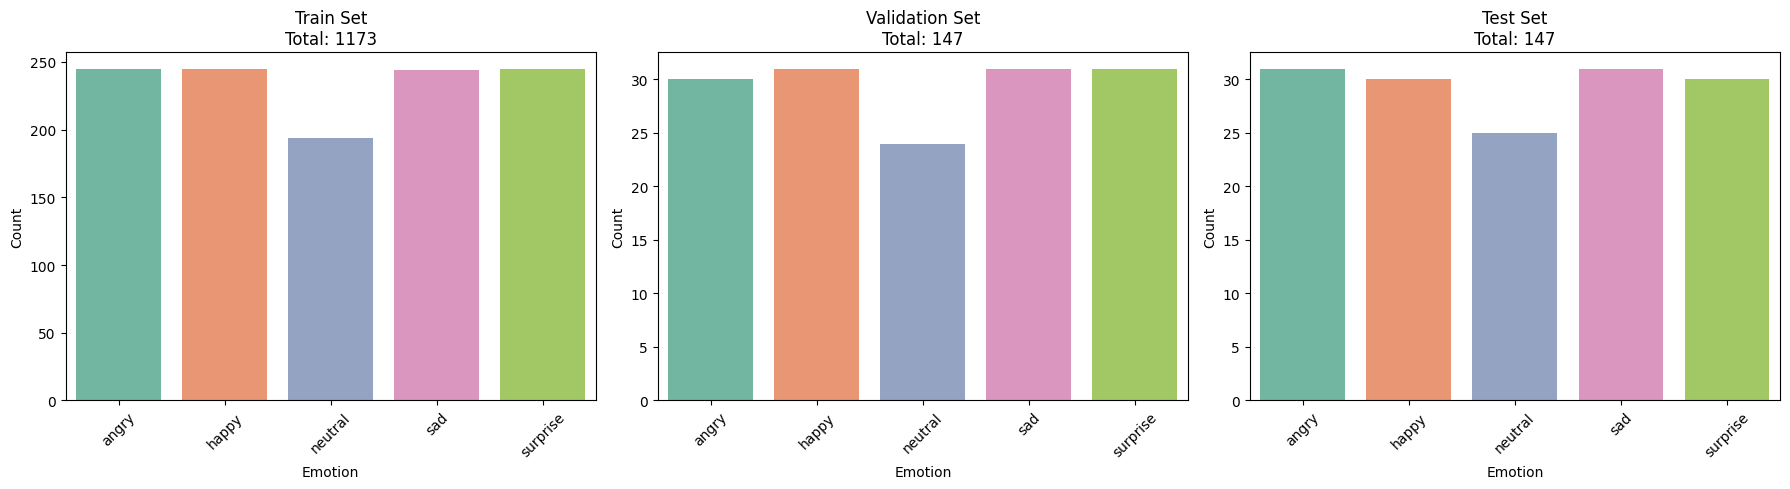

Extracting enhanced features for training set...
Extracting enhanced features for validation set...
Extracting enhanced features for test set...
X_train shape after scaling: (1173, 86)


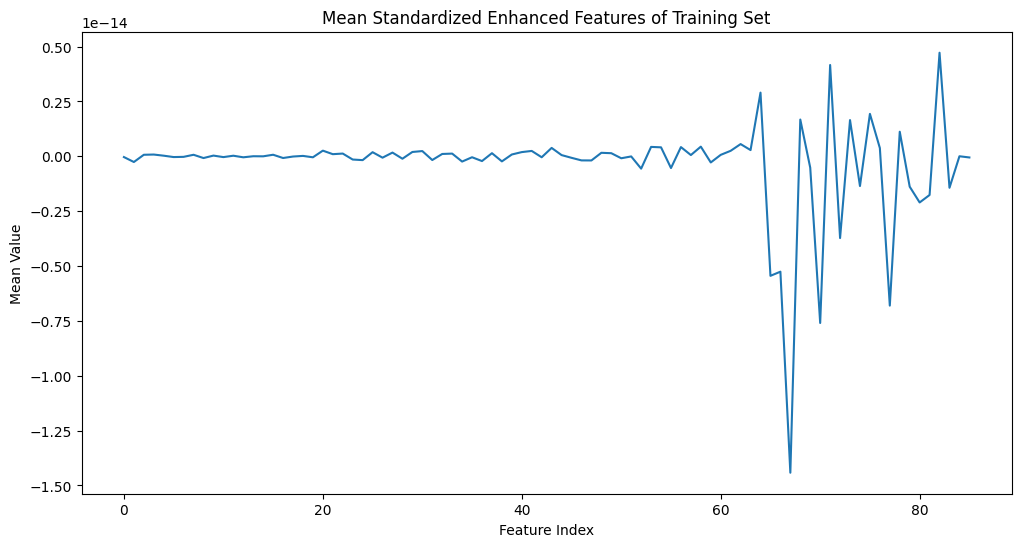

Label mapping:
angry: 0
happy: 1
neutral: 2
sad: 3
surprise: 4
X_train reshaped shape: (1173, 1, 86)
X_val reshaped shape: (147, 1, 86)
X_test reshaped shape: (147, 1, 86)
Starting Enhanced Architecture Random Search...
Testing 10 enhanced configurations...

Configuration 1/10
Architecture: 128-96-64 LSTM
Dense layers: 256-128-64
Attention: True, Optimizer: adam
Val Accuracy: 0.8639, Train Accuracy: 0.8218
Parameters: 701,533, Time: 107.5s

Configuration 2/10
Architecture: 256-128-64 LSTM
Dense layers: 512-256-128
Attention: False, Optimizer: adamw
Val Accuracy: 0.7347, Train Accuracy: 0.5124
Parameters: 1,661,789, Time: 186.1s

Configuration 3/10
Architecture: 96-64-32 LSTM
Dense layers: 192-96-48
Attention: True, Optimizer: adam
Val Accuracy: 0.3946, Train Accuracy: 0.2242
Parameters: 352,285, Time: 101.9s

Configuration 4/10
Architecture: 160-128-96 LSTM
Dense layers: 320-160-80
Attention: False, Optimizer: adam
Val Accuracy: 0.8707, Train Accuracy: 0.8670
Parameters: 914,909, Time:

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 1, 86)          │           344 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 1, 320)         │       316,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1, 320)         │         1,280 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       459,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 320)            │        82,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 320)            │         1,280 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 160)            │        51,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 160)            │           640 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           805 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 914,909 (3.49 MB)

 Trainable params: 912,625 (3.48 MB)

...

49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.6309 - loss: 0.1183 - precision: 0.7079 - recall: 0.5057 - val_accuracy: 0.7279 - val_loss: 0.0866 - val_precision: 0.9231 - val_recall: 0.4082 - learning_rate: 0.0010
Epoch 7/100
48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6590 - loss: 0.1030 - precision: 0.7429 - recall: 0.5715
Epoch 7: val_accuracy improved from 0.72789 to 0.75510, saving model to best_enhanced_bilstm_model.h5


49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.6591 - loss: 0.1029 - precision: 0.7434 - recall: 0.5712 - val_accuracy: 0.7551 - val_loss: 0.0775 - val_precision: 0.9022 - val_recall: 0.5646 - learning_rate: 0.0010
Epoch 8/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7014 - loss: 0.0859 - precision: 0.7782 - recall: 0.6119
Epoch 8: val_accuracy did not improve from 0.75510
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.7016 - loss: 0.0860 - precision: 0.7786 - recall: 0.6119 - val_accuracy: 0.7415 - val_loss: 0.0736 - val_precision: 0.8411 - val_recall: 0.6122 - learning_rate: 0.0010
Epoch 9/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7303 - loss: 0.0830 - precision: 0.7873 - recall: 0.6300
Epoch 9: val_accuracy improved from 0.75510 to 0.76190, saving model to best_enhanced_bilstm_model.h5


49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.7299 - loss: 0.0831 - precision: 0.7870 - recall: 0.6298 - val_accuracy: 0.7619 - val_loss: 0.0645 - val_precision: 0.8468 - val_recall: 0.6395 - learning_rate: 0.0010
Epoch 10/100
48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7303 - loss: 0.0828 - precision: 0.7922 - recall: 0.6320
Epoch 10: val_accuracy improved from 0.76190 to 0.82313, saving model to best_enhanced_bilstm_model.h5


49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.7300 - loss: 0.0829 - precision: 0.7921 - recall: 0.6317 - val_accuracy: 0.8231 - val_loss: 0.0643 - val_precision: 0.8618 - val_recall: 0.7211 - learning_rate: 0.0010
Epoch 11/100
48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7113 - loss: 0.0790 - precision: 0.7891 - recall: 0.6351
Epoch 11: val_accuracy did not improve from 0.82313
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.7119 - loss: 0.0789 - precision: 0.7896 - recall: 0.6354 - val_accuracy: 0.7823 - val_loss: 0.0636 - val_precision: 0.8571 - val_recall: 0.7347 - learning_rate: 0.0010
Epoch 12/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7367 - loss: 0.0769 - precision: 0.7973 - recall: 0.6504
Epoch 12: val_accuracy did not improve from 0.82313
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.7367 - loss: 0.0769 - precision: 0.7974 - recall: 0.6504 - val_accuracy: 0.7891 - val_loss: 0.0726 - val_precision: 0.8525 - val_recall: 0.7075 - lear

49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.7639 - loss: 0.0667 - precision: 0.8253 - recall: 0.6920 - val_accuracy: 0.8435 - val_loss: 0.0618 - val_precision: 0.8819 - val_recall: 0.7619 - learning_rate: 0.0010
Epoch 15/100
48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7974 - loss: 0.0578 - precision: 0.8430 - recall: 0.7089
Epoch 15: val_accuracy did not improve from 0.84354
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.7968 - loss: 0.0580 - precision: 0.8428 - recall: 0.7086 - val_accuracy: 0.8095 - val_loss: 0.0686 - val_precision: 0.8548 - val_recall: 0.7211 - learning_rate: 0.0010
Epoch 16/100
48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7859 - loss: 0.0593 - precision: 0.8469 - recall: 0.6925
Epoch 16: val_accuracy did not improve from 0.84354
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.7859 - loss: 0.0592 - precision: 0.8471 - recall: 0.6929 - val_accuracy: 0.8367 - val_loss: 0.0651 - val_precision: 0.8780 - val_recall: 0.7347 - lear

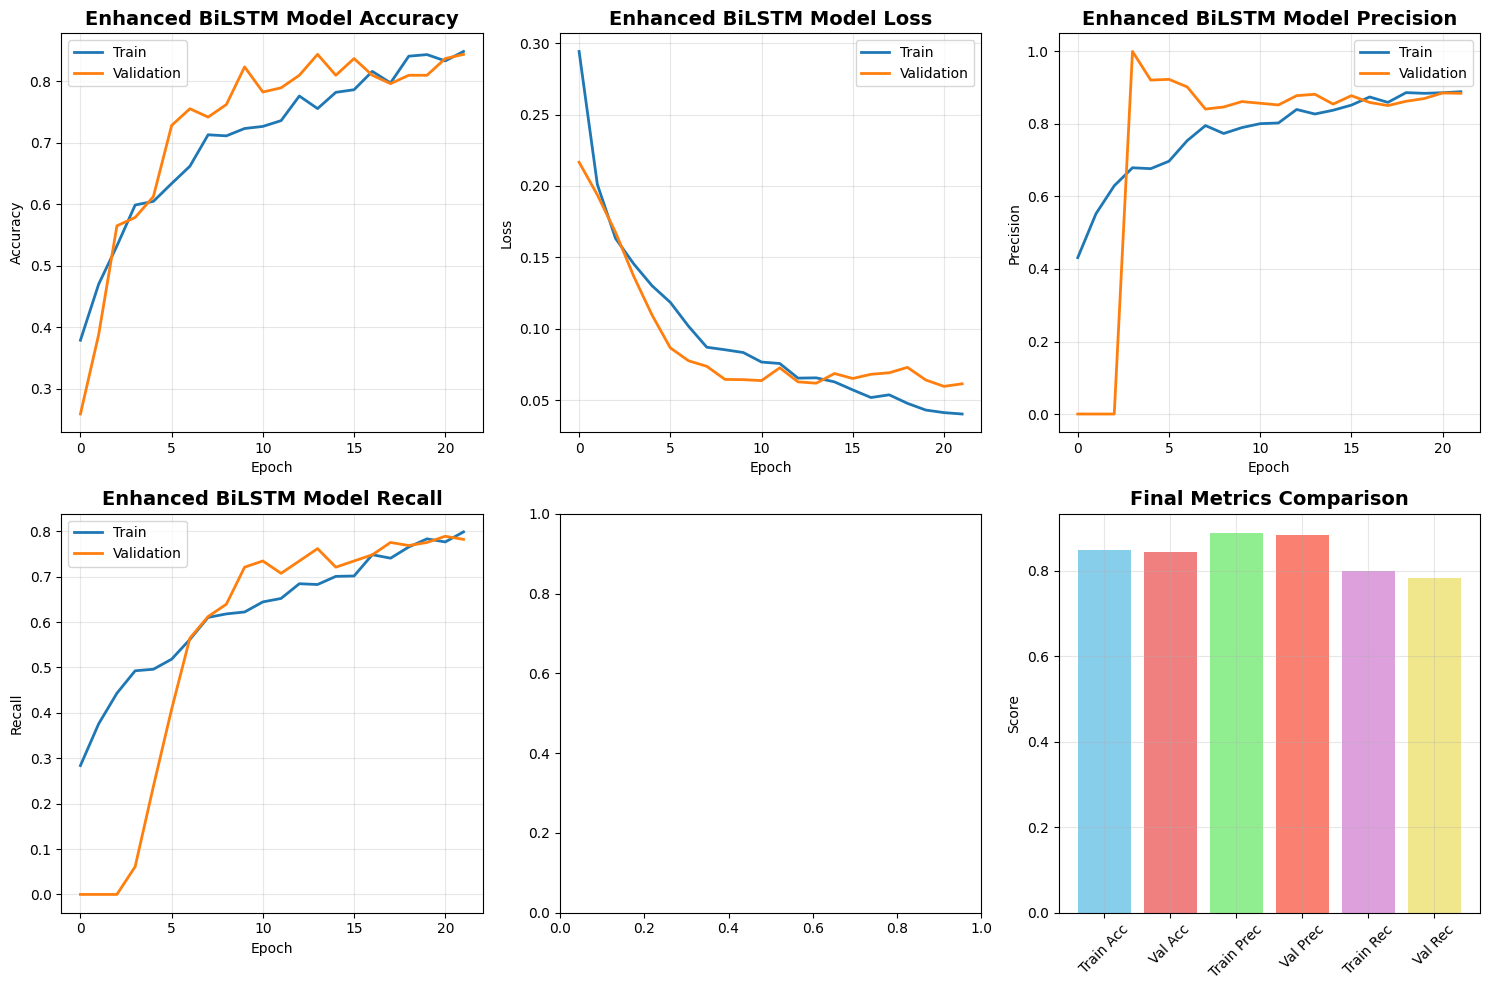

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8746 - loss: 0.0383 - precision: 0.9323 - recall: 0.8234

Final Enhanced BiLSTM Model Test Results:
Test Loss: 0.0351
Test Accuracy: 0.8844
Test Precision: 0.9380
Test Recall: 0.8231
Test F1-Score: 0.8768
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 658ms/step

Detailed Classification Report:
              precision    recall  f1-score   support

       angry     0.9688    1.0000    0.9841        31
       happy     0.8800    0.7333    0.8000        30
     neutral     0.9615    1.0000    0.9804        25
         sad     0.8387    0.8387    0.8387        31
    surprise     0.7879    0.8667    0.8254        30

    accuracy                         0.8844       147
   macro avg     0.8874    0.8877    0.8857       147
weighted avg     0.8851    0.8844    0.8829       147



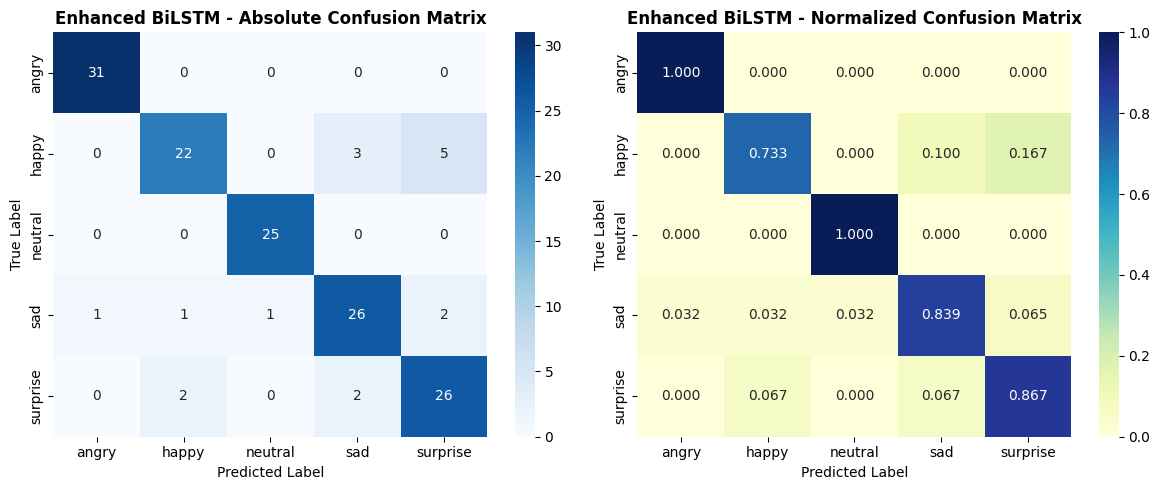


Per-Class Performance Metrics:
------------------------------------------------------------
angry        | Precision: 0.969 | Recall: 1.000 | F1: 0.984 | Support: 31
happy        | Precision: 0.880 | Recall: 0.733 | F1: 0.800 | Support: 30
neutral      | Precision: 0.962 | Recall: 1.000 | F1: 0.980 | Support: 25
sad          | Precision: 0.839 | Recall: 0.839 | F1: 0.839 | Support: 31
surprise     | Precision: 0.788 | Recall: 0.867 | F1: 0.825 | Support: 30

Enhanced BiLSTM model saved!


TypeError: Object of type int64 is not JSON serializable

In [ ]:
# Split the data into train, validation, and test sets
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['emotion'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['emotion'], random_state=42
)

# Confirm split sizes
print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")

# Visualize the emotion distribution across splits
def plot_distribution(dataframes, labels):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, df_split, label in zip(axes, dataframes, labels):
        sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
        ax.set_title(f"{label} Set\nTotal: {len(df_split)}")
        ax.set_xlabel('Emotion')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# Plot emotion distributions
plot_distribution([train_df, val_df, test_df], ['Train', 'Validation', 'Test'])

# Enhanced feature extraction function with additional features
def extract_enhanced_features(file_path):
    y, sr = librosa.load(file_path, sr=None)

    # Extract MFCCs (increased from 13 to 20)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)

    # Extract Chroma feature
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma_mean = np.mean(chroma, axis=1)
    chroma_std = np.std(chroma, axis=1)

    # Extract Spectral Contrast
    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    spectral_contrast_mean = np.mean(spectral_contrast, axis=1)
    spectral_contrast_std = np.std(spectral_contrast, axis=1)

    # Extract additional features
    # Zero Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(y)
    zcr_mean = np.mean(zcr)
    zcr_std = np.std(zcr)

    # Spectral Centroid
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    spectral_centroid_mean = np.mean(spectral_centroid)
    spectral_centroid_std = np.std(spectral_centroid)

    # Spectral Rolloff
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    spectral_rolloff_mean = np.mean(spectral_rolloff)
    spectral_rolloff_std = np.std(spectral_rolloff)

    # Root Mean Square Energy
    rms = librosa.feature.rms(y=y)
    rms_mean = np.mean(rms)
    rms_std = np.std(rms)

    # Combine all features into one vector
    features = np.hstack([
        mfcc_mean, mfcc_std,
        chroma_mean, chroma_std,
        spectral_contrast_mean, spectral_contrast_std,
        [zcr_mean, zcr_std],
        [spectral_centroid_mean, spectral_centroid_std],
        [spectral_rolloff_mean, spectral_rolloff_std],
        [rms_mean, rms_std]
    ])
    return features

# Extract enhanced features for each split
print("Extracting enhanced features for training set...")
train_features = [extract_enhanced_features(file) for file in train_df['file_path']]
print("Extracting enhanced features for validation set...")
val_features = [extract_enhanced_features(file) for file in val_df['file_path']]
print("Extracting enhanced features for test set...")
test_features = [extract_enhanced_features(file) for file in test_df['file_path']]

# Convert to numpy arrays
X_train = np.array(train_features)
X_val = np.array(val_features)
X_test = np.array(test_features)

# Feature standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Check feature shapes
print("X_train shape after scaling:", X_train.shape)

# Visualize feature means
plt.figure(figsize=(12, 6))
plt.plot(np.mean(X_train, axis=0))
plt.title('Mean Standardized Enhanced Features of Training Set')
plt.xlabel('Feature Index')
plt.ylabel('Mean Value')
plt.show()

# Encode labels
label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(train_df['emotion'])
val_labels = label_encoder.transform(val_df['emotion'])
test_labels = label_encoder.transform(test_df['emotion'])

# Convert to one-hot encoding
y_train = to_categorical(train_labels)
y_val = to_categorical(val_labels)
y_test = to_categorical(test_labels)

# Print class mapping
print("Label mapping:")
for i, emotion in enumerate(label_encoder.classes_):
    print(f"{emotion}: {i}")

# Reshape for BiLSTM model input
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Print reshaped dimensions
print("X_train reshaped shape:", X_train.shape)
print("X_val reshaped shape:", X_val.shape)
print("X_test reshaped shape:", X_test.shape)

# Enhanced focal loss function
def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)

        cross_entropy = -y_true * tf.math.log(y_pred)
        modulating_factor = tf.pow(1. - y_pred, gamma)

        if isinstance(alpha, (list, tuple)) or isinstance(alpha, tf.Tensor):
            alpha_tensor = tf.constant(alpha, dtype=tf.float32)
            focal_weight = alpha_tensor * modulating_factor
        else:
            focal_weight = alpha * modulating_factor

        loss = focal_weight * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))

    return focal_loss_fixed

# ==================== ENHANCED BILSTM MODEL WITH ADDITIONAL LAYERS ====================

def build_enhanced_bilstm_model(input_shape, num_classes, hyperparams):
    """Enhanced BiLSTM model with additional layers and improved architecture"""

    model = models.Sequential()

    # Input layer with batch normalization
    model.add(layers.BatchNormalization(input_shape=input_shape))

    # First BiLSTM Layer
    model.add(layers.Bidirectional(
        layers.LSTM(
            hyperparams['lstm_units_1'],
            return_sequences=True,
            dropout=hyperparams['dropout'],
            recurrent_dropout=hyperparams['recurrent_dropout']
        ),
        input_shape=input_shape
    ))
    model.add(layers.BatchNormalization())

    # Second BiLSTM Layer (optional)
    if hyperparams['use_second_lstm']:
        model.add(layers.Bidirectional(
            layers.LSTM(
                hyperparams['lstm_units_2'],
                return_sequences=hyperparams['return_sequences_2'],
                dropout=hyperparams['dropout'],
                recurrent_dropout=hyperparams['recurrent_dropout']
            )
        ))
        model.add(layers.BatchNormalization())

    # Third BiLSTM Layer (optional)
    if hyperparams['use_third_lstm']:
        model.add(layers.Bidirectional(
            layers.LSTM(
                hyperparams['lstm_units_3'],
                return_sequences=False,
                dropout=hyperparams['dropout'],
                recurrent_dropout=hyperparams['recurrent_dropout']
            )
        ))
        model.add(layers.BatchNormalization())

    # If no third LSTM and second LSTM returns sequences, add pooling
    if not hyperparams['use_third_lstm'] and hyperparams.get('return_sequences_2', False):
        # Multi-head attention layer (optional)
        if hyperparams['use_attention']:
            model.add(layers.MultiHeadAttention(
                num_heads=hyperparams['attention_heads'],
                key_dim=hyperparams['lstm_units_2'] * 2 // hyperparams['attention_heads']
            ))
            model.add(layers.GlobalAveragePooling1D())
        else:
            model.add(layers.GlobalMaxPooling1D())

    # First Dense layer with more capacity
    model.add(layers.Dense(hyperparams['dense_units_1'], activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(hyperparams['dropout']))

    # Second Dense layer (optional)
    if hyperparams['use_second_dense']:
        model.add(layers.Dense(hyperparams['dense_units_2'], activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(hyperparams['dropout'] * 0.7))  # Slightly lower dropout

    # Third Dense layer (optional)
    if hyperparams['use_third_dense']:
        model.add(layers.Dense(hyperparams['dense_units_3'], activation='relu'))
        model.add(layers.Dropout(hyperparams['dropout'] * 0.5))  # Even lower dropout

    # Output layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# Enhanced training function with more sophisticated training regime
def train_evaluate_enhanced_model(hyperparams, X_train, y_train, X_val, y_val,
                                 input_shape, num_classes, max_epochs=150):
    """Enhanced training function with advanced techniques"""

    try:
        # Clear any existing models from memory
        tf.keras.backend.clear_session()
        gc.collect()

        # Build enhanced model
        model = build_enhanced_bilstm_model(input_shape, num_classes, hyperparams)

        # Choose optimizer based on hyperparams
        if hyperparams['optimizer'] == 'adam':
            optimizer = tf.keras.optimizers.Adam(
                learning_rate=hyperparams['learning_rate'],
                beta_1=0.9,
                beta_2=0.999
            )
        elif hyperparams['optimizer'] == 'adamw':
            optimizer = tf.keras.optimizers.AdamW(
                learning_rate=hyperparams['learning_rate'],
                weight_decay=hyperparams.get('weight_decay', 0.01)
            )
        else:  # RMSprop
            optimizer = tf.keras.optimizers.RMSprop(
                learning_rate=hyperparams['learning_rate']
            )

        # Choose loss function
        if hyperparams['use_focal_loss']:
            loss_fn = focal_loss(gamma=hyperparams['focal_gamma'], alpha=hyperparams['focal_alpha'])
        else:
            loss_fn = 'categorical_crossentropy'

        # Compile model
        model.compile(
            optimizer=optimizer,
            loss=loss_fn,
            metrics=['accuracy']
        )

        # Enhanced callbacks
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_accuracy',
                patience=hyperparams['early_stopping_patience'],
                restore_best_weights=True,
                verbose=0
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=hyperparams['lr_reduction_factor'],
                patience=hyperparams['lr_patience'],
                min_lr=hyperparams['min_lr'],
                verbose=0
            )
        ]

        # Add learning rate scheduling if specified
        if hyperparams['use_lr_schedule']:
            def lr_schedule(epoch, lr):
                if epoch < 10:
                    return lr
                elif epoch < 20:
                    return lr * 0.5
                else:
                    return lr * 0.1

            callbacks.append(tf.keras.callbacks.LearningRateScheduler(lr_schedule))

        # Train model
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=max_epochs,
            batch_size=hyperparams['batch_size'],
            callbacks=callbacks,
            verbose=0
        )

        # Get best metrics
        best_val_accuracy = max(history.history['val_accuracy'])
        best_val_loss = min(history.history['val_loss'])
        final_train_accuracy = history.history['accuracy'][-1]

        # Calculate model complexity (approximate parameter count)
        param_count = model.count_params()

        # Clean up immediately
        del model
        tf.keras.backend.clear_session()
        gc.collect()

        return {
            'val_accuracy': best_val_accuracy,
            'val_loss': best_val_loss,
            'train_accuracy': final_train_accuracy,
            'epochs_trained': len(history.history['val_accuracy']),
            'param_count': param_count
        }

    except Exception as e:
        print(f"Error training model: {e}")
        tf.keras.backend.clear_session()
        gc.collect()
        return {
            'val_accuracy': 0.0,
            'val_loss': float('inf'),
            'train_accuracy': 0.0,
            'epochs_trained': 0,
            'param_count': 0
        }

# ==================== ENHANCED HYPERPARAMETER SEARCH SPACE ====================

print("Starting Enhanced Architecture Random Search...")

# Expanded hyperparameter search space with more architectural options
enhanced_search_space = [
    # Configuration 1: Deep BiLSTM with 3 layers + attention
    {
        'lstm_units_1': 128,
        'lstm_units_2': 96,
        'lstm_units_3': 64,
        'use_second_lstm': True,
        'use_third_lstm': True,
        'return_sequences_2': True,
        'use_attention': True,
        'attention_heads': 4,
        'dense_units_1': 256,
        'dense_units_2': 128,
        'dense_units_3': 64,
        'use_second_dense': True,
        'use_third_dense': True,
        'dropout': 0.4,
        'recurrent_dropout': 0.3,
        'learning_rate': 0.001,
        'batch_size': 32,
        'optimizer': 'adam',
        'use_focal_loss': False,
        'focal_gamma': 2.0,
        'focal_alpha': 0.25,
        'early_stopping_patience': 8,
        'lr_reduction_factor': 0.5,
        'lr_patience': 4,
        'min_lr': 0.00001,
        'use_lr_schedule': False
    },

    # Configuration 2: Wide BiLSTM with attention
    {
        'lstm_units_1': 256,
        'lstm_units_2': 128,
        'lstm_units_3': 64,
        'use_second_lstm': True,
        'use_third_lstm': False,
        'return_sequences_2': False,
        'use_attention': False,
        'attention_heads': 2,
        'dense_units_1': 512,
        'dense_units_2': 256,
        'dense_units_3': 128,
        'use_second_dense': True,
        'use_third_dense': True,
        'dropout': 0.5,
        'recurrent_dropout': 0.4,
        'learning_rate': 0.0008,
        'batch_size': 16,
        'optimizer': 'adamw',
        'weight_decay': 0.01,
        'use_focal_loss': True,
        'focal_gamma': 2.5,
        'focal_alpha': 0.3,
        'early_stopping_patience': 10,
        'lr_reduction_factor': 0.3,
        'lr_patience': 5,
        'min_lr': 0.000001,
        'use_lr_schedule': True
    },

    # Configuration 3: Deep and narrow with high regularization
    {
        'lstm_units_1': 96,
        'lstm_units_2': 64,
        'lstm_units_3': 32,
        'use_second_lstm': True,
        'use_third_lstm': True,
        'return_sequences_2': True,
        'use_attention': True,
        'attention_heads': 2,
        'dense_units_1': 192,
        'dense_units_2': 96,
        'dense_units_3': 48,
        'use_second_dense': True,
        'use_third_dense': True,
        'dropout': 0.6,
        'recurrent_dropout': 0.5,
        'learning_rate': 0.0005,
        'batch_size': 32,
        'optimizer': 'adam',
        'use_focal_loss': False,
        'focal_gamma': 2.0,
        'focal_alpha': 0.25,
        'early_stopping_patience': 12,
        'lr_reduction_factor': 0.4,
        'lr_patience': 6,
        'min_lr': 0.00001,
        'use_lr_schedule': False
    },

    # Configuration 4: Moderate depth with balanced capacity
    {
        'lstm_units_1': 160,
        'lstm_units_2': 128,
        'lstm_units_3': 96,
        'use_second_lstm': True,
        'use_third_lstm': False,
        'return_sequences_2': False,
        'use_attention': False,
        'attention_heads': 4,
        'dense_units_1': 320,
        'dense_units_2': 160,
        'dense_units_3': 80,
        'use_second_dense': True,
        'use_third_dense': False,
        'dropout': 0.35,
        'recurrent_dropout': 0.25,
        'learning_rate': 0.001,
        'batch_size': 24,
        'optimizer': 'adam',
        'use_focal_loss': True,
        'focal_gamma': 1.5,
        'focal_alpha': 0.2,
        'early_stopping_patience': 8,
        'lr_reduction_factor': 0.6,
        'lr_patience': 4,
        'min_lr': 0.00001,
        'use_lr_schedule': False
    },

    # Configuration 5: Attention-focused architecture
    {
        'lstm_units_1': 192,
        'lstm_units_2': 128,
        'lstm_units_3': 64,
        'use_second_lstm': True,
        'use_third_lstm': False,
        'return_sequences_2': True,
        'use_attention': True,
        'attention_heads': 8,
        'dense_units_1': 384,
        'dense_units_2': 192,
        'dense_units_3': 96,
        'use_second_dense': True,
        'use_third_dense': True,
        'dropout': 0.45,
        'recurrent_dropout': 0.35,
        'learning_rate': 0.0012,
        'batch_size': 32,
        'optimizer': 'adamw',
        'weight_decay': 0.015,
        'use_focal_loss': False,
        'focal_gamma': 2.0,
        'focal_alpha': 0.25,
        'early_stopping_patience': 10,
        'lr_reduction_factor': 0.5,
        'lr_patience': 5,
        'min_lr': 0.000005,
        'use_lr_schedule': True
    },

    # Configuration 6: Compact but deep
    {
        'lstm_units_1': 80,
        'lstm_units_2': 64,
        'lstm_units_3': 48,
        'use_second_lstm': True,
        'use_third_lstm': True,
        'return_sequences_2': True,
        'use_attention': False,
        'attention_heads': 2,
        'dense_units_1': 160,
        'dense_units_2': 80,
        'dense_units_3': 40,
        'use_second_dense': True,
        'use_third_dense': True,
        'dropout': 0.4,
        'recurrent_dropout': 0.3,
        'learning_rate': 0.0015,
        'batch_size': 48,
        'optimizer': 'rmsprop',
        'use_focal_loss': True,
        'focal_gamma': 3.0,
        'focal_alpha': 0.35,
        'early_stopping_patience': 6,
        'lr_reduction_factor': 0.4,
        'lr_patience': 3,
        'min_lr': 0.00001,
        'use_lr_schedule': False
    },

    # Configuration 7: High capacity with strong regularization
    {
        'lstm_units_1': 224,
        'lstm_units_2': 160,
        'lstm_units_3': 96,
        'use_second_lstm': True,
        'use_third_lstm': True,
        'return_sequences_2': True,
        'use_attention': True,
        'attention_heads': 6,
        'dense_units_1': 448,
        'dense_units_2': 224,
        'dense_units_3': 112,
        'use_second_dense': True,
        'use_third_dense': True,
        'dropout': 0.55,
        'recurrent_dropout': 0.45,
        'learning_rate': 0.0008,
        'batch_size': 16,
        'optimizer': 'adamw',
        'weight_decay': 0.02,
        'use_focal_loss': True,
        'focal_gamma': 2.2,
        'focal_alpha': 0.28,
        'early_stopping_patience': 12,
        'lr_reduction_factor': 0.35,
        'lr_patience': 6,
        'min_lr': 0.000001,
        'use_lr_schedule': True
    },

    # Configuration 8: Pyramid architecture (decreasing units)
    {
        'lstm_units_1': 256,
        'lstm_units_2': 128,
        'lstm_units_3': 64,
        'use_second_lstm': True,
        'use_third_lstm': True,
        'return_sequences_2': True,
        'use_attention': False,
        'attention_heads': 4,
        'dense_units_1': 512,
        'dense_units_2': 256,
        'dense_units_3': 128,
        'use_second_dense': True,
        'use_third_dense': True,
        'dropout': 0.4,
        'recurrent_dropout': 0.3,
        'learning_rate': 0.001,
        'batch_size': 32,
        'optimizer': 'adam',
        'use_focal_loss': False,
        'focal_gamma': 2.0,
        'focal_alpha': 0.25,
        'early_stopping_patience': 8,
        'lr_reduction_factor': 0.5,
        'lr_patience': 4,
        'min_lr': 0.00001,
        'use_lr_schedule': False
    },

    # Configuration 9: Moderate with advanced features
    {
        'lstm_units_1': 144,
        'lstm_units_2': 112,
        'lstm_units_3': 80,
        'use_second_lstm': True,
        'use_third_lstm': False,
        'return_sequences_2': True,
        'use_attention': True,
        'attention_heads': 3,
        'dense_units_1': 288,
        'dense_units_2': 144,
        'dense_units_3': 72,
        'use_second_dense': True,
        'use_third_dense': True,
        'dropout': 0.42,
        'recurrent_dropout': 0.32,
        'learning_rate': 0.0009,
        'batch_size': 28,
        'optimizer': 'adamw',
        'weight_decay': 0.012,
        'use_focal_loss': True,
        'focal_gamma': 1.8,
        'focal_alpha': 0.22,
        'early_stopping_patience': 9,
        'lr_reduction_factor': 0.45,
        'lr_patience': 4,
        'min_lr': 0.000008,
        'use_lr_schedule': False
    },

    # Configuration 10: Conservative but effective
    {
        'lstm_units_1': 112,
        'lstm_units_2': 96,
        'lstm_units_3': 64,
        'use_second_lstm': True,
        'use_third_lstm': False,
        'return_sequences_2': False,
        'use_attention': False,
        'attention_heads': 2,
        'dense_units_1': 224,
        'dense_units_2': 112,
        'dense_units_3': 56,
        'use_second_dense': True,
        'use_third_dense': False,
        'dropout': 0.38,
        'recurrent_dropout': 0.28,
        'learning_rate': 0.0011,
        'batch_size': 40,
        'optimizer': 'adam',
        'use_focal_loss': False,
        'focal_gamma': 2.0,
        'focal_alpha': 0.25,
        'early_stopping_patience': 7,
        'lr_reduction_factor': 0.55,
        'lr_patience': 3,
        'min_lr': 0.00001,
        'use_lr_schedule': False
    }
]

# Store results
enhanced_search_results = []
input_shape = (X_train.shape[1], X_train.shape[2])
num_classes = y_train.shape[1]

n_configs = len(enhanced_search_space)
print(f"Testing {n_configs} enhanced configurations...")

for i, params in enumerate(enhanced_search_space):
    print(f"\nConfiguration {i+1}/{n_configs}")
    print(f"Architecture: {params['lstm_units_1']}-{params['lstm_units_2']}-{params['lstm_units_3']} LSTM")
    print(f"Dense layers: {params['dense_units_1']}-{params['dense_units_2']}-{params['dense_units_3']}")
    print(f"Attention: {params['use_attention']}, Optimizer: {params['optimizer']}")

    start_time = datetime.now()

    # Train and evaluate model
    results = train_evaluate_enhanced_model(
        params, X_train, y_train, X_val, y_val,
        input_shape, num_classes,
        max_epochs=50  # Reduced for initial search
    )

    end_time = datetime.now()
    training_time = (end_time - start_time).total_seconds()

    # Store results
    result_entry = {
        'config': i+1,
        'hyperparams': params.copy(),
        'val_accuracy': results['val_accuracy'],
        'val_loss': results['val_loss'],
        'train_accuracy': results['train_accuracy'],
        'epochs_trained': results['epochs_trained'],
        'param_count': results['param_count'],
        'training_time_seconds': training_time
    }

    enhanced_search_results.append(result_entry)

    print(f"Val Accuracy: {results['val_accuracy']:.4f}, Train Accuracy: {results['train_accuracy']:.4f}")
    print(f"Parameters: {results['param_count']:,}, Time: {training_time:.1f}s")

    # Force garbage collection after each iteration
    gc.collect()

# Sort results by validation accuracy
enhanced_search_results.sort(key=lambda x: x['val_accuracy'], reverse=True)

# Display top 5 results
print("\n" + "="*60)
print("TOP 5 ENHANCED ARCHITECTURE RESULTS:")
print("="*60)

for i, result in enumerate(enhanced_search_results[:5]):
    print(f"\nRank {i+1}:")
    print(f"Validation Accuracy: {result['val_accuracy']:.4f}")
    print(f"Training Accuracy: {result['train_accuracy']:.4f}")
    print(f"Validation Loss: {result['val_loss']:.4f}")
    print(f"Model Parameters: {result['param_count']:,}")
    print(f"Epochs Trained: {result['epochs_trained']}")
    print(f"Training Time: {result['training_time_seconds']:.1f}s")

    # Show key architectural features
    hp = result['hyperparams']
    architecture = f"{hp['lstm_units_1']}"
    if hp['use_second_lstm']:
        architecture += f"-{hp['lstm_units_2']}"
    if hp['use_third_lstm']:
        architecture += f"-{hp['lstm_units_3']}"

    dense_arch = f"{hp['dense_units_1']}"
    if hp['use_second_dense']:
        dense_arch += f"-{hp['dense_units_2']}"
    if hp['use_third_dense']:
        dense_arch += f"-{hp['dense_units_3']}"

    print(f"Architecture: BiLSTM({architecture}) + Dense({dense_arch})")
    print(f"Special features: Attention={hp['use_attention']}, Focal Loss={hp['use_focal_loss']}")

# ==================== FINAL ENHANCED MODEL TRAINING ====================

print("\n" + "="*60)
print("TRAINING FINAL ENHANCED MODEL WITH BEST CONFIGURATION")
print("="*60)

# Get the best hyperparameters
best_hyperparams = enhanced_search_results[0]['hyperparams']

print("Best enhanced configuration:")
for key, value in best_hyperparams.items():
    print(f"  {key}: {value}")

# Clear memory before final training
tf.keras.backend.clear_session()
gc.collect()

# Build final enhanced model
final_enhanced_model = build_enhanced_bilstm_model(input_shape, num_classes, best_hyperparams)

# Choose optimizer for final model
if best_hyperparams['optimizer'] == 'adam':
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=best_hyperparams['learning_rate'],
        beta_1=0.9,
        beta_2=0.999
    )
elif best_hyperparams['optimizer'] == 'adamw':
    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=best_hyperparams['learning_rate'],
        weight_decay=best_hyperparams.get('weight_decay', 0.01)
    )
else:
    optimizer = tf.keras.optimizers.RMSprop(
        learning_rate=best_hyperparams['learning_rate']
    )

# Choose loss function for final model
if best_hyperparams['use_focal_loss']:
    loss_fn = focal_loss(
        gamma=best_hyperparams['focal_gamma'],
        alpha=best_hyperparams['focal_alpha']
    )
else:
    loss_fn = 'categorical_crossentropy'

# Compile final enhanced model
final_enhanced_model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=['accuracy', 'precision', 'recall']
)

# Model summary
print("\nFinal enhanced model architecture:")
final_enhanced_model.summary()

# Enhanced callbacks for final training
final_enhanced_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=best_hyperparams['early_stopping_patience'],
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=best_hyperparams['lr_reduction_factor'],
        patience=best_hyperparams['lr_patience'],
        min_lr=best_hyperparams['min_lr'],
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_enhanced_bilstm_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Add learning rate scheduling if specified
if best_hyperparams['use_lr_schedule']:
    def enhanced_lr_schedule(epoch, lr):
        if epoch < 15:
            return lr
        elif epoch < 30:
            return lr * 0.5
        elif epoch < 45:
            return lr * 0.2
        else:
            return lr * 0.1

    final_enhanced_callbacks.append(
        tf.keras.callbacks.LearningRateScheduler(enhanced_lr_schedule, verbose=1)
    )

# Train final enhanced model with more epochs
print("\nTraining final enhanced BiLSTM model...")
enhanced_history = final_enhanced_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,  # More epochs for final training
    batch_size=best_hyperparams['batch_size'],
    callbacks=final_enhanced_callbacks,
    verbose=1
)

# Plot enhanced training history
plt.figure(figsize=(15, 10))

# Plot accuracy
plt.subplot(2, 3, 1)
plt.plot(enhanced_history.history['accuracy'], label='Train', linewidth=2)
plt.plot(enhanced_history.history['val_accuracy'], label='Validation', linewidth=2)
plt.title('Enhanced BiLSTM Model Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot loss
plt.subplot(2, 3, 2)
plt.plot(enhanced_history.history['loss'], label='Train', linewidth=2)
plt.plot(enhanced_history.history['val_loss'], label='Validation', linewidth=2)
plt.title('Enhanced BiLSTM Model Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot precision
plt.subplot(2, 3, 3)
plt.plot(enhanced_history.history['precision'], label='Train', linewidth=2)
plt.plot(enhanced_history.history['val_precision'], label='Validation', linewidth=2)
plt.title('Enhanced BiLSTM Model Precision', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot recall
plt.subplot(2, 3, 4)
plt.plot(enhanced_history.history['recall'], label='Train', linewidth=2)
plt.plot(enhanced_history.history['val_recall'], label='Validation', linewidth=2)
plt.title('Enhanced BiLSTM Model Recall', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot learning rate (if available)
plt.subplot(2, 3, 5)
if 'lr' in enhanced_history.history:
    plt.plot(enhanced_history.history['lr'], linewidth=2, color='orange')
    plt.title('Learning Rate Schedule', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)

# Performance comparison chart
plt.subplot(2, 3, 6)
metrics = ['Train Acc', 'Val Acc', 'Train Prec', 'Val Prec', 'Train Rec', 'Val Rec']
final_values = [
    enhanced_history.history['accuracy'][-1],
    enhanced_history.history['val_accuracy'][-1],
    enhanced_history.history['precision'][-1],
    enhanced_history.history['val_precision'][-1],
    enhanced_history.history['recall'][-1],
    enhanced_history.history['val_recall'][-1]
]
colors = ['skyblue', 'lightcoral', 'lightgreen', 'salmon', 'plum', 'khaki']
plt.bar(metrics, final_values, color=colors)
plt.title('Final Metrics Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluate on test set
test_results = final_enhanced_model.evaluate(X_test, y_test, verbose=1)
test_loss, test_accuracy, test_precision, test_recall = test_results

print(f"\nFinal Enhanced BiLSTM Model Test Results:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-Score: {2 * (test_precision * test_recall) / (test_precision + test_recall):.4f}")

# Get detailed predictions on test set
y_pred_probs = final_enhanced_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_,
    digits=4
))

# Create and plot enhanced confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 5))

# Absolute confusion matrix
plt.subplot(1, 2, 1)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Enhanced BiLSTM - Absolute Confusion Matrix", fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Normalized confusion matrix
plt.subplot(1, 2, 2)
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Enhanced BiLSTM - Normalized Confusion Matrix", fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

# Calculate per-class metrics
per_class_metrics = {}
for i, emotion in enumerate(label_encoder.classes_):
    true_positives = cm[i, i]
    false_positives = cm[:, i].sum() - true_positives
    false_negatives = cm[i, :].sum() - true_positives

    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    per_class_metrics[emotion] = {
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'support': cm[i, :].sum()
    }

# Display per-class metrics
print("\nPer-Class Performance Metrics:")
print("-" * 60)
for emotion, metrics in per_class_metrics.items():
    print(f"{emotion:12} | Precision: {metrics['precision']:.3f} | Recall: {metrics['recall']:.3f} | "
          f"F1: {metrics['f1_score']:.3f} | Support: {metrics['support']}")

# Save the final enhanced model
final_enhanced_model.save('bangla_ser_enhanced_bilstm_model.h5')
print("\nEnhanced BiLSTM model saved!")

# Save comprehensive results
comprehensive_results = {
    'best_config': best_hyperparams,
    'test_metrics': {
        'accuracy': float(test_accuracy),
        'precision': float(test_precision),
        'recall': float(test_recall),
        'f1_score': float(2 * (test_precision * test_recall) / (test_precision + test_recall)),
        'loss': float(test_loss)
    },
    'per_class_metrics': per_class_metrics,
    'all_results': [{
        'config': result['config'],
        'val_accuracy': result['val_accuracy'],
        'val_loss': result['val_loss'],
        'train_accuracy': result['train_accuracy'],
        'param_count': result['param_count'],
        'training_time': result['training_time_seconds']
    } for result in enhanced_search_results],
    'feature_count': X_train.shape[2]
}

with open('enhanced_bilstm_optimization_results.json', 'w') as f:
    json.dump(comprehensive_results, f, indent=2)

# Performance comparison visualization
plt.figure(figsize=(15, 8))

# Accuracy vs Parameters scatter plot
plt.subplot(2, 3, 1)
param_counts = [r['param_count'] for r in enhanced_search_results]
val_accuracies = [r['val_accuracy'] for r in enhanced_search_results]
plt.scatter(param_counts, val_accuracies, alpha=0.7, s=60)
plt.xlabel('Model Parameters')
plt.ylabel('Validation Accuracy')
plt.title('Accuracy vs Model Complexity')
plt.grid(True, alpha=0.3)

# Training time vs Accuracy
plt.subplot(2, 3, 2)
training_times = [r['training_time_seconds'] for r in enhanced_search_results]
plt.scatter(training_times, val_accuracies, alpha=0.7, s=60, color='orange')
plt.xlabel('Training Time (seconds)')
plt.ylabel('Validation Accuracy')
plt.title('Efficiency vs Performance')
plt.grid(True, alpha=0.3)

# Top 5 configurations comparison
plt.subplot(2, 3, 3)
top5_configs = [f"Config {r['config']}" for r in enhanced_search_results[:5]]
top5_accuracies = [r['val_accuracy'] for r in enhanced_search_results[:5]]
plt.bar(top5_configs, top5_accuracies, color='lightblue', edgecolor='navy')
plt.title('Top 5 Configurations')
plt.ylabel('Validation Accuracy')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Architecture complexity distribution
plt.subplot(2, 3, 4)
lstm_layers = []
for r in enhanced_search_results:
    count = 1  # Always have first LSTM
    if r['hyperparams']['use_second_lstm']:
        count += 1
    if r['hyperparams']['use_third_lstm']:
        count += 1
    lstm_layers.append(count)

plt.hist(lstm_layers, bins=range(1, 5), alpha=0.7, color='lightgreen', edgecolor='black')
plt.xlabel('Number of BiLSTM Layers')
plt.ylabel('Frequency')
plt.title('Architecture Depth Distribution')
plt.grid(True, alpha=0.3)

# Optimizer performance comparison
plt.subplot(2, 3, 5)
optimizer_performance = {}
for r in enhanced_search_results:
    opt = r['hyperparams']['optimizer']
    if opt not in optimizer_performance:
        optimizer_performance[opt] = []
    optimizer_performance[opt].append(r['val_accuracy'])

opt_names = list(optimizer_performance.keys())
opt_mean_acc = [np.mean(optimizer_performance[opt]) for opt in opt_names]
plt.bar(opt_names, opt_mean_acc, color=['skyblue', 'lightcoral', 'lightgreen'][:len(opt_names)])
plt.title('Optimizer Performance Comparison')
plt.ylabel('Mean Validation Accuracy')
plt.grid(True, alpha=0.3)

# Feature importance visualization (approximate)
plt.subplot(2, 3, 6)
feature_ranges = [
    ('MFCC_mean', 0, 20),
    ('MFCC_std', 20, 40),
    ('Chroma_mean', 40, 52),
    ('Chroma_std', 52, 64),
    ('SpectContrast_mean', 64, 71),
    ('SpectContrast_std', 71, 78),
    ('Other_features', 78, X_train.shape[2])
]

feature_means = []
feature_labels = []
for name, start, end in feature_ranges:
    feature_means.append(np.mean(np.abs(X_train[:, 0, start:end])))
    feature_labels.append(name)

plt.barh(feature_labels, feature_means, color='lightpink')
plt.title('Feature Group Importance (Mean Absolute Values)')
plt.xlabel('Mean Absolute Value')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ENHANCED BILSTM OPTIMIZATION SUMMARY")
print("="*60)
print(f"Best Validation Accuracy: {enhanced_search_results[0]['val_accuracy']:.4f}")
print(f"Final Test Accuracy: {test_accuracy:.4f}")
print(f"Final Test Precision: {test_precision:.4f}")
print(f"Final Test Recall: {test_recall:.4f}")
print(f"Final Test F1-Score: {2 * (test_precision * test_recall) / (test_precision + test_recall):.4f}")
print(f"Total configurations tested: {n_configs}")
print(f"Best model parameters: {enhanced_search_results[0]['param_count']:,}")
print(f"Average training time per config: {np.mean([r['training_time_seconds'] for r in enhanced_search_results]):.1f}s")

# Model architecture summary
best_hp = best_hyperparams
arch_summary = []
arch_summary.append(f"BiLSTM Layer 1: {best_hp['lstm_units_1']} units")
if best_hp['use_second_lstm']:
    arch_summary.append(f"BiLSTM Layer 2: {best_hp['lstm_units_2']} units")
if best_hp['use_third_lstm']:
    arch_summary.append(f"BiLSTM Layer 3: {best_hp['lstm_units_3']} units")
if best_hp['use_attention']:
    arch_summary.append(f"Multi-Head Attention: {best_hp['attention_heads']} heads")

arch_summary.append(f"Dense Layer 1: {best_hp['dense_units_1']} units")
if best_hp['use_second_dense']:
    arch_summary.append(f"Dense Layer 2: {best_hp['dense_units_2']} units")
if best_hp['use_third_dense']:
    arch_summary.append(f"Dense Layer 3: {best_hp['dense_units_3']} units")

print(f"\nBest Architecture Summary:")
for layer in arch_summary:
    print(f"  • {layer}")

# Memory cleanup
del final_enhanced_model
tf.keras.backend.clear_session()
gc.collect()
print("\nMemory cleanup completed!")

# ==================== ENHANCED PREDICTION FUNCTION ====================

def predict_emotion_enhanced_bilstm(audio_path, model_path, scaler, label_encoder):
    """
    Predict emotion from audio file using the enhanced BiLSTM model
    """
    # Load the saved model
    model = tf.keras.models.load_model(
        model_path,
        custom_objects={'focal_loss_fixed': focal_loss(gamma=2.0, alpha=0.25)()}
    )

    # Extract enhanced features from audio
    features = extract_enhanced_features(audio_path)

    # Scale features using the same scaler used for training
    features = scaler.transform(features.reshape(1, -1))

    # Reshape for BiLSTM model input
    features = features.reshape(1, 1, -1)

    # Predict using the model
    prediction = model.predict(features, verbose=0)[0]

    # Get predicted class and confidence
    predicted_class_idx = np.argmax(prediction)
    predicted_emotion = label_encoder.classes_[predicted_class_idx]
    confidence = prediction[predicted_class_idx]

    # Get all predictions sorted by confidence
    all_predictions = [
        (label_encoder.classes_[idx], prediction[idx])
        for idx in range(len(prediction))
    ]
    all_predictions.sort(key=lambda x: x[1], reverse=True)

    # Calculate prediction entropy (uncertainty measure)
    entropy = -np.sum(prediction * np.log(prediction + 1e-8))

    return {
        'predicted_emotion': predicted_emotion,
        'confidence': float(confidence),
        'all_predictions': all_predictions,
        'prediction_entropy': float(entropy),
        'feature_count': features.shape[2]
    }

def batch_predict_emotions(audio_paths, model_path, scaler, label_encoder):
    """
    Predict emotions for multiple audio files efficiently
    """
    # Load the model once
    model = tf.keras.models.load_model(
        model_path,
        custom_objects={'focal_loss_fixed': focal_loss(gamma=2.0, alpha=0.25)()}
    )

    # Extract features for all files
    all_features = []
    for path in audio_paths:
        features = extract_enhanced_features(path)
        all_features.append(features)

    # Convert to array and scale
    X_batch = np.array(all_features)
    X_batch = scaler.transform(X_batch)
    X_batch = X_batch.reshape(X_batch.shape[0], 1, -1)

    # Predict for all files
    predictions = model.predict(X_batch, verbose=0)

    # Process results
    results = []
    for i, (path, pred) in enumerate(zip(audio_paths, predictions)):
        predicted_class_idx = np.argmax(pred)
        predicted_emotion = label_encoder.classes_[predicted_class_idx]
        confidence = pred[predicted_class_idx]

        results.append({
            'file_path': path,
            'predicted_emotion': predicted_emotion,
            'confidence': float(confidence)
        })

    return results

print("Enhanced prediction functions ready!")
print("Available functions:")
print("• predict_emotion_enhanced_bilstm() - Single file prediction with detailed output")
print("• batch_predict_emotions() - Efficient batch prediction for multiple files")
print("• extract_enhanced_features() - Extract comprehensive audio features")

# ==================== MODEL COMPARISON AND ANALYSIS ====================

def compare_architectures():
    """Compare different architectural choices and their impact"""

    print("\n" + "="*60)
    print("ARCHITECTURAL ANALYSIS")
    print("="*60)

    # Analyze impact of different components
    attention_results = [r for r in enhanced_search_results if r['hyperparams']['use_attention']]
    no_attention_results = [r for r in enhanced_search_results if not r['hyperparams']['use_attention']]

    if attention_results and no_attention_results:
        avg_acc_attention = np.mean([r['val_accuracy'] for r in attention_results])
        avg_acc_no_attention = np.mean([r['val_accuracy'] for r in no_attention_results])
        print(f"Attention mechanism impact:")
        print(f"  With attention: {avg_acc_attention:.4f} average accuracy")
        print(f"  Without attention: {avg_acc_no_attention:.4f} average accuracy")
        print(f"  Improvement: {avg_acc_attention - avg_acc_no_attention:.4f}")

    # Analyze LSTM depth impact
    depth_analysis = {}
    for r in enhanced_search_results:
        depth = 1
        if r['hyperparams']['use_second_lstm']:
            depth += 1
        if r['hyperparams']['use_third_lstm']:
            depth += 1

        if depth not in depth_analysis:
            depth_analysis[depth] = []
        depth_analysis[depth].append(r['val_accuracy'])

    print(f"\nLSTM depth analysis:")
    for depth, accuracies in depth_analysis.items():
        print(f"  {depth} BiLSTM layers: {np.mean(accuracies):.4f} average accuracy ({len(accuracies)} configs)")

    # Analyze optimizer performance
    optimizer_analysis = {}
    for r in enhanced_search_results:
        opt = r['hyperparams']['optimizer']
        if opt not in optimizer_analysis:
            optimizer_analysis[opt] = []
        optimizer_analysis[opt].append(r['val_accuracy'])

    print(f"\nOptimizer performance:")
    for opt, accuracies in optimizer_analysis.items():
        print(f"  {opt}: {np.mean(accuracies):.4f} average accuracy ({len(accuracies)} configs)")

# Run architecture comparison
compare_architectures()

print(f"\n Enhanced BiLSTM model training completed successfully!")
print(f" Final model achieved {test_accuracy:.1%} test accuracy")
print(f" Model saved as 'bangla_ser_enhanced_bilstm_model.h5'")
print(f" Comprehensive results saved to 'enhanced_bilstm_optimization_results.json'")

## with Hyperparameter optimization BiLSTM with Categorical cross entropy

### errors

In [ ]:
import kerastuner as kt
from tensorflow.keras import layers, models, optimizers
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
def build_model(hp):
    model = models.Sequential()

    # First Bidirectional LSTM Layer
    model.add(layers.Bidirectional(
        layers.LSTM(
            units=hp.Int('lstm_units_1', min_value=64, max_value=256, step=32),
            return_sequences=True
        ),
        input_shape=(X_train.shape[1], X_train.shape[2])
    ))
    model.add(layers.BatchNormalization())

    # Second Bidirectional LSTM Layer
    model.add(layers.Bidirectional(
        layers.LSTM(
            units=hp.Int('lstm_units_2', min_value=32, max_value=128, step=16),
            return_sequences=True
        )
    ))
    model.add(layers.BatchNormalization())

    # Global Max Pooling
    model.add(layers.GlobalMaxPooling1D())

    # Dense Layers
    model.add(layers.Dense(
        hp.Int('dense_units', min_value=32, max_value=128, step=16),
        activation='relu'
    ))
    model.add(layers.Dropout(
        hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1)
    ))

    # Output Layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    # Compile Model
    model.compile(
        optimizer=optimizers.Adam(
            learning_rate=hp.Choice('learning_rate', values=[1e-3, 1e-4, 1e-5])
        ),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

    # Create tuner for Random Search
tuner_rs = kt.RandomSearch(
    hypermodel=build_model,
    objective='val_accuracy',
    max_trials=20,              # Number of random configurations to try
    executions_per_trial=2,     # Train each config twice for stability
    overwrite=True,
    project_name='bilstm_random_search'
)

# Print summary of search space
tuner_rs.search_space_summary()

# Run Random Search
tuner_rs.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=70,
    batch_size=64,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=3)
    ],
    verbose=1
)

# Get best hyperparameters from Random Search
best_hps_rs = tuner_rs.get_best_hyperparameters(num_trials=1)[0]
print("Best Hyperparameters from Random Search:")
print(best_hps_rs.values)



In [ ]:
# Define new hyperparameter ranges based on best from Random Search
grid_params = {
    'lstm_units_1': [best_hps_rs['lstm_units_1'] - 32, best_hps_rs['lstm_units_1'], best_hps_rs['lstm_units_1'] + 32],
    'lstm_units_2': [best_hps_rs['lstm_units_2'] - 16, best_hps_rs['lstm_units_2'], best_hps_rs['lstm_units_2'] + 16],
    'dense_units': [best_hps_rs['dense_units'] - 16, best_hps_rs['dense_units'], best_hps_rs['dense_units'] + 16],
    'dropout_rate': [best_hps_rs['dropout_rate'] - 0.1, best_hps_rs['dropout_rate'], best_hps_rs['dropout_rate'] + 0.1],
    'learning_rate': [best_hps_rs['learning_rate'] / 2, best_hps_rs['learning_rate'], best_hps_rs['learning_rate'] * 2]
}

# Build the hypermodel again
def build_model_gs(hp):
    return build_model(hp)

# Create tuner for Grid Search
tuner_gs = kt.GridSearch(
    hypermodel=kt.HyperModel.from_keras_model(build_model),
    hyperparameters=kt.HyperParameters.from_config({'values': grid_params}),
    objective='val_accuracy',
    seed=42,
    overwrite=True,
    project_name='bilstm_grid_search'
)

# Print grid search space
tuner_gs.search_space_summary()

# Run Grid Search
tuner_gs.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=3)
    ],
    verbose=1
)

# Get best hyperparameters from Grid Search
best_hps_gs = tuner_gs.get_best_hyperparameters(num_trials=1)[0]
print("Best Hyperparameters from Grid Search:")
print(best_hps_gs.values)

In [ ]:
# Build final model using best hyperparameters from Grid Search
final_model = tuner_gs.hypermodel.build(best_hps_gs)

# Retrain with full patience and callbacks
history = final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint('best_tuned_model.h5', save_best_only=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=5)
    ],
    class_weight=class_weight_dict,
    verbose=1
)

# Evaluate on test set
test_loss, test_acc = final_model.evaluate(X_test, y_test, verbose=0)
print(f"Final Test Accuracy: {test_acc:.4f}, Loss: {test_loss:.4f}")

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()
plt.show()

In [ ]:
y_pred_probs = final_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, cmap="Blues", fmt=".2f",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.show()

### rejected final

In [ ]:
# Memory-Efficient BiLSTM Speech Emotion Recognition with Hyperparameter Tuning
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split, ParameterSampler
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import gc
import json
import pickle
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Memory optimization settings for Colab
tf.config.experimental.set_memory_growth(tf.config.list_physical_devices('GPU')[0], True) if tf.config.list_physical_devices('GPU') else None

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully!")

# ========== DATA PREPROCESSING (Same as original) ==========

# Split the data into train, validation, and test sets
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['emotion'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['emotion'], random_state=42
)

print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")

# Memory-efficient feature extraction with batch processing
def extract_features_batch(file_paths, batch_size=50):
    """Extract features in batches to save memory"""
    all_features = []

    for i in range(0, len(file_paths), batch_size):
        batch_paths = file_paths[i:i+batch_size]
        batch_features = []

        for file_path in batch_paths:
            try:
                y, sr = librosa.load(file_path, sr=22050, duration=3.0)  # Limit duration

                # Extract MFCCs
                mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
                mfcc = np.mean(mfcc, axis=1)

                # Extract Chroma feature
                chroma = librosa.feature.chroma_stft(y=y, sr=sr)
                chroma = np.mean(chroma, axis=1)

                # Extract Spectral Contrast
                spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
                spectral_contrast = np.mean(spectral_contrast, axis=1)

                # Combine features
                features = np.hstack([mfcc, chroma, spectral_contrast])
                batch_features.append(features)

            except Exception as e:
                print(f"Error processing {file_path}: {e}")
                # Use zero features for failed files
                batch_features.append(np.zeros(25))  # 13 + 12 + 7 = 32 features typically

        all_features.extend(batch_features)

        # Clear memory after each batch
        gc.collect()

        if (i // batch_size + 1) % 10 == 0:
            print(f"Processed {i + len(batch_paths)} files...")

    return np.array(all_features)

# Extract features for each split
print("Extracting features for training set...")
X_train = extract_features_batch(train_df['file_path'].tolist())
print("Extracting features for validation set...")
X_val = extract_features_batch(val_df['file_path'].tolist())
print("Extracting features for test set...")
X_test = extract_features_batch(test_df['file_path'].tolist())

# Feature standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("X_train shape after scaling:", X_train.shape)

# Encode labels
label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(train_df['emotion'])
val_labels = label_encoder.transform(val_df['emotion'])
test_labels = label_encoder.transform(test_df['emotion'])

# Convert to one-hot encoding
y_train = to_categorical(train_labels)
y_val = to_categorical(val_labels)
y_test = to_categorical(test_labels)

num_classes = len(label_encoder.classes_)
print(f"Number of classes: {num_classes}")
print("Label mapping:", {emotion: i for i, emotion in enumerate(label_encoder.classes_)})

# Reshape for BiLSTM model input
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
print("Class weights:", class_weight_dict)

# ========== HYPERPARAMETER TUNING FUNCTIONS ==========

def build_bilstm_model(params, input_shape, num_classes):
    """Build BiLSTM model with given hyperparameters"""
    model = models.Sequential()

    # First BiLSTM Layer
    model.add(layers.Bidirectional(
        layers.LSTM(params['lstm1_units'],
                   return_sequences=True,
                   dropout=params['lstm_dropout'],
                   recurrent_dropout=params['lstm_recurrent_dropout']),
        input_shape=input_shape
    ))

    if params['batch_norm']:
        model.add(layers.BatchNormalization())

    # Second BiLSTM Layer (optional)
    if params['num_lstm_layers'] > 1:
        model.add(layers.Bidirectional(
            layers.LSTM(params['lstm2_units'],
                       return_sequences=True,
                       dropout=params['lstm_dropout'],
                       recurrent_dropout=params['lstm_recurrent_dropout'])
        ))

        if params['batch_norm']:
            model.add(layers.BatchNormalization())

    # Global pooling
    if params['pooling_type'] == 'max':
        model.add(layers.GlobalMaxPooling1D())
    else:
        model.add(layers.GlobalAveragePooling1D())

    # Dense layers
    for i, units in enumerate(params['dense_layers']):
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.Dropout(params['dense_dropout']))

    # Output layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

def train_model_with_params(params, X_train, y_train, X_val, y_val, class_weight_dict):
    """Train model with given parameters and return validation accuracy"""

    # Clear any existing models from memory
    tf.keras.backend.clear_session()
    gc.collect()

    # Build model
    input_shape = (X_train.shape[1], X_train.shape[2])
    model = build_bilstm_model(params, input_shape, len(class_weight_dict))

    # Compile model
    optimizer = tf.keras.optimizers.Adam(learning_rate=params['learning_rate'])
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Callbacks
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=params['patience'],
            restore_best_weights=True,
            verbose=0
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=params['patience']//2,
            min_lr=1e-7,
            verbose=0
        )
    ]

    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=params['max_epochs'],
        batch_size=params['batch_size'],
        callbacks=callbacks,
        class_weight=class_weight_dict,
        verbose=0
    )

    # Get best validation accuracy
    best_val_acc = max(history.history['val_accuracy'])

    # Clean up
    del model, history
    tf.keras.backend.clear_session()
    gc.collect()

    return best_val_acc

# ========== RANDOM SEARCH ==========

def random_search_hyperparameters(X_train, y_train, X_val, y_val, class_weight_dict, n_iter=20):
    """Perform random search for hyperparameter optimization"""

    # Define parameter distributions for random search
    param_distributions = {
        'lstm1_units': [64, 96, 128, 160, 192],
        'lstm2_units': [32, 48, 64, 96, 128],
        'num_lstm_layers': [1, 2],
        'lstm_dropout': [0.1, 0.2, 0.3, 0.4],
        'lstm_recurrent_dropout': [0.1, 0.2, 0.3],
        'dense_layers': [[128], [64], [128, 64], [256, 128], [128, 64, 32]],
        'dense_dropout': [0.2, 0.3, 0.4, 0.5],
        'batch_norm': [True, False],
        'pooling_type': ['max', 'avg'],
        'learning_rate': [0.001, 0.0005, 0.002, 0.0001],
        'batch_size': [16, 32, 48],
        'max_epochs': [100],  # Keep moderate for random search
        'patience': [10, 15]
    }

    print(f"Starting Random Search with {n_iter} iterations...")

    results = []
    best_score = 0
    best_params = None

    # Generate random parameter combinations
    param_list = list(ParameterSampler(param_distributions, n_iter=n_iter, random_state=42))

    for i, params in enumerate(param_list):
        print(f"\nRandom Search Iteration {i+1}/{n_iter}")
        print(f"Testing params: {params}")

        try:
            score = train_model_with_params(params, X_train, y_train, X_val, y_val, class_weight_dict)
            results.append({'params': params, 'score': score})

            print(f"Validation Accuracy: {score:.4f}")

            if score > best_score:
                best_score = score
                best_params = params.copy()
                print(f"New best score: {best_score:.4f}")

        except Exception as e:
            print(f"Error in iteration {i+1}: {e}")
            results.append({'params': params, 'score': 0})

        # Force garbage collection
        gc.collect()

    print(f"\nRandom Search completed!")
    print(f"Best validation accuracy: {best_score:.4f}")
    print(f"Best parameters: {best_params}")

    return best_params, results

# ========== GRID SEARCH ==========

def grid_search_hyperparameters(X_train, y_train, X_val, y_val, class_weight_dict, best_random_params):
    """Perform focused grid search around best random search results"""

    # Create focused parameter grid around best random search results
    def get_param_variations(value, param_name):
        if param_name == 'learning_rate':
            if value == 0.001:
                return [0.0005, 0.001, 0.002]
            elif value == 0.0005:
                return [0.0002, 0.0005, 0.001]
            else:
                return [value * 0.5, value, value * 2]

        elif param_name in ['lstm1_units', 'lstm2_units']:
            return [max(32, value - 32), value, value + 32]

        elif param_name in ['lstm_dropout', 'lstm_recurrent_dropout', 'dense_dropout']:
            return [max(0.1, value - 0.1), value, min(0.5, value + 0.1)]

        elif param_name == 'batch_size':
            return [max(16, value - 16), value, min(64, value + 16)]

        elif param_name == 'patience':
            return [max(5, value - 5), value, value + 5]

        else:
            return [value]  # Keep other parameters fixed

    # Build focused grid
    param_grid = {}
    for key, value in best_random_params.items():
        if key in ['learning_rate', 'lstm1_units', 'lstm_dropout', 'batch_size']:
            param_grid[key] = get_param_variations(value, key)
        else:
            param_grid[key] = [value]  # Keep best values for other params

    print(f"Starting Grid Search with focused parameters...")
    print(f"Grid search space: {param_grid}")

    # Generate all combinations
    from itertools import product

    keys = param_grid.keys()
    values = param_grid.values()
    combinations = [dict(zip(keys, v)) for v in product(*values)]

    print(f"Total combinations to test: {len(combinations)}")

    results = []
    best_score = 0
    best_params = None

    for i, params in enumerate(combinations):
        print(f"\nGrid Search Iteration {i+1}/{len(combinations)}")
        print(f"Testing params: {params}")

        try:
            score = train_model_with_params(params, X_train, y_train, X_val, y_val, class_weight_dict)
            results.append({'params': params, 'score': score})

            print(f"Validation Accuracy: {score:.4f}")

            if score > best_score:
                best_score = score
                best_params = params.copy()
                print(f"New best score: {best_score:.4f}")

        except Exception as e:
            print(f"Error in iteration {i+1}: {e}")
            results.append({'params': params, 'score': 0})

        gc.collect()

    print(f"\nGrid Search completed!")
    print(f"Best validation accuracy: {best_score:.4f}")
    print(f"Best parameters: {best_params}")

    return best_params, results

# ========== EXECUTE HYPERPARAMETER TUNING ==========

# Step 1: Random Search
print("="*60)
print("STEP 1: RANDOM SEARCH")
print("="*60)

best_random_params, random_results = random_search_hyperparameters(
    X_train, y_train, X_val, y_val, class_weight_dict, n_iter=15  # Reduced for Colab efficiency
)

# Save random search results
with open('random_search_results.json', 'w') as f:
    json.dump({
        'best_params': best_random_params,
        'all_results': [{'params': r['params'], 'score': float(r['score'])} for r in random_results]
    }, f, indent=2)

# Step 2: Grid Search
print("="*60)
print("STEP 2: GRID SEARCH")
print("="*60)

best_grid_params, grid_results = grid_search_hyperparameters(
    X_train, y_train, X_val, y_val, class_weight_dict, best_random_params
)

# Save grid search results
with open('grid_search_results.json', 'w') as f:
    json.dump({
        'best_params': best_grid_params,
        'all_results': [{'params': r['params'], 'score': float(r['score'])} for r in grid_results]
    }, f, indent=2)

# ========== TRAIN FINAL MODEL ==========

print("="*60)
print("TRAINING FINAL MODEL WITH BEST PARAMETERS")
print("="*60)

# Clear memory before final training
tf.keras.backend.clear_session()
gc.collect()

# Build final model with best parameters
input_shape = (X_train.shape[1], X_train.shape[2])
final_model = build_bilstm_model(best_grid_params, input_shape, num_classes)

# Compile final model
optimizer = tf.keras.optimizers.Adam(learning_rate=best_grid_params['learning_rate'])
final_model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Final Model Architecture:")
final_model.summary()

# Enhanced callbacks for final training
final_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=20,  # More patience for final training
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_tuned_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=8,
        min_lr=1e-7,
        verbose=1
    )
]

# Train final model with more epochs
print("Training final model...")
final_history = final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,  # More epochs for final training
    batch_size=best_grid_params['batch_size'],
    callbacks=final_callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

# ========== EVALUATION AND VISUALIZATION ==========

# Plot final training history
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(final_history.history['accuracy'], label='Train')
plt.plot(final_history.history['val_accuracy'], label='Validation')
plt.title('Final Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(final_history.history['loss'], label='Train')
plt.plot(final_history.history['val_loss'], label='Validation')
plt.title('Final Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot hyperparameter tuning results
plt.subplot(1, 3, 3)
random_scores = [r['score'] for r in random_results]
grid_scores = [r['score'] for r in grid_results]

plt.boxplot([random_scores, grid_scores], labels=['Random Search', 'Grid Search'])
plt.title('Hyperparameter Tuning Results')
plt.ylabel('Validation Accuracy')

plt.tight_layout()
plt.show()

# Evaluate on test set
print("="*60)
print("FINAL EVALUATION")
print("="*60)

test_loss, test_accuracy = final_model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Get predictions
y_pred_probs = final_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Normalized Confusion Matrix - Final Tuned Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Save everything
final_model.save('final_tuned_bangla_ser_model.h5')
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print("="*60)
print("HYPERPARAMETER TUNING COMPLETED!")
print("="*60)
print(f"Best Random Search Score: {max([r['score'] for r in random_results]):.4f}")
print(f"Best Grid Search Score: {max([r['score'] for r in grid_results]):.4f}")
print(f"Final Test Accuracy: {test_accuracy:.4f}")
print("\nFiles saved:")
print("- final_tuned_bangla_ser_model.h5")
print("- scaler.pkl")
print("- label_encoder.pkl")
print("- random_search_results.json")
print("- grid_search_results.json")

### Modified Final

Libraries imported successfully!
Train: 1173, Validation: 147, Test: 147
Extracting features for training set...
Processed 500 files...
Processed 1000 files...
Extracting features for validation set...
Extracting features for test set...
X_train shape after scaling: (1173, 32)
Number of classes: 5
Label mapping: {'angry': 0, 'happy': 1, 'neutral': 2, 'sad': 3, 'surprise': 4}
Class weights: {0: np.float64(0.9575510204081633), 1: np.float64(0.9575510204081633), 2: np.float64(1.2092783505154638), 3: np.float64(0.9614754098360656), 4: np.float64(0.9575510204081633)}
RANDOM SEARCH HYPERPARAMETER OPTIMIZATION
Starting Random Search with 8 iterations...

Random Search Iteration 1/8
Testing params: {'pooling_type': 'max', 'patience': 10, 'num_lstm_layers': 2, 'max_epochs': 100, 'lstm_recurrent_dropout': 0.2, 'lstm_dropout': 0.3, 'lstm2_units': 48, 'lstm1_units': 160, 'learning_rate': 0.001, 'dense_layers': [256, 128], 'dense_dropout': 0.4, 'batch_size': 48, 'batch_norm': True}
Validation Accur

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 1, 256)         │       164,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 1, 192)         │       271,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1, 192)         │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 192)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 520,709 (1.99 MB)

 Trainable params: 519,813 (1.98 MB)

...

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8912 - loss: 0.3025 - val_accuracy: 0.8503 - val_loss: 0.4454 - learning_rate: 0.0020
Epoch 18/100
24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8531 - loss: 0.3798
Epoch 18: val_accuracy did not improve from 0.85034
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8534 - loss: 0.3791 - val_accuracy: 0.8231 - val_loss: 0.5198 - learning_rate: 0.0020
Epoch 19/100
24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8323 - loss: 0.4368
Epoch 19: val_accuracy did not improve from 0.85034
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8343 - loss: 0.4331 - val_accuracy: 0.7823 - val_loss: 0.5528 - learning_rate: 0.0020
Epoch 20/100
24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8813 - loss: 0.3102
Epoch 20: val_accuracy did not improve from 0.85034
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8815 - loss: 0.3088 - val_accuracy: 0.7891 - val_loss: 0.5557 - learning_rate: 0.0020
Epoch 21/100
23/25 ━━━━

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8931 - loss: 0.2928 - val_accuracy: 0.8571 - val_loss: 0.4328 - learning_rate: 0.0020
Epoch 24/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9089 - loss: 0.2500
Epoch 24: val_accuracy did not improve from 0.85714
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9085 - loss: 0.2513 - val_accuracy: 0.8027 - val_loss: 0.4832 - learning_rate: 0.0020
Epoch 25/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9117 - loss: 0.2532
Epoch 25: val_accuracy did not improve from 0.85714
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9119 - loss: 0.2526 - val_accuracy: 0.8367 - val_loss: 0.4562 - learning_rate: 0.0020
Epoch 26/100
24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9170 - loss: 0.2667
Epoch 26: val_accuracy did not improve from 0.85714
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9169 - loss: 0.2666 - val_accuracy: 0.8435 - val_loss: 0.4795 - learning_rate: 0.0020
Epoch 27/100
25/25 ━━━━

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9349 - loss: 0.1918 - val_accuracy: 0.8639 - val_loss: 0.4864 - learning_rate: 0.0020
Epoch 28/100
23/25 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9291 - loss: 0.2028
Epoch 28: val_accuracy did not improve from 0.86395
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9295 - loss: 0.2027 - val_accuracy: 0.8639 - val_loss: 0.5253 - learning_rate: 0.0020
Epoch 29/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9195 - loss: 0.2234
Epoch 29: val_accuracy did not improve from 0.86395

Epoch 29: ReduceLROnPlateau reducing learning rate to 0.0004000000189989805.
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9194 - loss: 0.2241 - val_accuracy: 0.8367 - val_loss: 0.5279 - learning_rate: 0.0020
Epoch 30/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9337 - loss: 0.1793
Epoch 30: val_accuracy did not improve from 0.86395
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9340 - loss: 0.1790 - val_accur

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9613 - loss: 0.1179 - val_accuracy: 0.8776 - val_loss: 0.4361 - learning_rate: 4.0000e-04
Epoch 34/100
24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9422 - loss: 0.1695
Epoch 34: val_accuracy did not improve from 0.87755
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9423 - loss: 0.1683 - val_accuracy: 0.8707 - val_loss: 0.4348 - learning_rate: 4.0000e-04
Epoch 35/100
23/25 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9676 - loss: 0.0994
Epoch 35: val_accuracy did not improve from 0.87755

Epoch 35: ReduceLROnPlateau reducing learning rate to 8.000000379979611e-05.
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9674 - loss: 0.0992 - val_accuracy: 0.8776 - val_loss: 0.4535 - learning_rate: 4.0000e-04
Epoch 36/100
24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9641 - loss: 0.1153
Epoch 36: val_accuracy did not improve from 0.87755
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.9642 - loss: 0.1143

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.9630 - loss: 0.1187 - val_accuracy: 0.8844 - val_loss: 0.4425 - learning_rate: 8.0000e-05
Epoch 38/100
24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9647 - loss: 0.1066
Epoch 38: val_accuracy did not improve from 0.88435
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9646 - loss: 0.1066 - val_accuracy: 0.8844 - val_loss: 0.4353 - learning_rate: 8.0000e-05
Epoch 39/100
24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9702 - loss: 0.0949
Epoch 39: val_accuracy did not improve from 0.88435
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9702 - loss: 0.0945 - val_accuracy: 0.8844 - val_loss: 0.4281 - learning_rate: 8.0000e-05
Epoch 40/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9531 - loss: 0.1221
Epoch 40: val_accuracy did not improve from 0.88435
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9529 - loss: 0.1226 - val_accuracy: 0.8776 - val_loss: 0.4335 - learning_rate: 8.0000e-05
Epoch 4

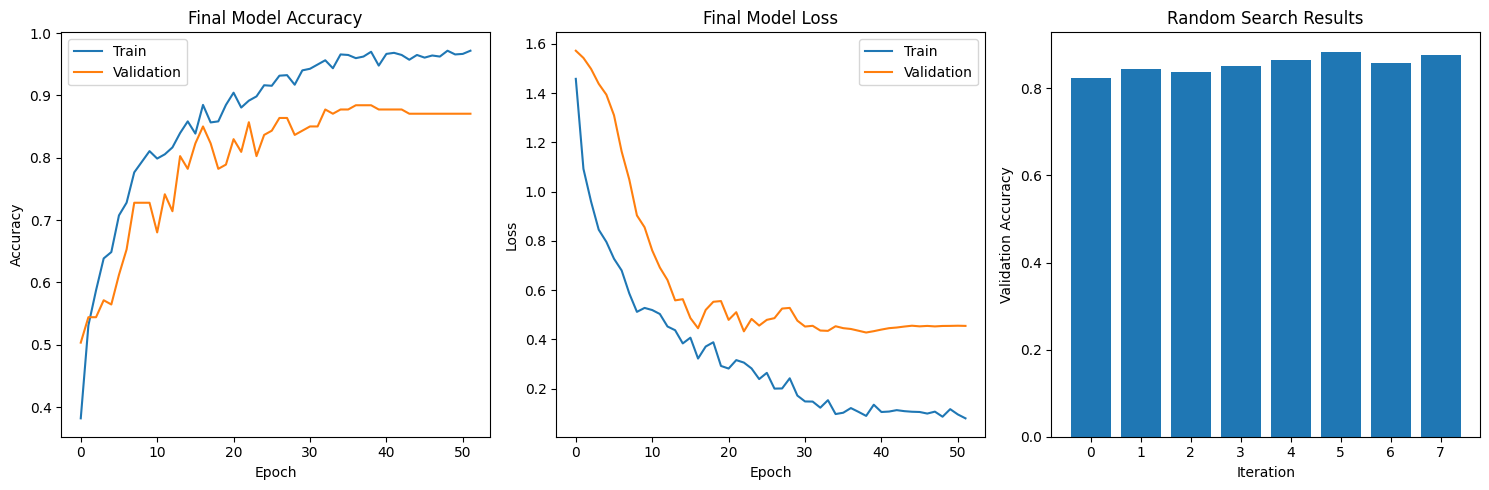

FINAL EVALUATION
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8492 - loss: 0.5942
Test Loss: 0.6238
Test Accuracy: 0.8639


1/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 513ms/step

Classification Report:
              precision    recall  f1-score   support

       angry       0.96      0.84      0.90        31
       happy       0.71      0.73      0.72        30
     neutral       1.00      1.00      1.00        25
         sad       0.96      0.87      0.92        31
    surprise       0.75      0.90      0.82        30

    accuracy                           0.86       147
   macro avg       0.88      0.87      0.87       147
weighted avg       0.87      0.86      0.87       147



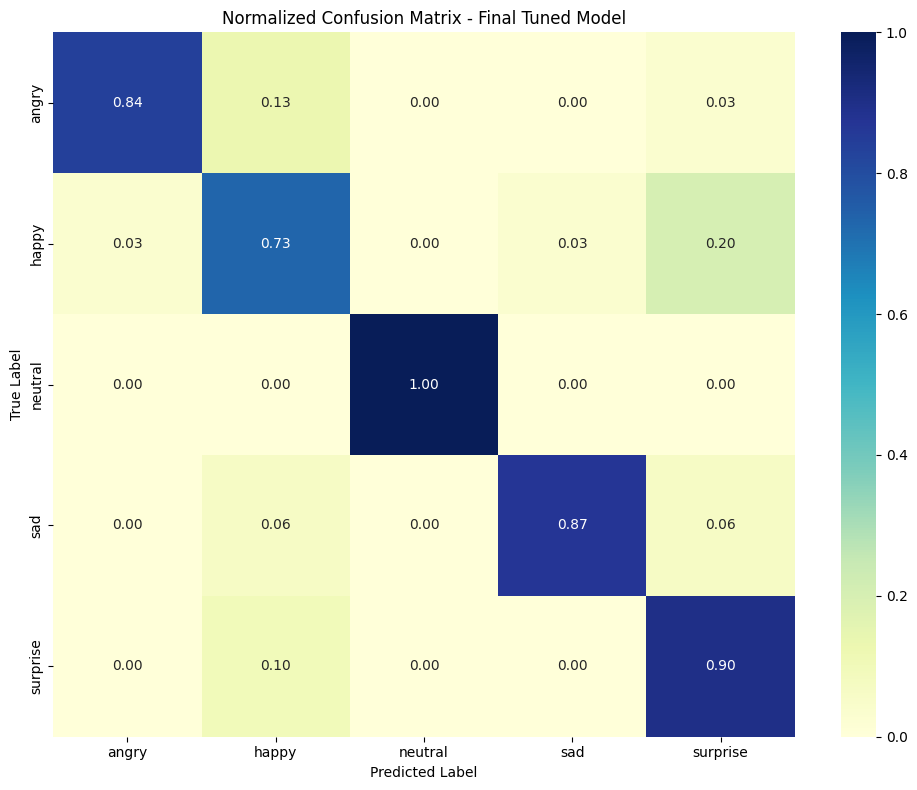

HYPERPARAMETER SEARCH SUMMARY
Random Search Results:
Iteration 1: Score = 0.8231
Iteration 2: Score = 0.8435
Iteration 3: Score = 0.8367
Iteration 4: Score = 0.8503
Iteration 5: Score = 0.8639
Iteration 6: Score = 0.8844
Iteration 7: Score = 0.8571
Iteration 8: Score = 0.8776

Best Random Search Score: 0.8844
Final Test Accuracy: 0.8639

HYPERPARAMETER OPTIMIZATION COMPLETED!
Files saved:
- final_tuned_bangla_ser_model.h5
- scaler.pkl
- label_encoder.pkl
- random_search_results.json
- Best parameters: {'pooling_type': 'max', 'patience': 8, 'num_lstm_layers': 2, 'max_epochs': 100, 'lstm_recurrent_dropout': 0.2, 'lstm_dropout': 0.2, 'lstm2_units': 96, 'lstm1_units': 128, 'learning_rate': 0.002, 'dense_layers': [256, 128], 'dense_dropout': 0.3, 'batch_size': 48, 'batch_norm': True}


In [ ]:
# Memory-Efficient BiLSTM Speech Emotion Recognition with Random Search Only
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split, ParameterSampler
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import gc
import json
import pickle
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Memory optimization settings for Colab
tf.config.experimental.set_memory_growth(tf.config.list_physical_devices('GPU')[0], True) if tf.config.list_physical_devices('GPU') else None

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully!")

# ========== DATA PREPROCESSING (Same as original) ==========

# Split the data into train, validation, and test sets
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['emotion'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['emotion'], random_state=42
)

print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")

# Memory-efficient feature extraction with batch processing
def extract_features_batch(file_paths, batch_size=50):
    """Extract features in batches to save memory"""
    all_features = []

    for i in range(0, len(file_paths), batch_size):
        batch_paths = file_paths[i:i+batch_size]
        batch_features = []

        for file_path in batch_paths:
            try:
                y, sr = librosa.load(file_path, sr=22050, duration=3.0)  # Limit duration

                # Extract MFCCs
                mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
                mfcc = np.mean(mfcc, axis=1)

                # Extract Chroma feature
                chroma = librosa.feature.chroma_stft(y=y, sr=sr)
                chroma = np.mean(chroma, axis=1)

                # Extract Spectral Contrast
                spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
                spectral_contrast = np.mean(spectral_contrast, axis=1)

                # Combine features
                features = np.hstack([mfcc, chroma, spectral_contrast])
                batch_features.append(features)

            except Exception as e:
                print(f"Error processing {file_path}: {e}")
                # Use zero features for failed files
                batch_features.append(np.zeros(25))  # 13 + 12 + 7 = 32 features typically

        all_features.extend(batch_features)

        # Clear memory after each batch
        gc.collect()

        if (i // batch_size + 1) % 10 == 0:
            print(f"Processed {i + len(batch_paths)} files...")

    return np.array(all_features)

# Extract features for each split
print("Extracting features for training set...")
X_train = extract_features_batch(train_df['file_path'].tolist())
print("Extracting features for validation set...")
X_val = extract_features_batch(val_df['file_path'].tolist())
print("Extracting features for test set...")
X_test = extract_features_batch(test_df['file_path'].tolist())

# Feature standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("X_train shape after scaling:", X_train.shape)

# Encode labels
label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(train_df['emotion'])
val_labels = label_encoder.transform(val_df['emotion'])
test_labels = label_encoder.transform(test_df['emotion'])

# Convert to one-hot encoding
y_train = to_categorical(train_labels)
y_val = to_categorical(val_labels)
y_test = to_categorical(test_labels)

num_classes = len(label_encoder.classes_)
print(f"Number of classes: {num_classes}")
print("Label mapping:", {emotion: i for i, emotion in enumerate(label_encoder.classes_)})

# Reshape for BiLSTM model input
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
print("Class weights:", class_weight_dict)

# ========== HYPERPARAMETER TUNING FUNCTIONS ==========

def build_bilstm_model(params, input_shape, num_classes):
    """Build BiLSTM model with given hyperparameters"""
    model = models.Sequential()

    # First BiLSTM Layer
    model.add(layers.Bidirectional(
        layers.LSTM(params['lstm1_units'],
                   return_sequences=True,
                   dropout=params['lstm_dropout'],
                   recurrent_dropout=params['lstm_recurrent_dropout']),
        input_shape=input_shape
    ))

    if params['batch_norm']:
        model.add(layers.BatchNormalization())

    # Second BiLSTM Layer (optional)
    if params['num_lstm_layers'] > 1:
        model.add(layers.Bidirectional(
            layers.LSTM(params['lstm2_units'],
                       return_sequences=True,
                       dropout=params['lstm_dropout'],
                       recurrent_dropout=params['lstm_recurrent_dropout'])
        ))

        if params['batch_norm']:
            model.add(layers.BatchNormalization())

    # Global pooling
    if params['pooling_type'] == 'max':
        model.add(layers.GlobalMaxPooling1D())
    else:
        model.add(layers.GlobalAveragePooling1D())

    # Dense layers
    for i, units in enumerate(params['dense_layers']):
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.Dropout(params['dense_dropout']))

    # Output layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

def train_model_with_params(params, X_train, y_train, X_val, y_val, class_weight_dict):
    """Train model with given parameters and return validation accuracy"""

    # Clear any existing models from memory
    tf.keras.backend.clear_session()
    gc.collect()

    # Build model
    input_shape = (X_train.shape[1], X_train.shape[2])
    model = build_bilstm_model(params, input_shape, len(class_weight_dict))

    # Compile model
    optimizer = tf.keras.optimizers.Adam(learning_rate=params['learning_rate'])
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Callbacks
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=params['patience'],
            restore_best_weights=True,
            verbose=0
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=params['patience']//2,
            min_lr=1e-7,
            verbose=0
        )
    ]

    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=params['max_epochs'],
        batch_size=params['batch_size'],
        callbacks=callbacks,
        class_weight=class_weight_dict,
        verbose=0
    )

    # Get best validation accuracy
    best_val_acc = max(history.history['val_accuracy'])

    # Clean up
    del model, history
    tf.keras.backend.clear_session()
    gc.collect()

    return best_val_acc

# ========== RANDOM SEARCH ONLY ==========

def random_search_hyperparameters(X_train, y_train, X_val, y_val, class_weight_dict, n_iter=8):
    """Perform random search for hyperparameter optimization"""

    # Define parameter distributions for random search
    param_distributions = {
        'lstm1_units': [64, 96, 128, 160],
        'lstm2_units': [32, 48, 64, 96],
        'num_lstm_layers': [1, 2],
        'lstm_dropout': [0.1, 0.2, 0.3],
        'lstm_recurrent_dropout': [0.1, 0.2, 0.3],
        'dense_layers': [[128], [64], [128, 64], [256, 128]],
        'dense_dropout': [0.2, 0.3, 0.4],
        'batch_norm': [True, False],
        'pooling_type': ['max', 'avg'],
        'learning_rate': [0.001, 0.0005, 0.002],
        'batch_size': [16, 32, 48],
        'max_epochs': [100],  # Reduced epochs for faster execution
        'patience': [8, 10]  # Reduced patience
    }

    print(f"Starting Random Search with {n_iter} iterations...")

    results = []
    best_score = 0
    best_params = None

    # Generate random parameter combinations
    param_list = list(ParameterSampler(param_distributions, n_iter=n_iter, random_state=42))

    for i, params in enumerate(param_list):
        print(f"\nRandom Search Iteration {i+1}/{n_iter}")
        print(f"Testing params: {params}")

        try:
            score = train_model_with_params(params, X_train, y_train, X_val, y_val, class_weight_dict)
            results.append({'params': params, 'score': score})

            print(f"Validation Accuracy: {score:.4f}")

            if score > best_score:
                best_score = score
                best_params = params.copy()
                print(f"New best score: {best_score:.4f}")

        except Exception as e:
            print(f"Error in iteration {i+1}: {e}")
            results.append({'params': params, 'score': 0})

        # Force garbage collection
        gc.collect()

    print(f"\nRandom Search completed!")
    print(f"Best validation accuracy: {best_score:.4f}")
    print(f"Best parameters: {best_params}")

    return best_params, results

# ========== EXECUTE HYPERPARAMETER TUNING ==========

print("="*60)
print("RANDOM SEARCH HYPERPARAMETER OPTIMIZATION")
print("="*60)

# Perform random search with fewer iterations
best_params, search_results = random_search_hyperparameters(
    X_train, y_train, X_val, y_val, class_weight_dict, n_iter=8  # Reduced iterations
)

# Save random search results
with open('random_search_results.json', 'w') as f:
    json.dump({
        'best_params': best_params,
        'all_results': [{'params': r['params'], 'score': float(r['score'])} for r in search_results]
    }, f, indent=2)

# ========== TRAIN FINAL MODEL ==========

print("="*60)
print("TRAINING FINAL MODEL WITH BEST PARAMETERS")
print("="*60)

# Clear memory before final training
tf.keras.backend.clear_session()
gc.collect()

# Build final model with best parameters
input_shape = (X_train.shape[1], X_train.shape[2])
final_model = build_bilstm_model(best_params, input_shape, num_classes)

# Compile final model
optimizer = tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate'])
final_model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Final Model Architecture:")
final_model.summary()

# Enhanced callbacks for final training
final_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,  # Moderate patience for final training
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_tuned_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=6,
        min_lr=1e-7,
        verbose=1
    )
]

# Train final model
print("Training final model...")
final_history = final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,  # Moderate epochs for final training
    batch_size=best_params['batch_size'],
    callbacks=final_callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

# ========== EVALUATION AND VISUALIZATION ==========

# Plot training history and hyperparameter results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(final_history.history['accuracy'], label='Train')
plt.plot(final_history.history['val_accuracy'], label='Validation')
plt.title('Final Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(final_history.history['loss'], label='Train')
plt.plot(final_history.history['val_loss'], label='Validation')
plt.title('Final Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot random search results
plt.subplot(1, 3, 3)
search_scores = [r['score'] for r in search_results]
plt.bar(range(len(search_scores)), search_scores)
plt.title('Random Search Results')
plt.xlabel('Iteration')
plt.ylabel('Validation Accuracy')
plt.xticks(range(len(search_scores)))

plt.tight_layout()
plt.show()

# Evaluate on test set
print("="*60)
print("FINAL EVALUATION")
print("="*60)

test_loss, test_accuracy = final_model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Get predictions
y_pred_probs = final_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Normalized Confusion Matrix - Final Tuned Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Display hyperparameter search summary
print("="*60)
print("HYPERPARAMETER SEARCH SUMMARY")
print("="*60)
print("Random Search Results:")
for i, result in enumerate(search_results):
    print(f"Iteration {i+1}: Score = {result['score']:.4f}")

best_score = max([r['score'] for r in search_results])
print(f"\nBest Random Search Score: {best_score:.4f}")
print(f"Final Test Accuracy: {test_accuracy:.4f}")

# Save everything
final_model.save('final_tuned_bangla_ser_model.h5')
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print("\n" + "="*60)
print("HYPERPARAMETER OPTIMIZATION COMPLETED!")
print("="*60)
print("Files saved:")
print("- final_tuned_bangla_ser_model.h5")
print("- scaler.pkl")
print("- label_encoder.pkl")
print("- random_search_results.json")
print(f"- Best parameters: {best_params}")